In [1]:
import numpy as np

# Spettri
s = np.load('../data/10k/X_spectra_10k.npy')#, mmap_mode='r')
# Corrispondenti campi magnetici
B = np.load('../data/10k/Y_B_field_10k.npy')
# Asse x (frequenze)
f = np.arange(2500, 3250) 
x_axis = range(2500, 3250)

N_spettri, N_punti = s.shape[0], s.shape[1]

In [2]:
k_list = [0, 500, 1_500, 2_500, 3_500, 5_000, 7_000, 9_000, -1]

In [3]:
# normalizzo singolarmente ogni spettro al suo massimo, utile per impostare 
# threshold per i picchi con soglie fisse
for i in range(N_spettri):
    amp = np.max(np.abs(s[i]))
    s[i] = s[i] / amp

In [4]:
# ordino gli spettri in base al campo magnetico in ordine crescente
s = s[np.argsort(B)]
B = np.sort(B)

In [5]:
from scipy.signal import find_peaks

def trova_dip_scipy(frequenze, spettro, soglia=-0.05):
    """
    Trova i dip (minimi) in uno spettro usando scipy.
    frequenze: asse x (es. array da 750 elementi)
    spettro: asse y (es. array da 750 elementi)
    soglia: valore sotto il quale considerare valido il dip
    """
    # find_peaks cerca i massimi, quindi invertiamo lo spettro
    # La soglia diventa positiva per la ricerca dei massimi
    indici_picchi, info = find_peaks(
        -spettro, 
        height=-soglia,
        #prominence=0.000001,  # Prominenza minima del picco
        width=1 # Utile perché è la stima del gamma della lorentziana
    )
    
    # Estraiamo le posizioni in frequenza
    posizioni = frequenze[indici_picchi]
    
    return posizioni, info

In [6]:
# Liste per salvare i risultati di tutti gli spettri
num_picchi_totale = np.zeros(N_spettri, dtype=int)
posizioni_totali = []
info_totale = [] 

for i in range(N_spettri):
    spettro_corrente = s[i]
    pos, info = trova_dip_scipy(f, spettro_corrente, soglia=-0.05)
    
    num_picchi_totale[i] = len(pos)
    posizioni_totali.append(pos)
    info_totale.append(info)

In [7]:
for idx, n in enumerate(num_picchi_totale):
    #if n % 2 != 0:
    if n>8:
        print(idx, n)

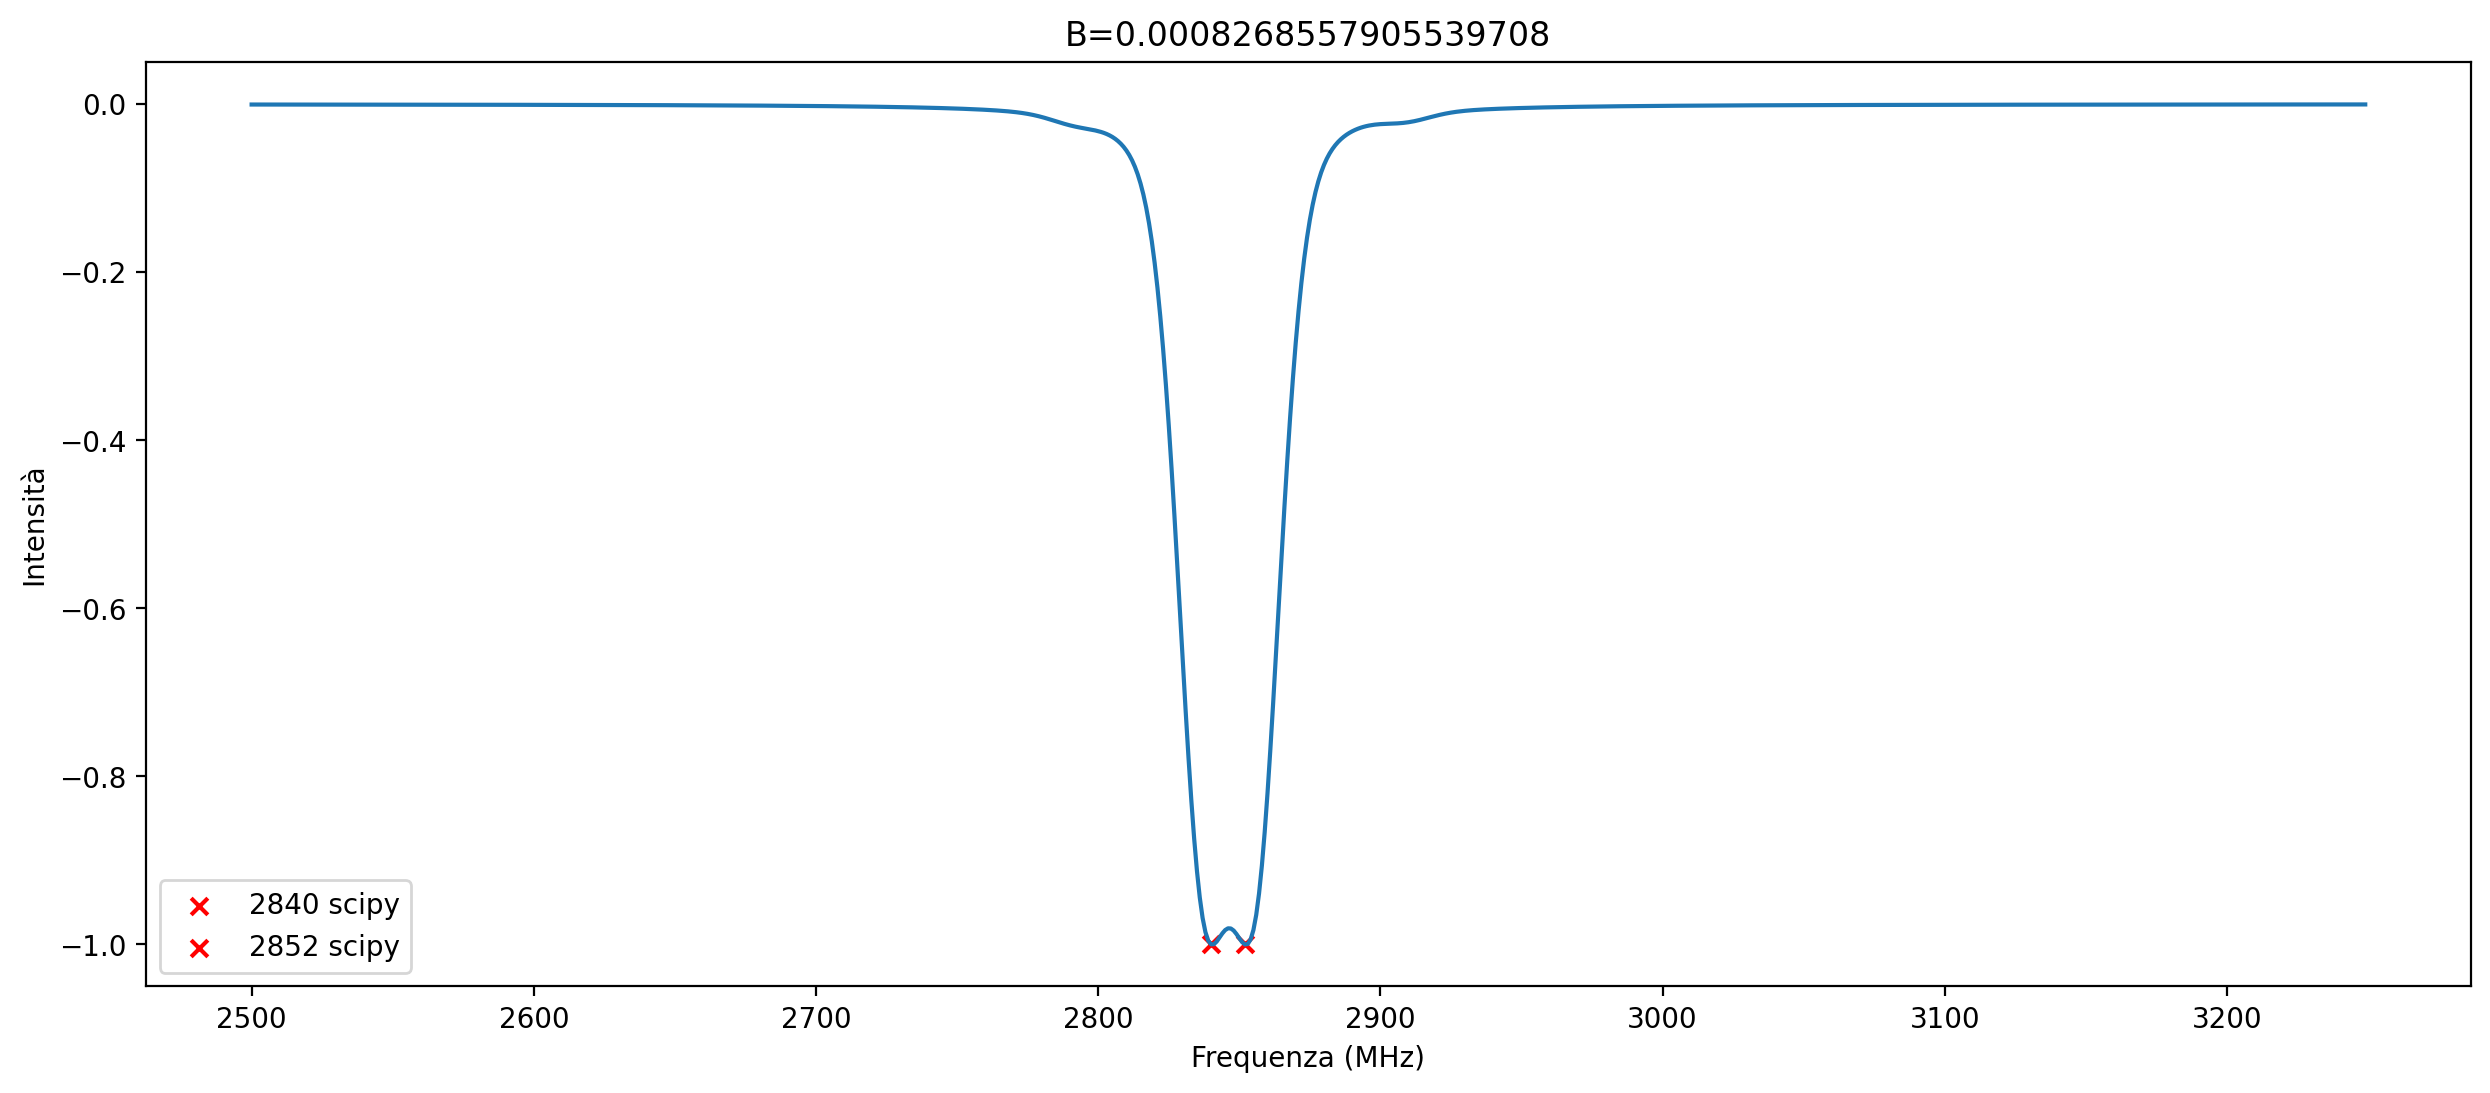

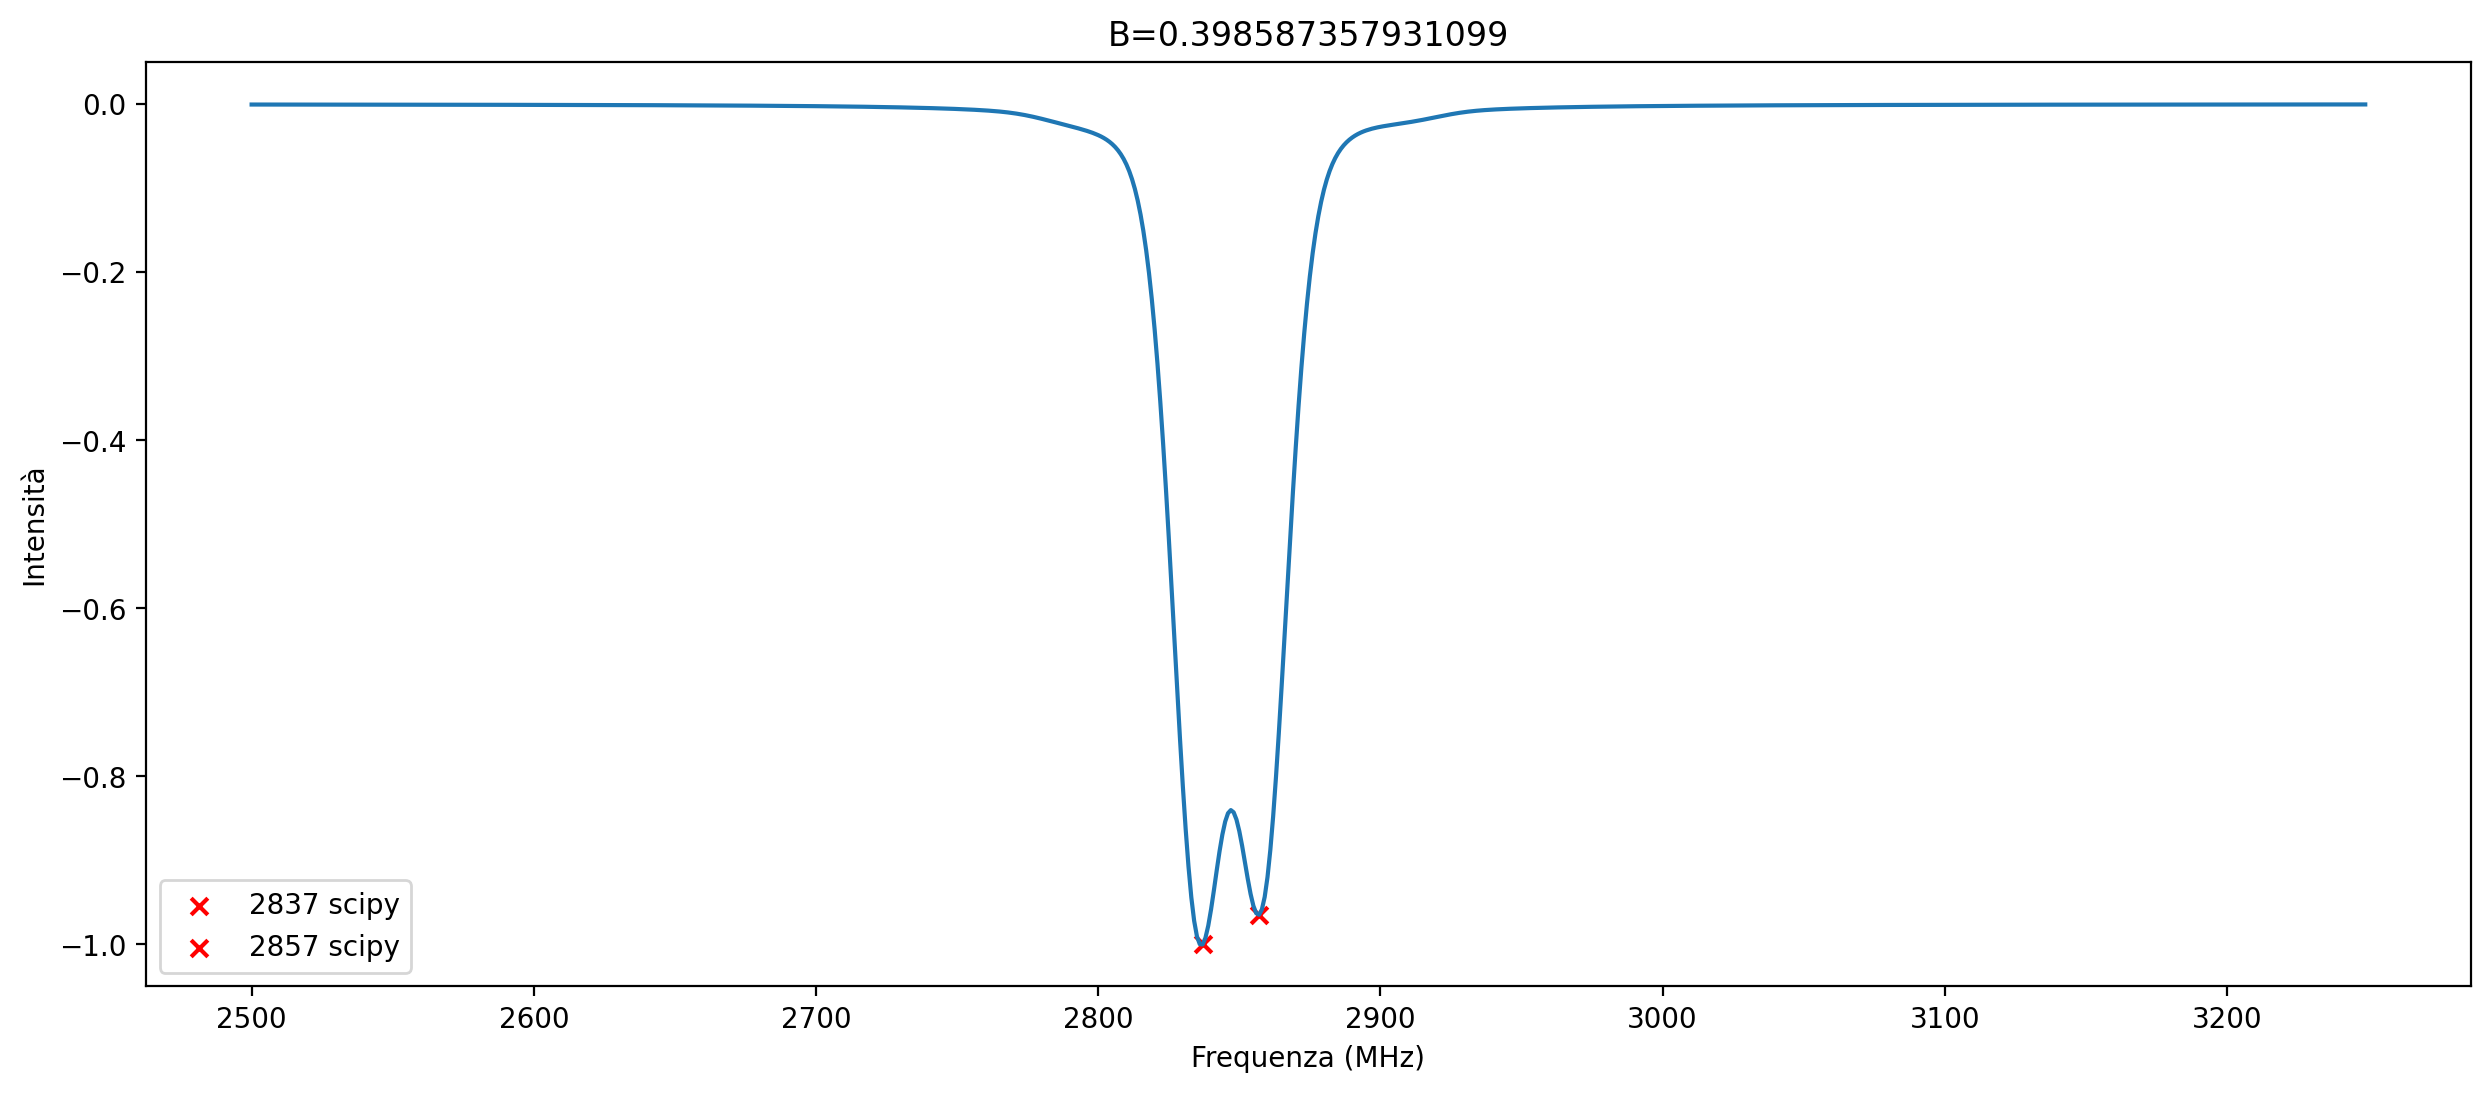

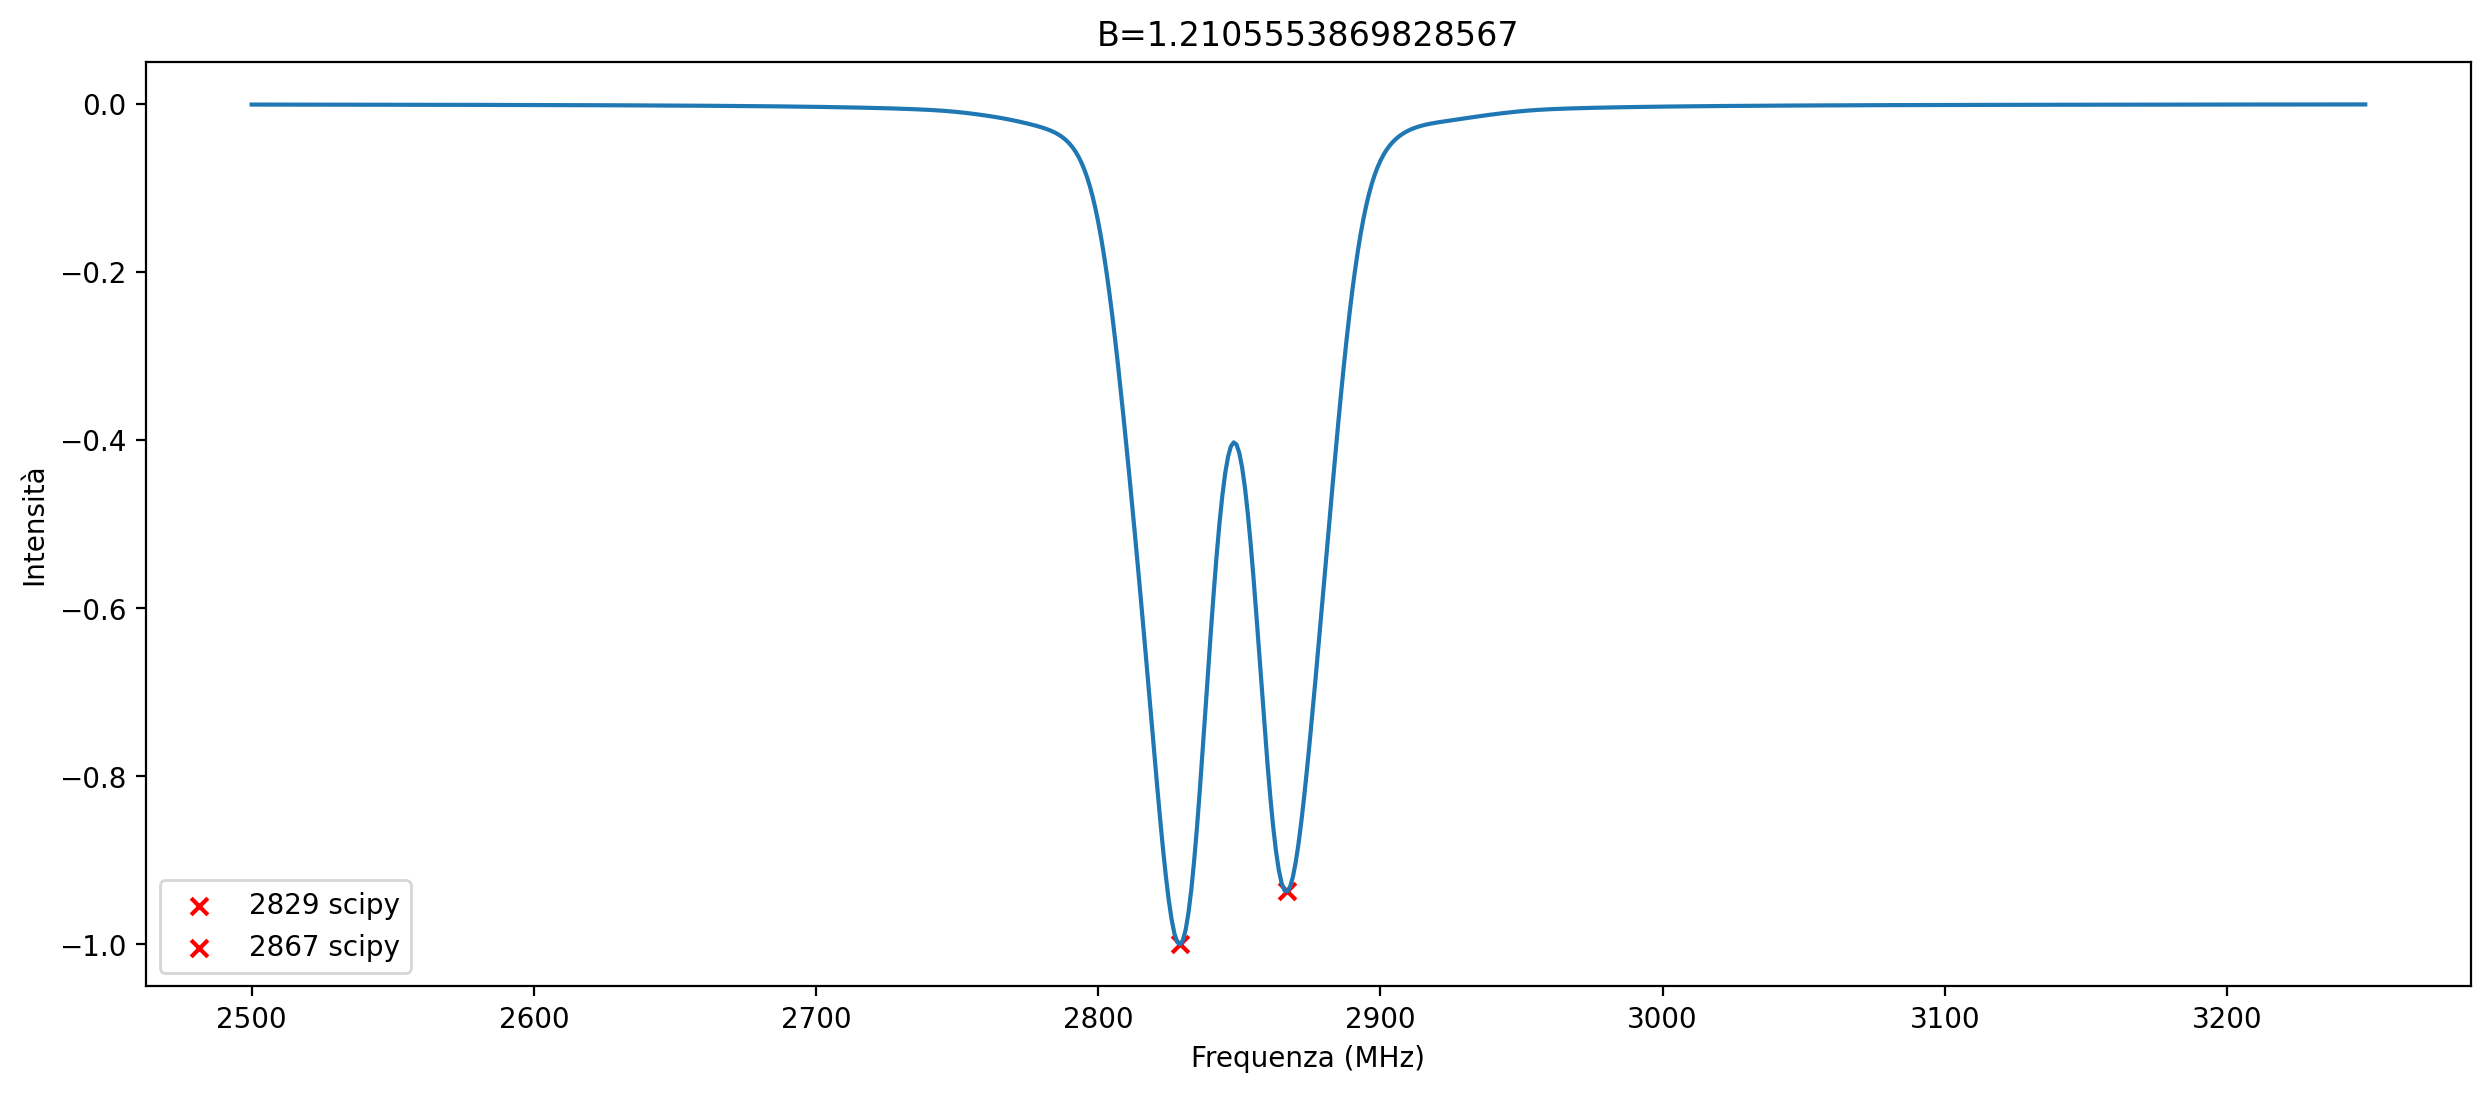

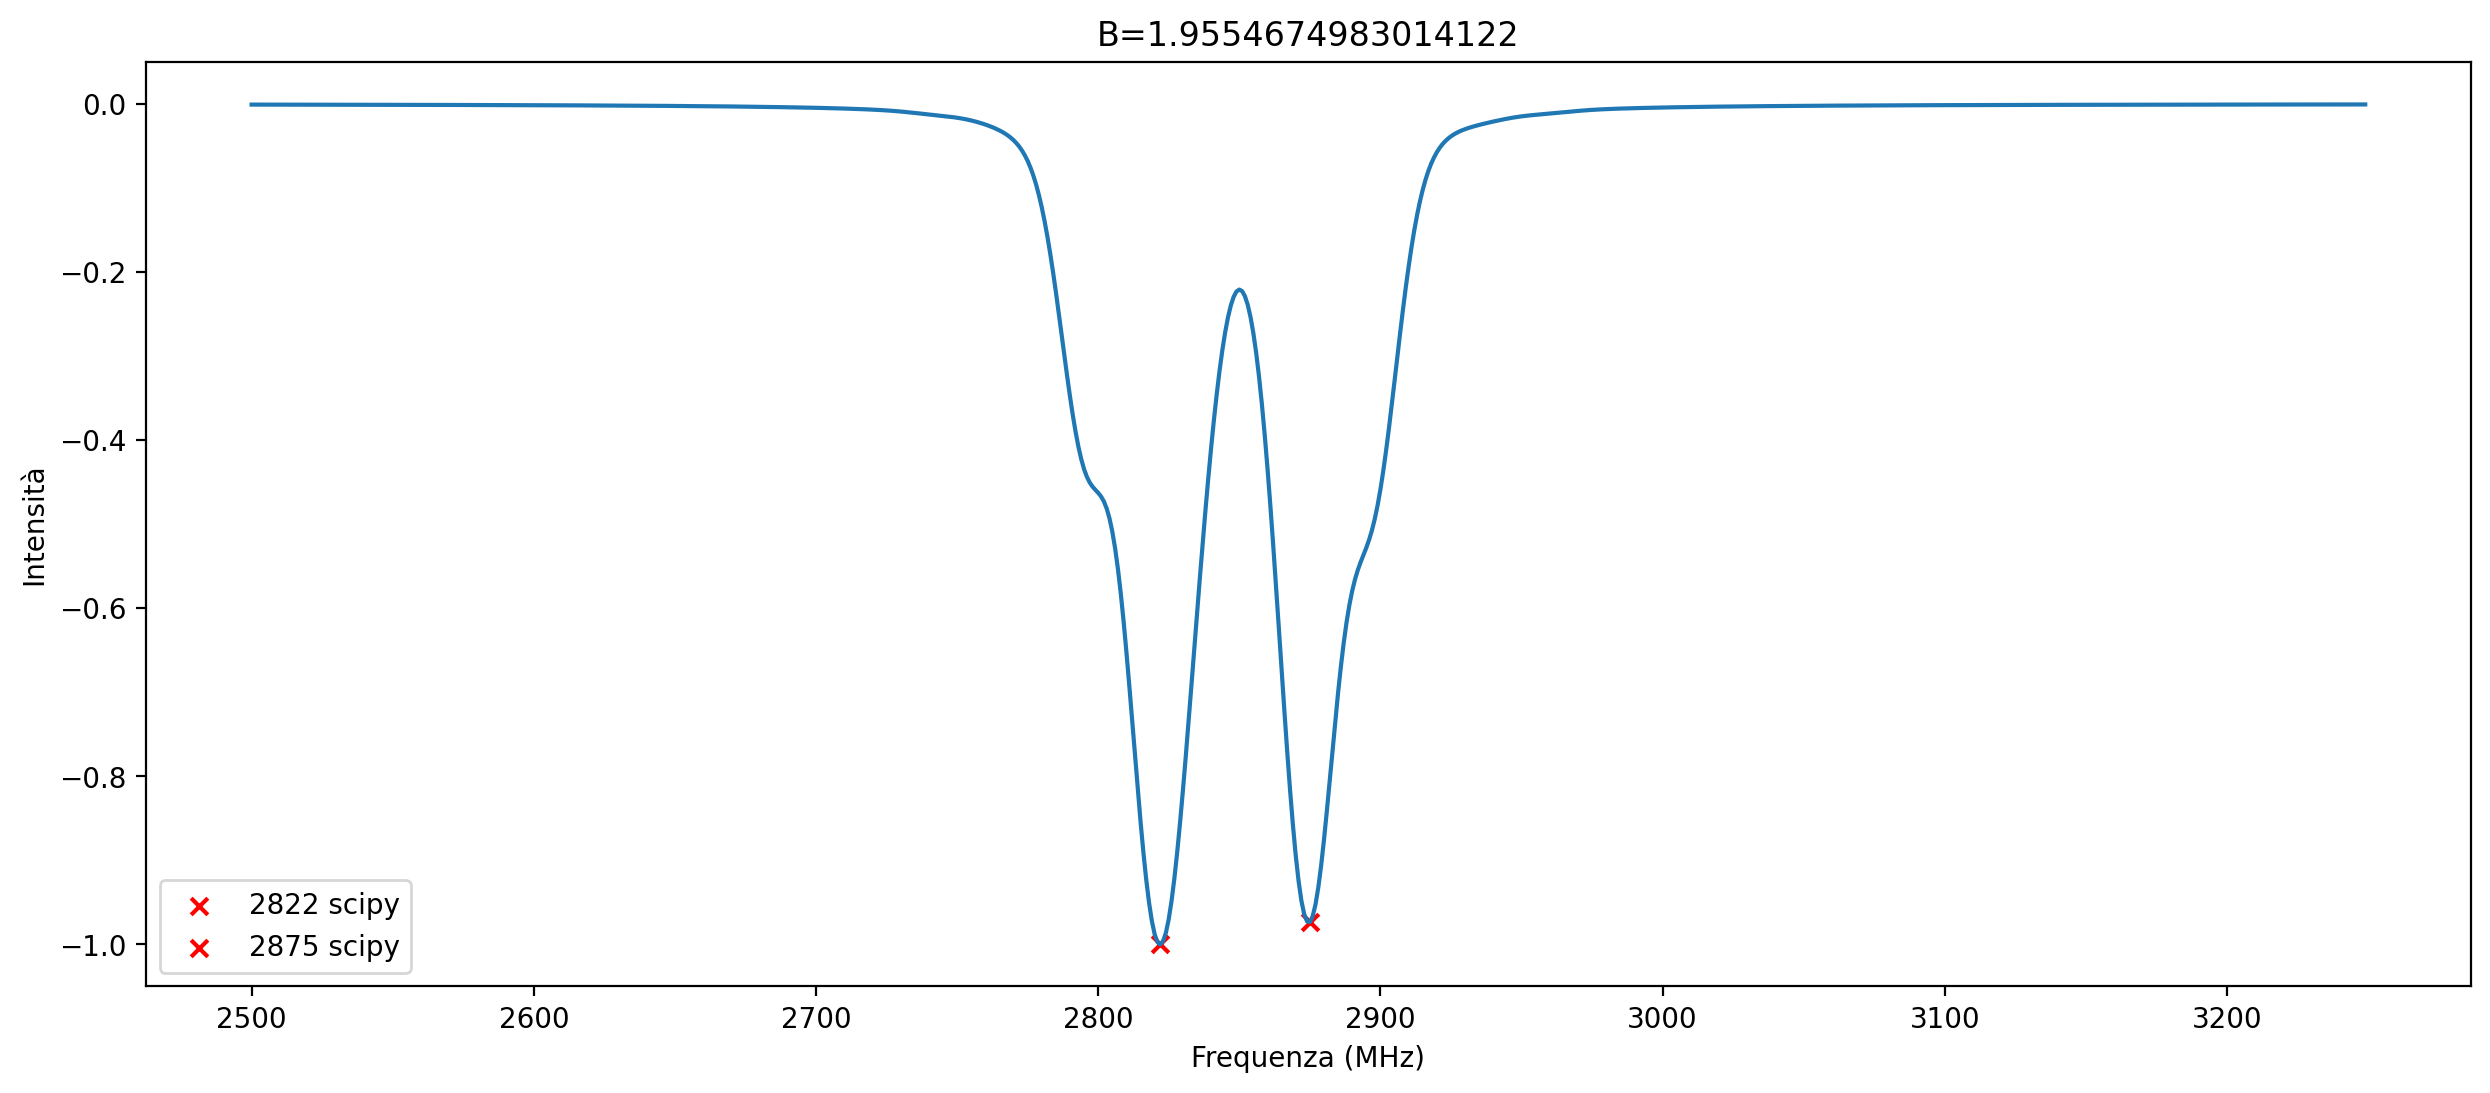

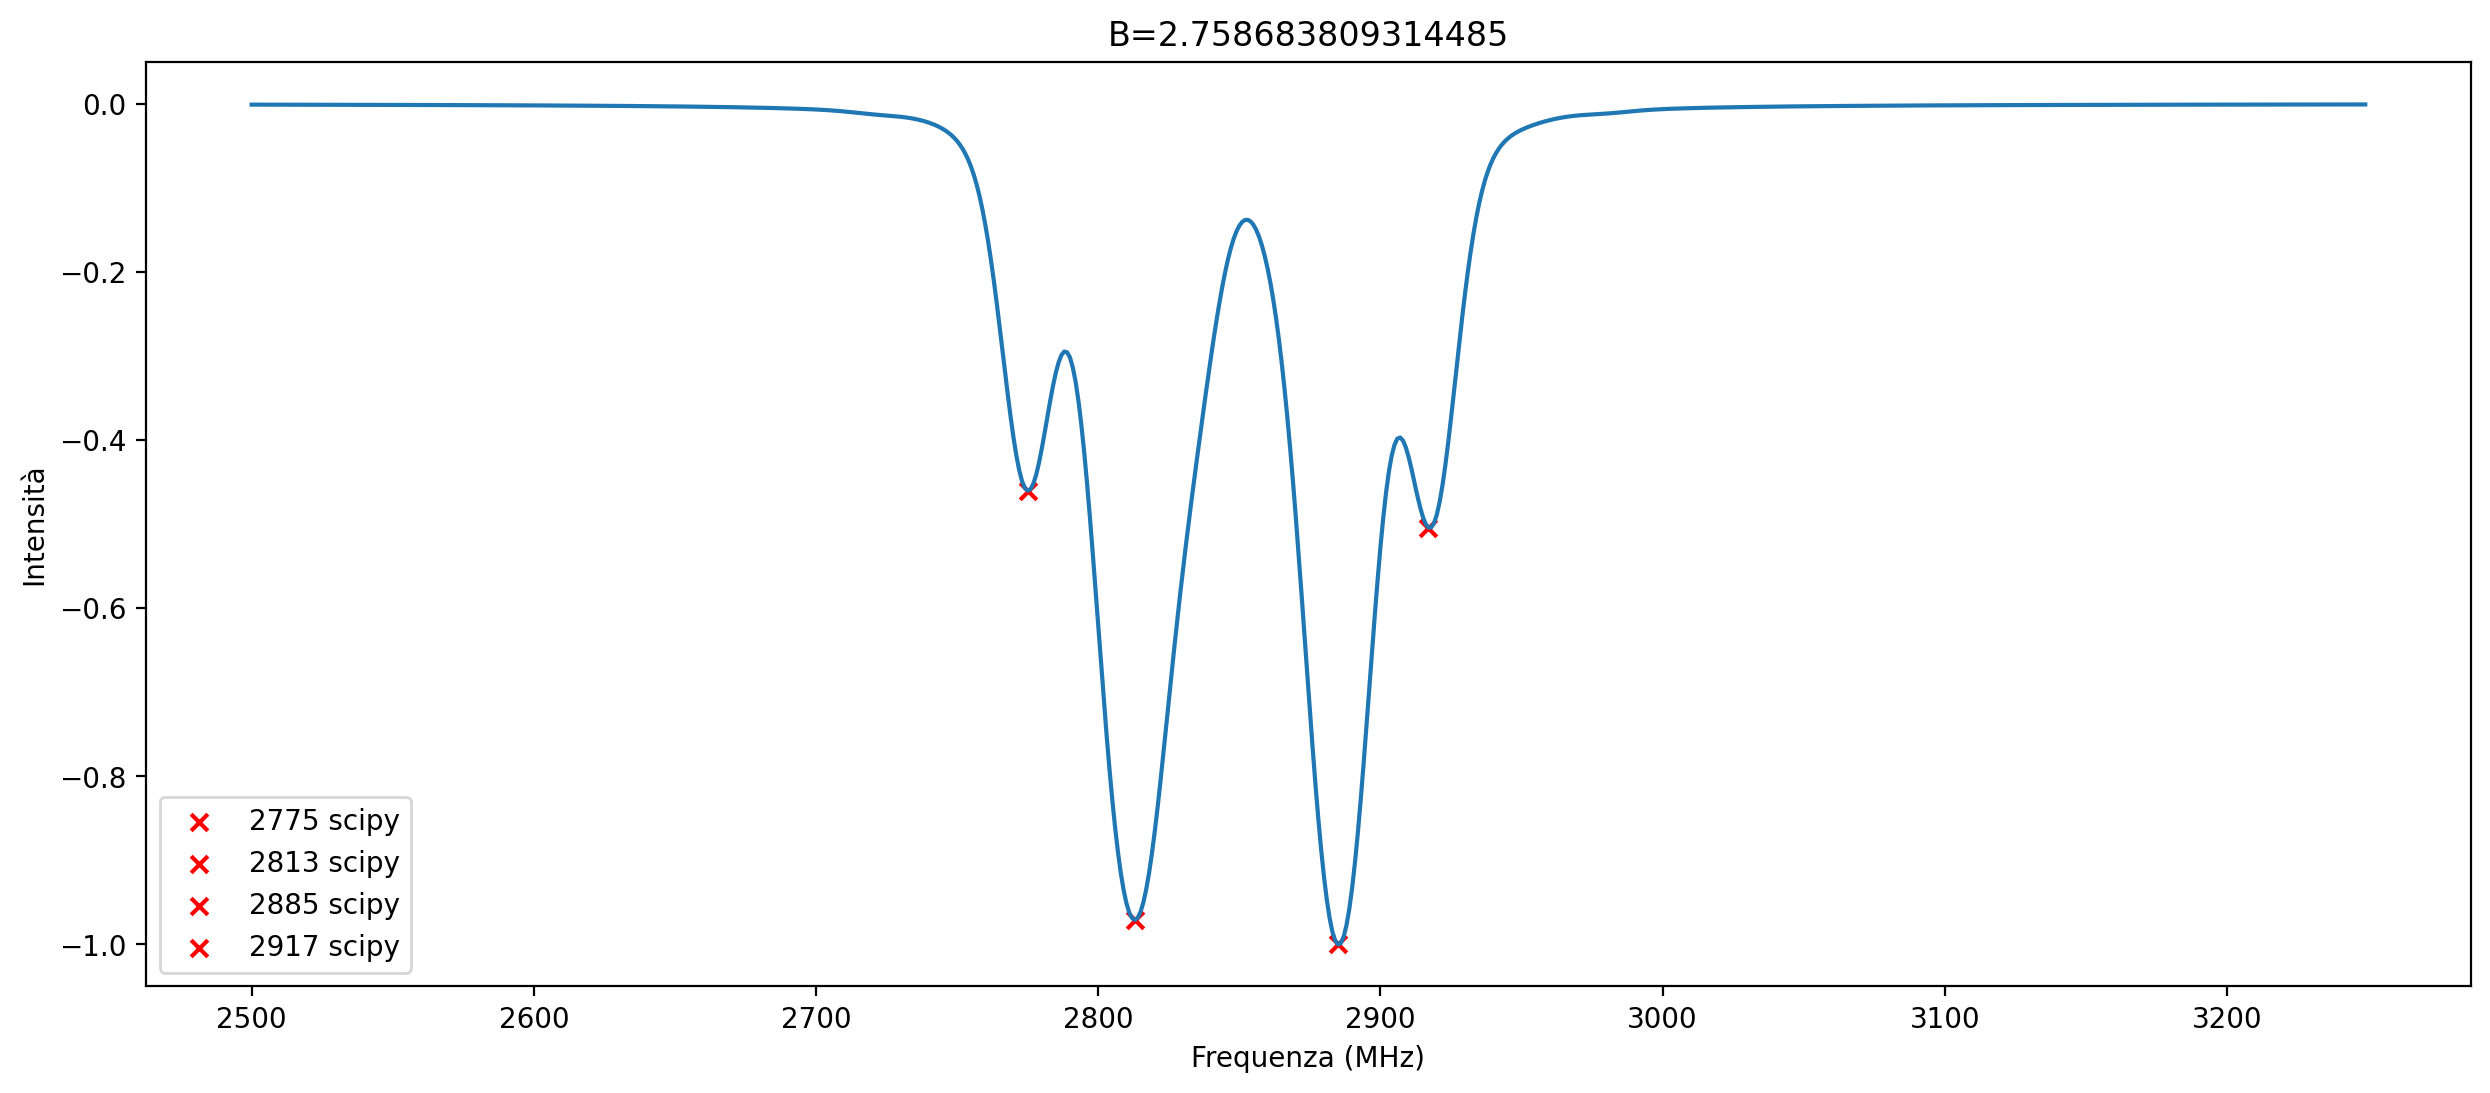

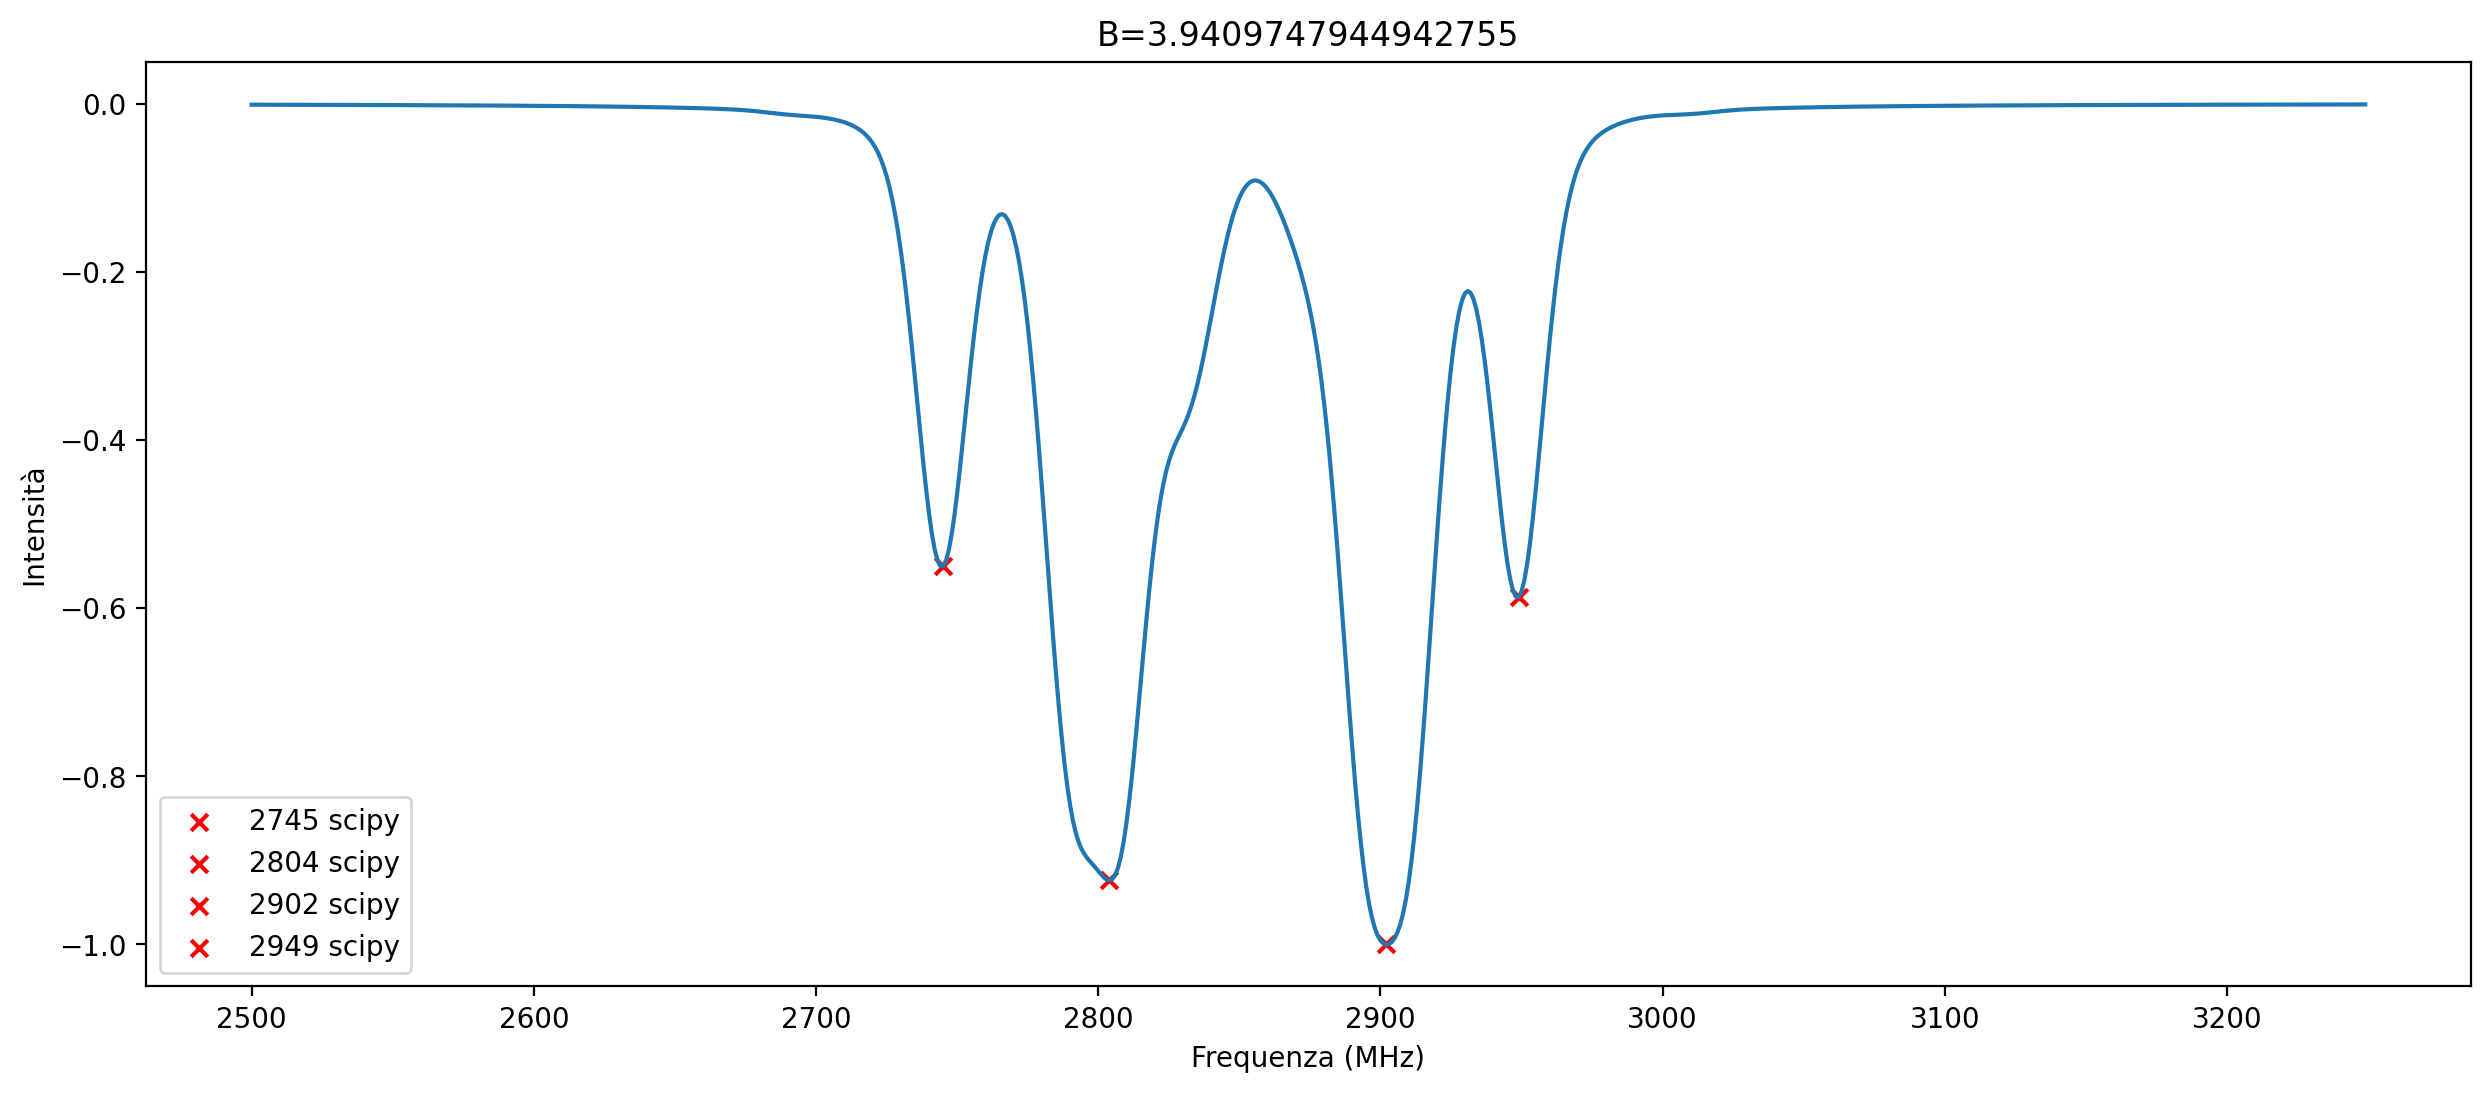

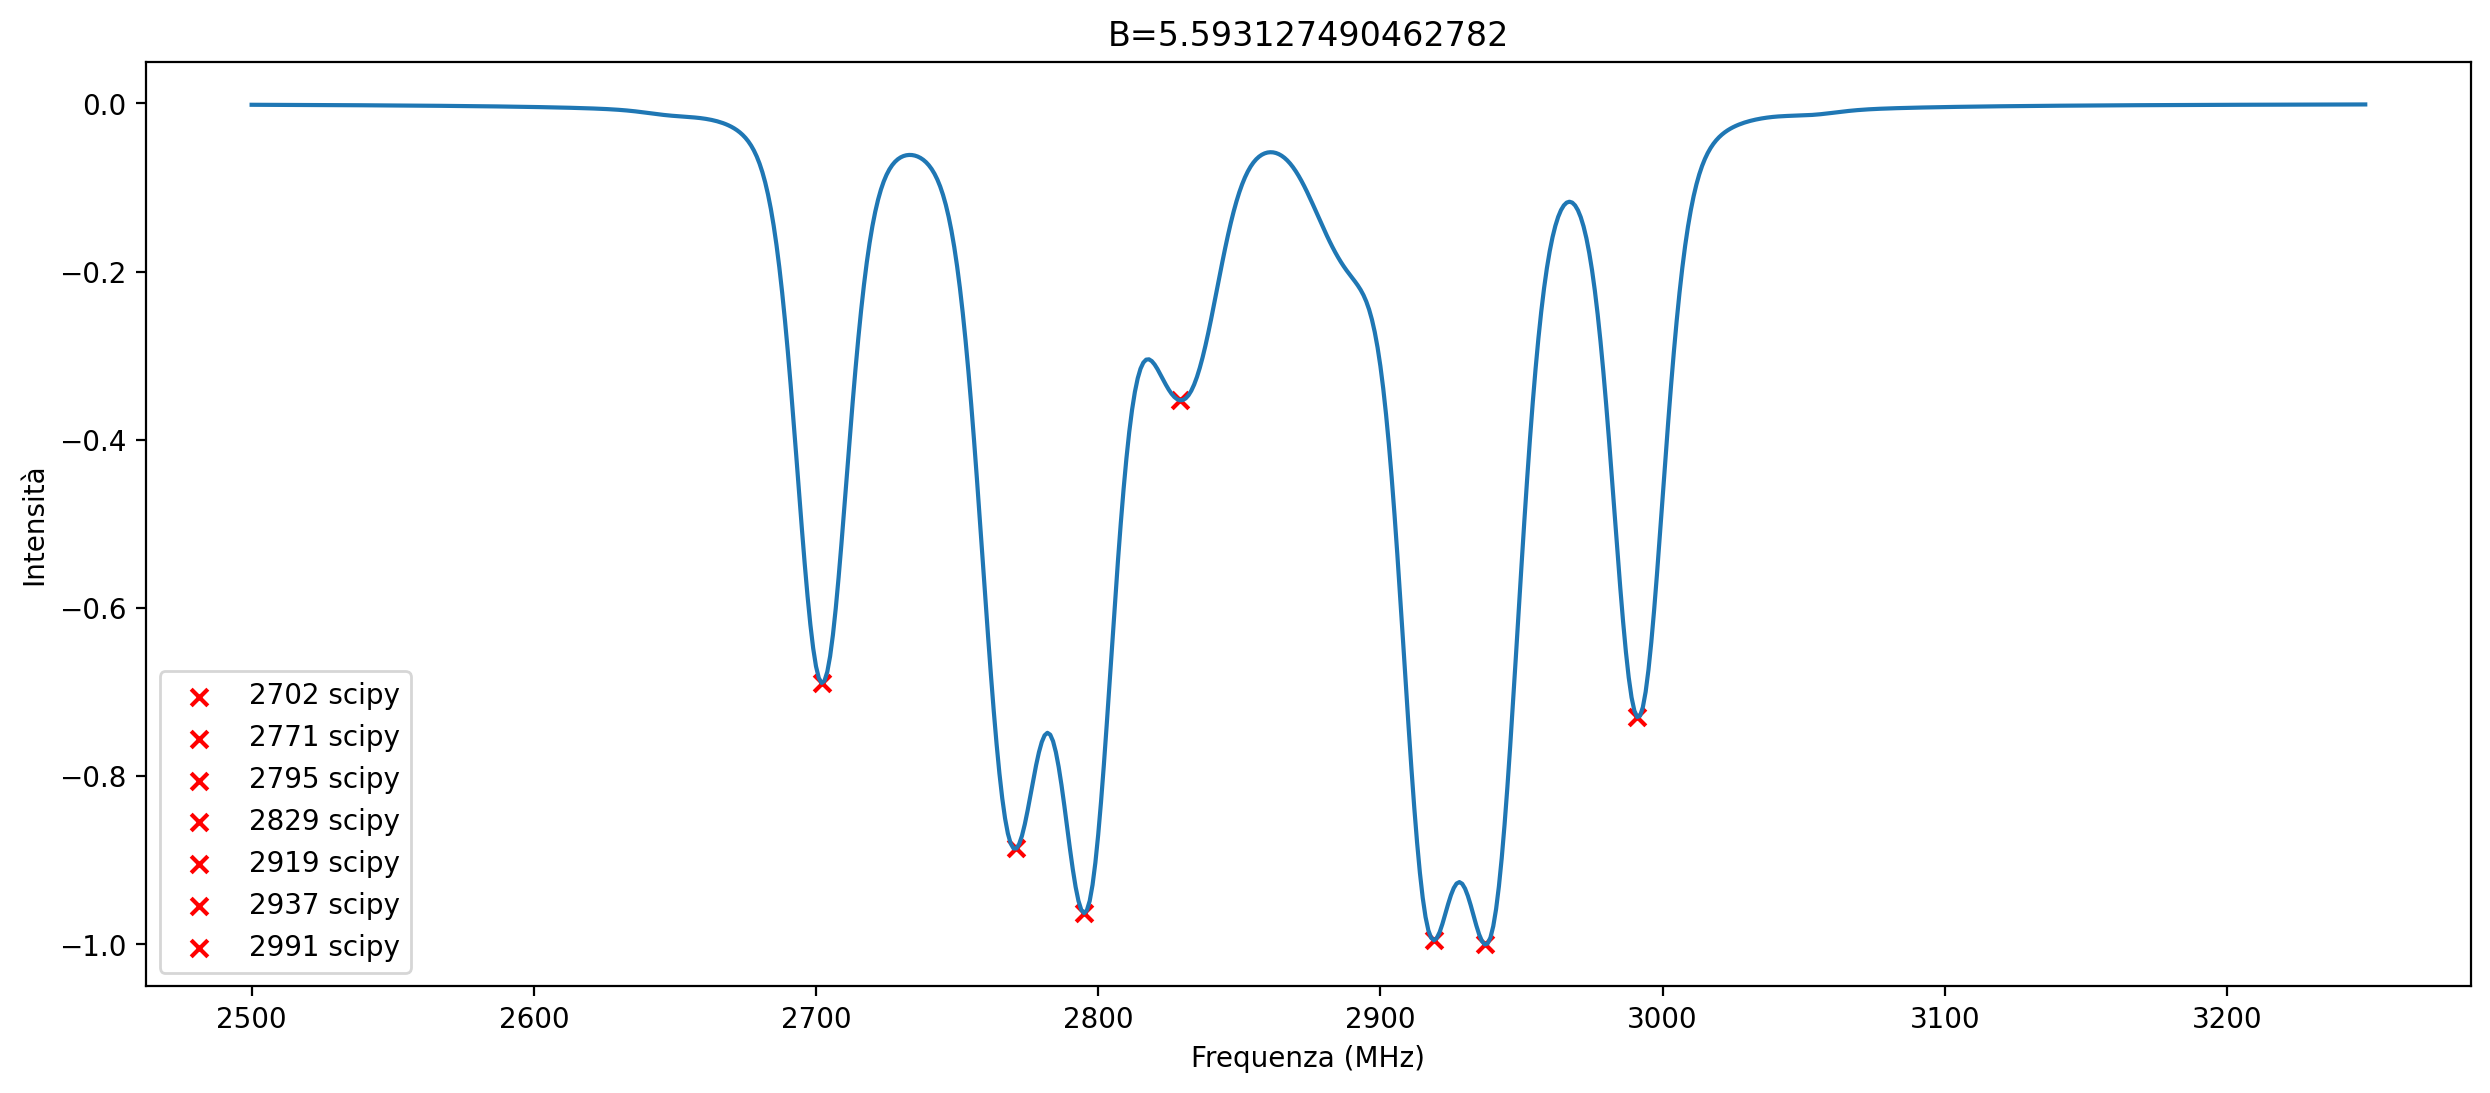

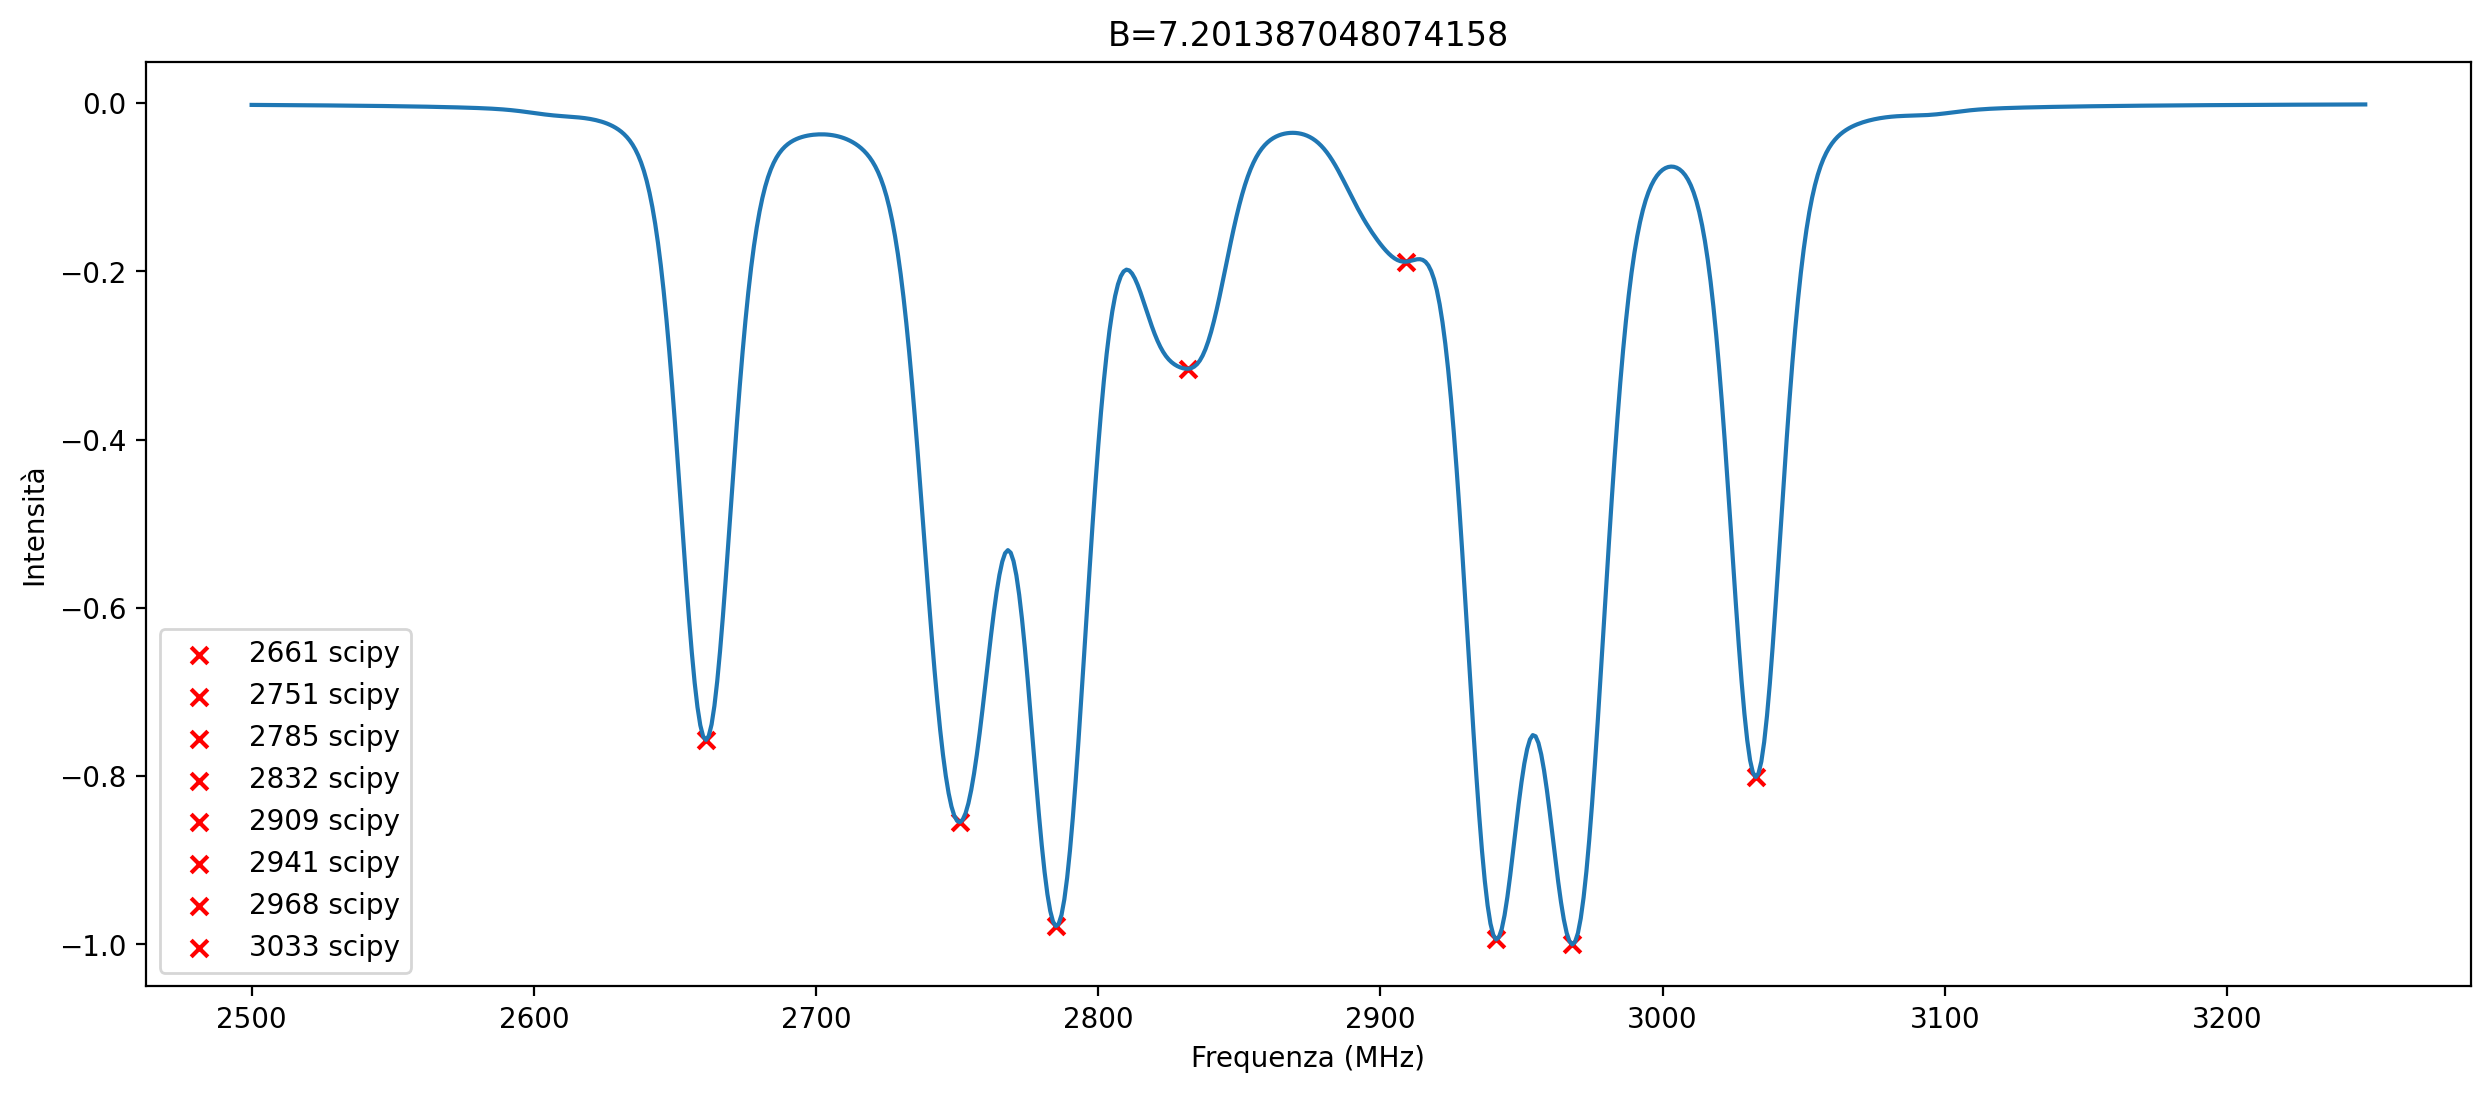

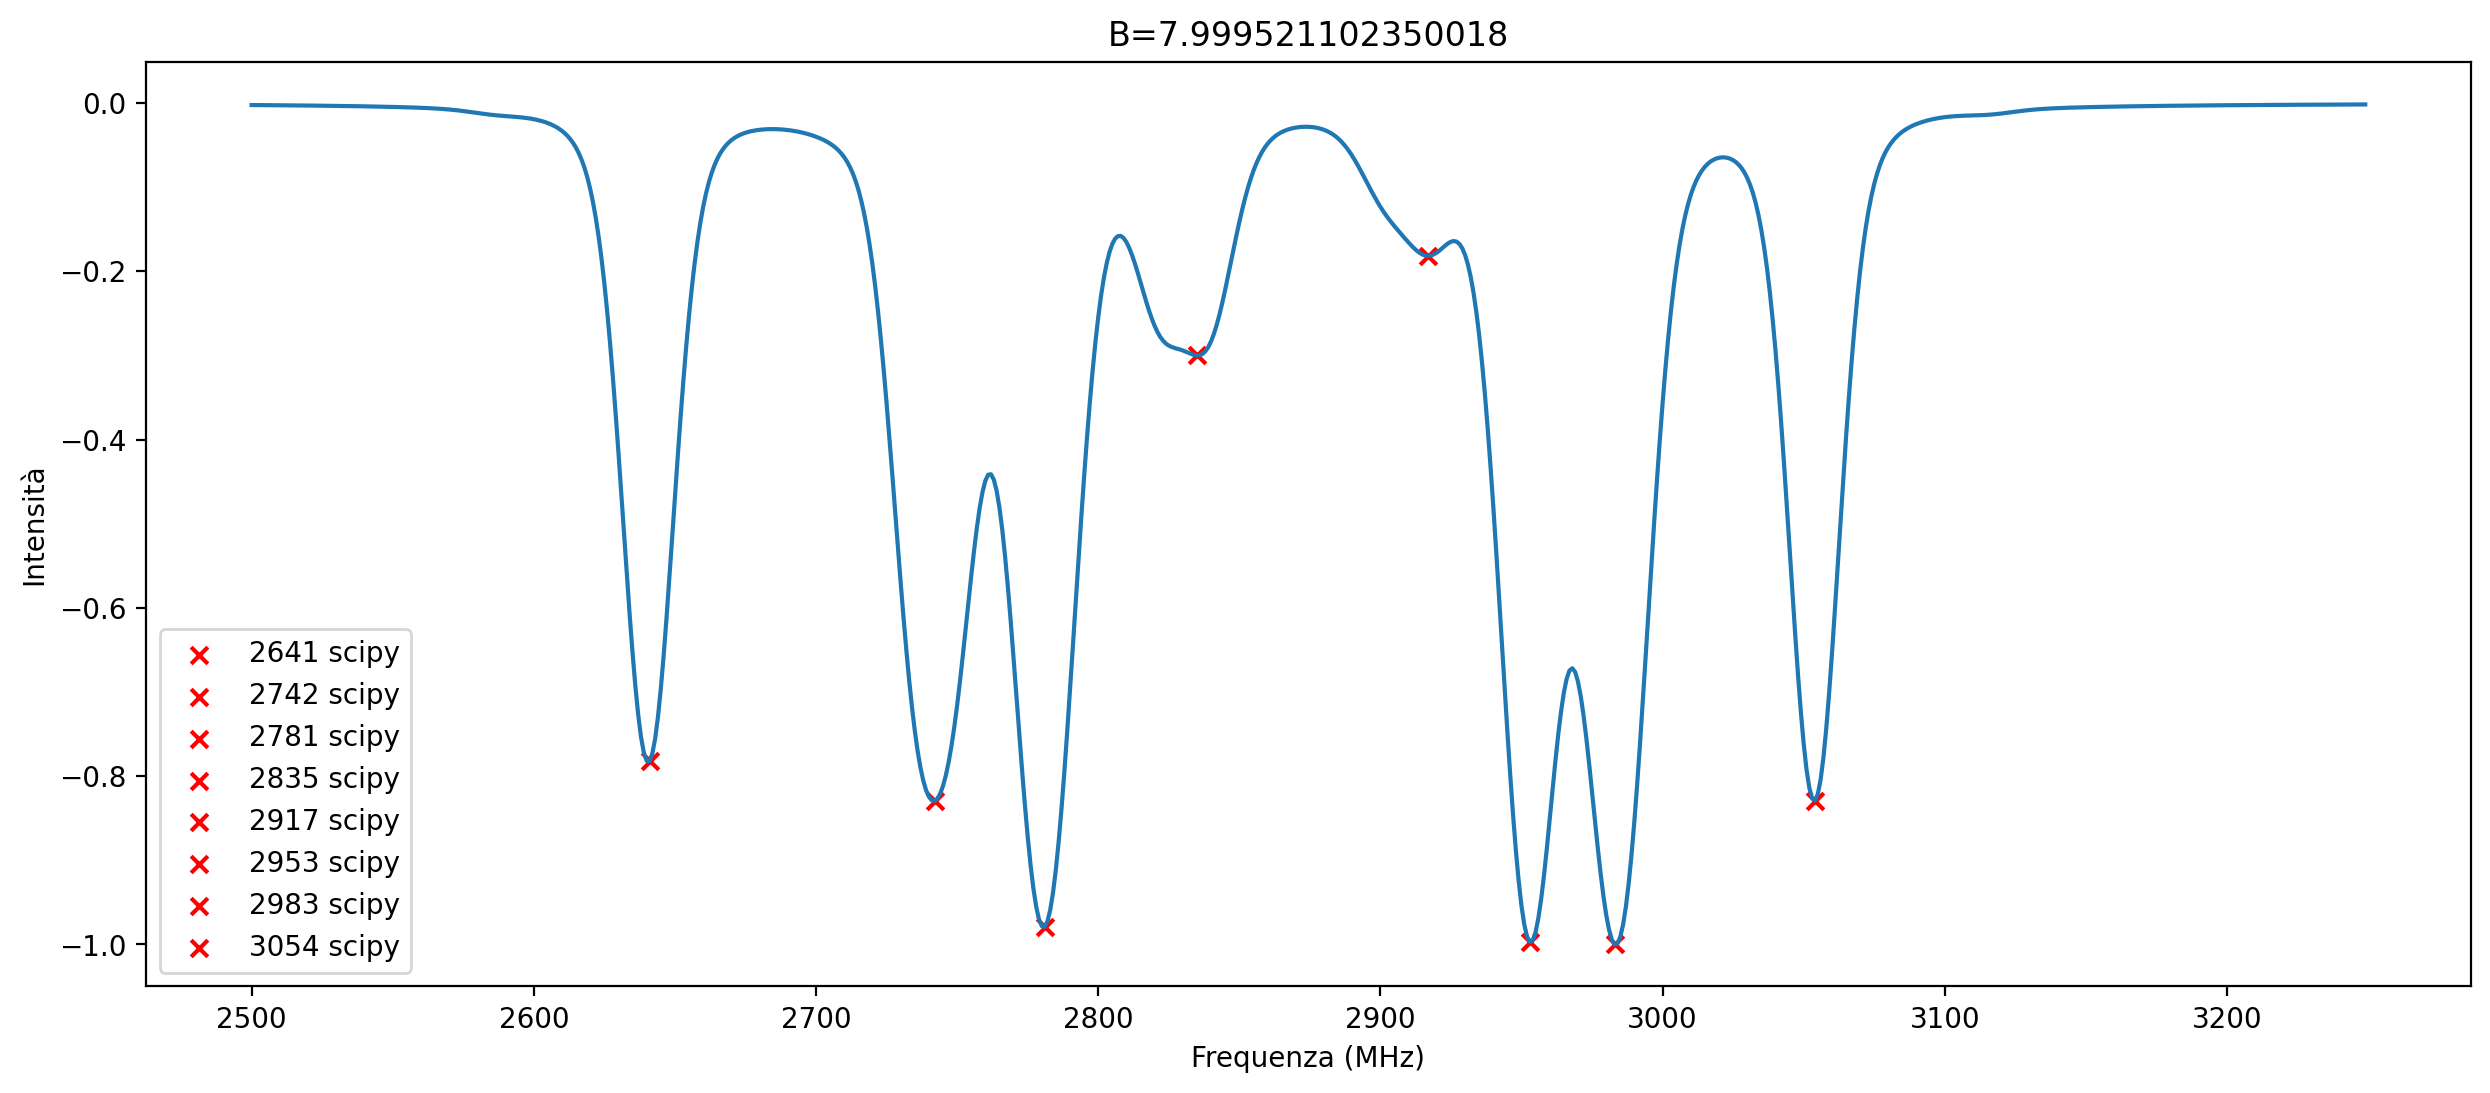

In [8]:
import matplotlib.pyplot as plt
for k in k_list:
    plt.figure(figsize=(15, 6), dpi=200)
    plt.plot(x_axis, s[k])
    for pos in posizioni_totali[k]:
        h = info_totale[k]['peak_heights'][np.where(posizioni_totali[k] == pos)[0][0]]
        plt.scatter(pos, -h, color='red', marker='x', label=f'{pos} scipy')  # Evidenziamo i picchi
    plt.title(f"B={B[k]}")
    plt.xlabel('Frequenza (MHz)')
    plt.ylabel('Intensità')
    plt.legend()
    plt.show()

provo fit

## Provo con pseudo-Voigt

combinazione lineare di lorentziana e gaussiana
$$
pV(\nu | \eta, \nu_0, \Gamma, \sigma) = \eta L(\nu | \nu_0, \Gamma) + (1-\eta) G(\nu | \nu_0, \sigma)
$$
con
$$
\begin{cases}
L(\nu | \nu_0, \Gamma) = 
\frac{\Gamma}{\pi[(\nu-\nu_0)^2 + \Gamma^2]}\\
G(\nu | \nu_0, \sigma) = 
\frac{1}{sigma\sqrt{2\pi}}e^\frac{(\nu-\nu_0)^2}{2\sigma^2}
\end{cases}
$$

In [9]:
from ml_odmr.otto_voigt import fit_otto_pseudo_voigt, otto_pseudo_voigt

ampiezze_fit, posizioni_fit, gamma_fit, sigma_fit, eta_fit, y0_fit = {}, {}, {}, {}, {}, {}

In [10]:
for k in k_list:
    ampiezze_fit[k], posizioni_fit[k], gamma_fit[k], sigma_fit[k], eta_fit[k], y0_fit[k] = fit_otto_pseudo_voigt(
        f,
        s[k],
        info_totale[k]['peak_heights'],
        posizioni_totali[k],
        info_totale[k]['widths'],
        info_totale[k]['widths']*0.5,  # Stima iniziale per sigma (gaussiana) come metà di gamma (lorentziana)
        np.full_like(info_totale[k]['widths'], 0.5)  # Stima iniziale per eta (mix tra gaussiana e lorentziana) a 0.5
    )

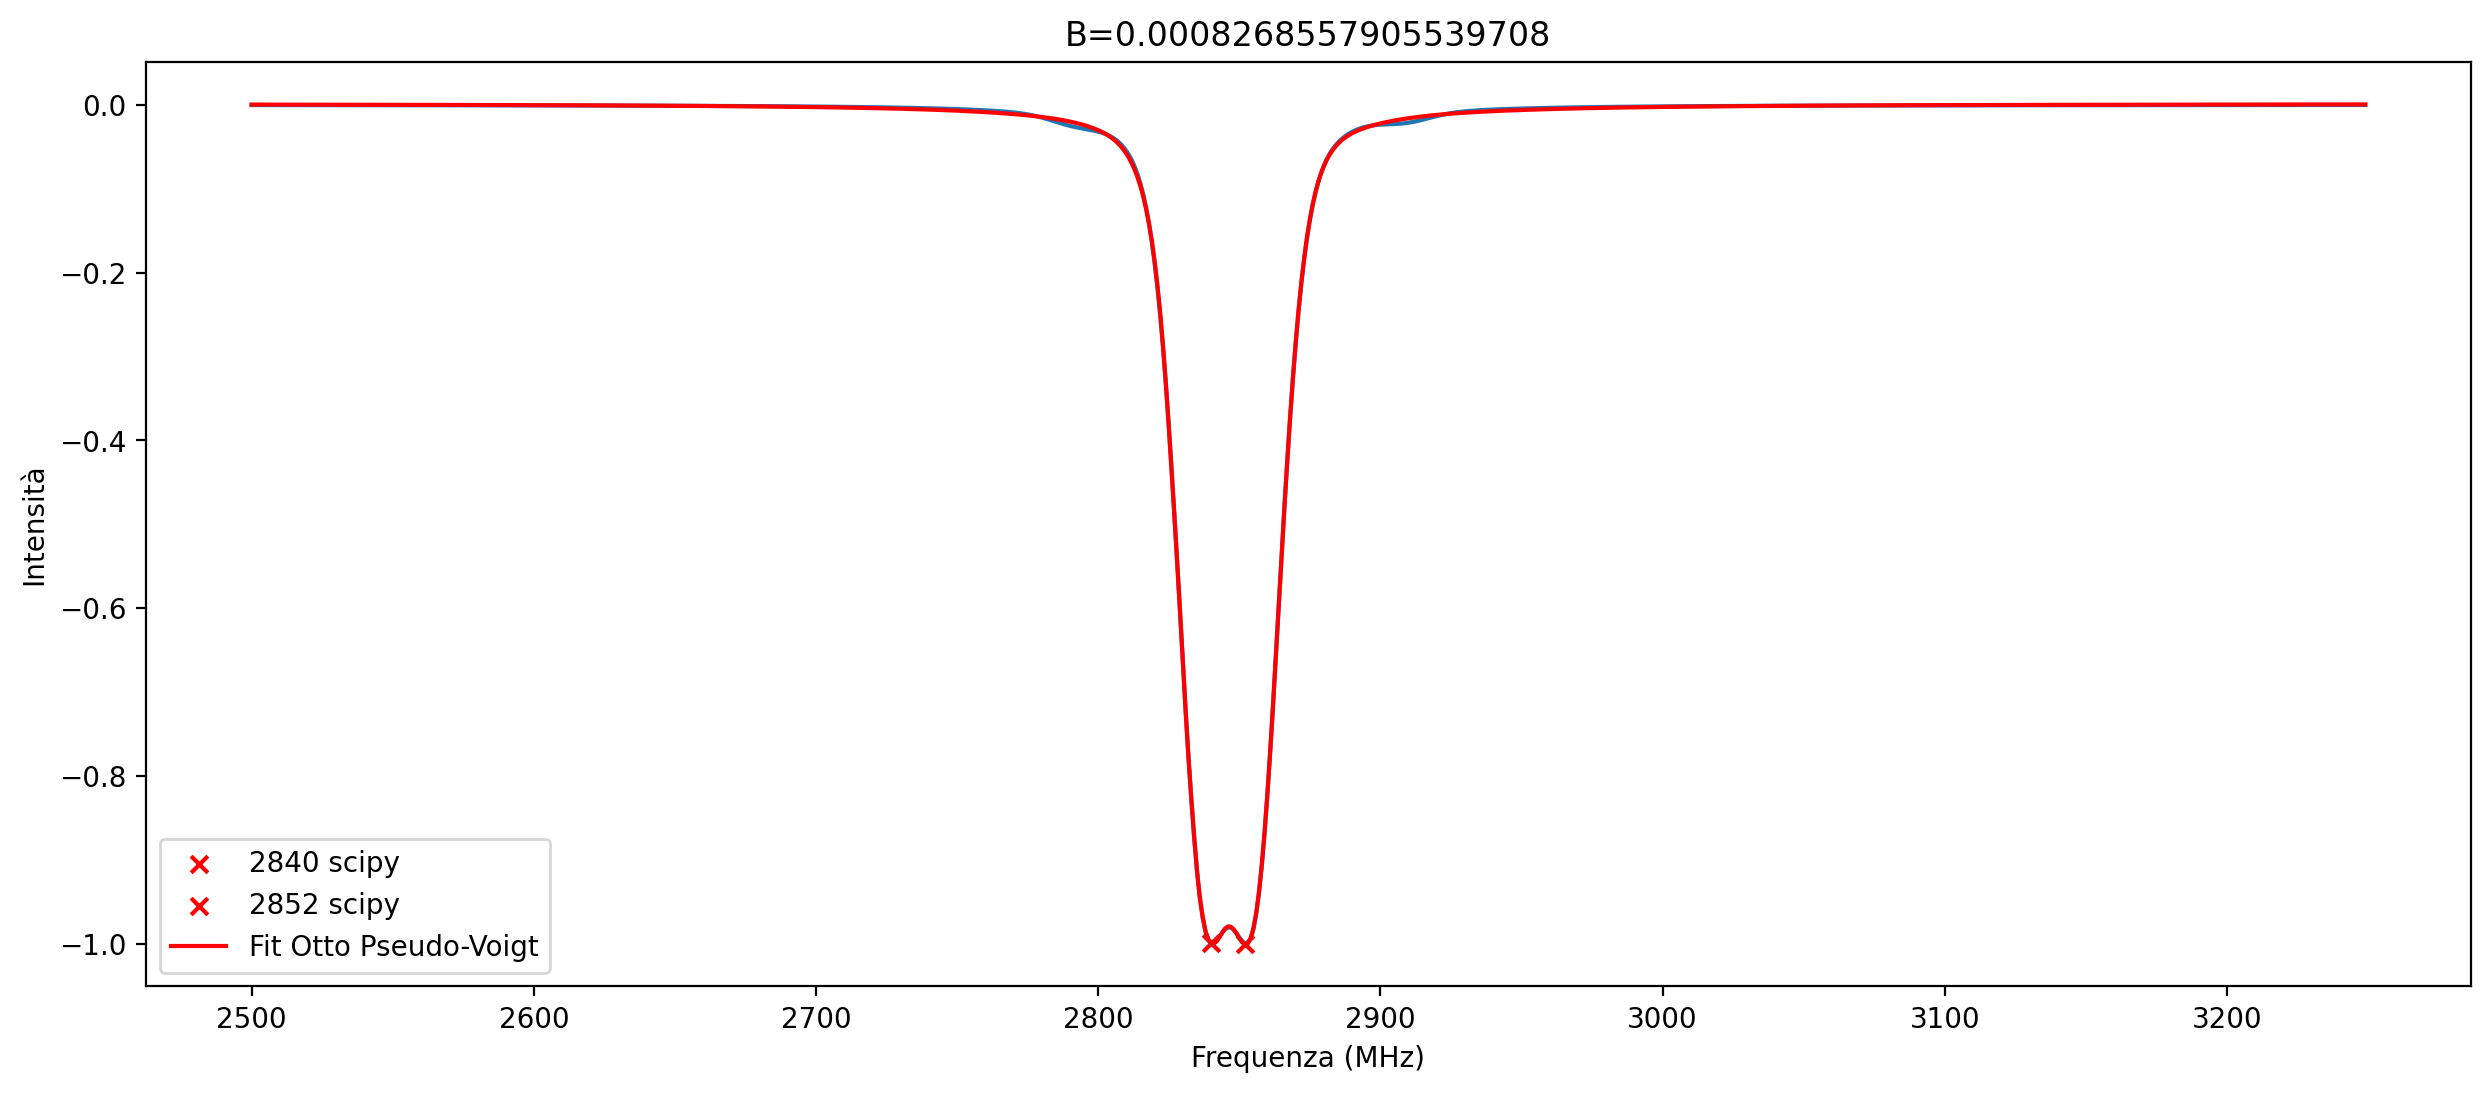

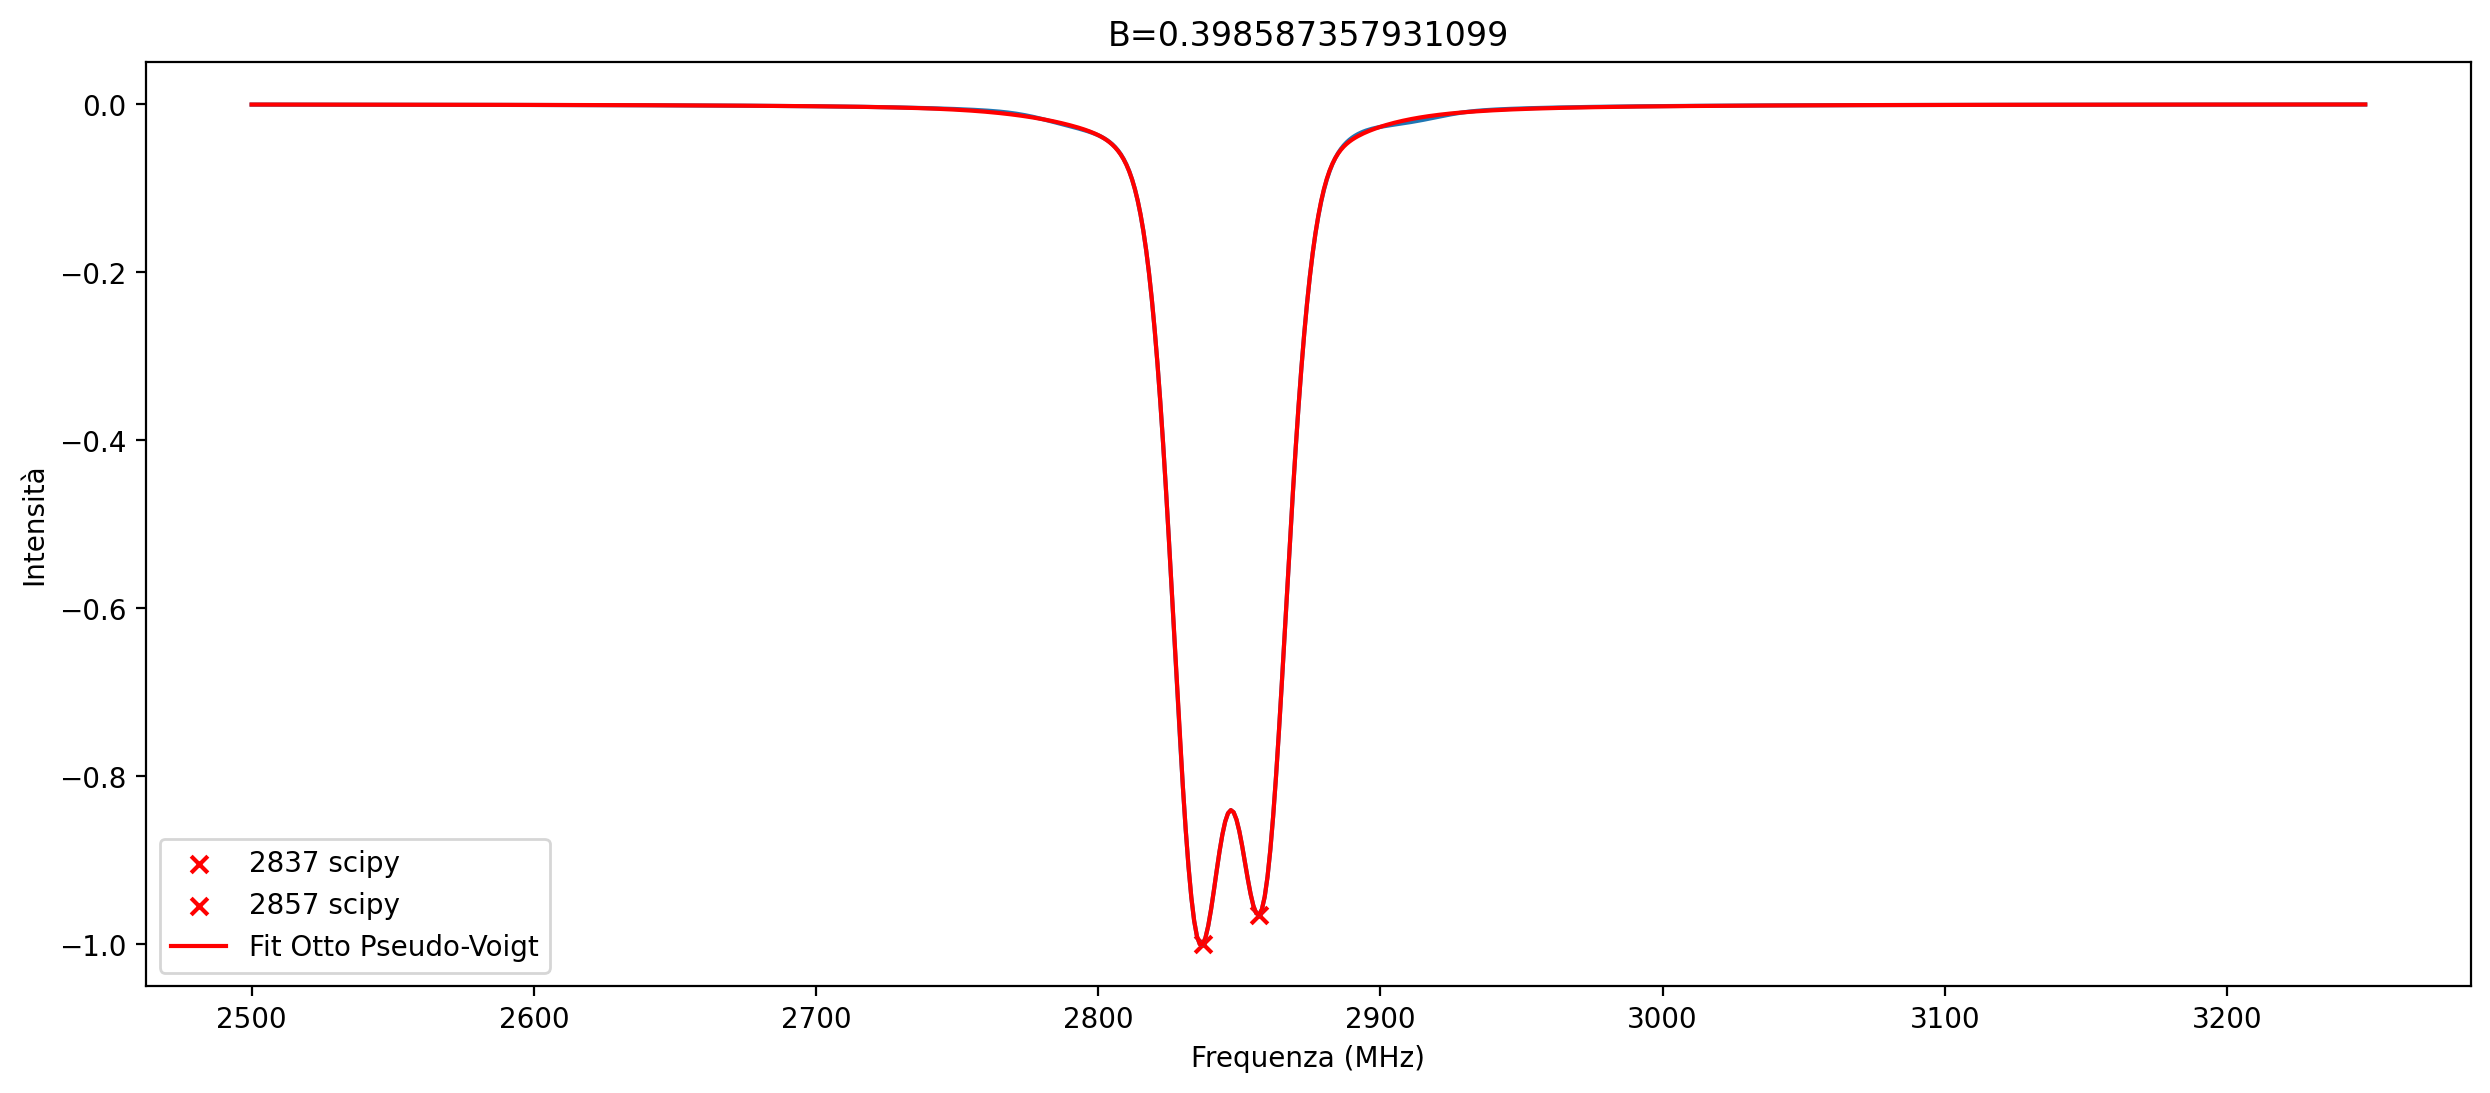

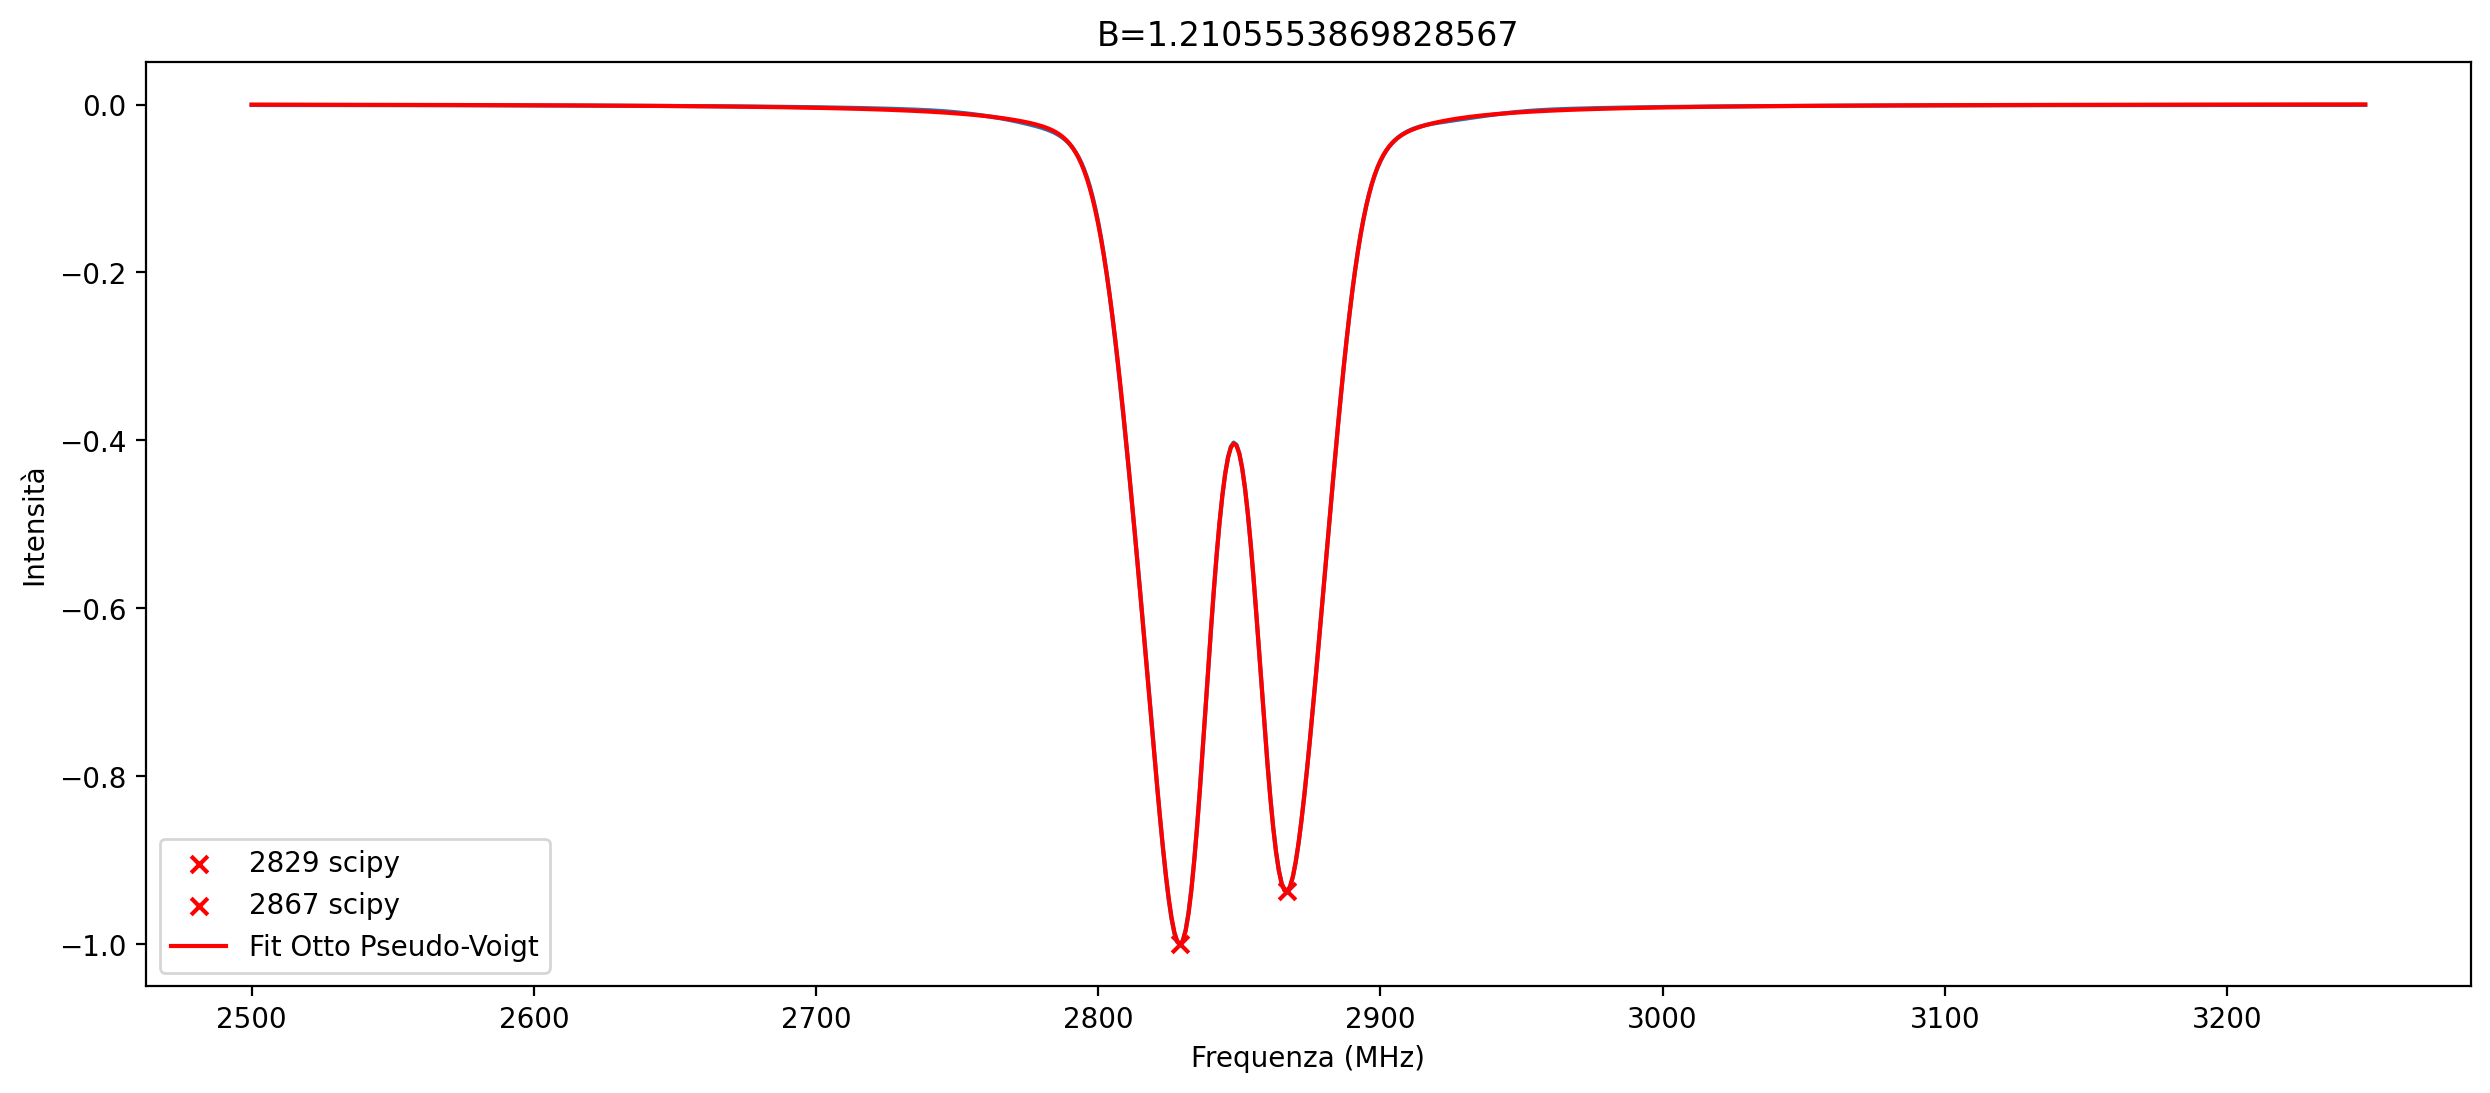

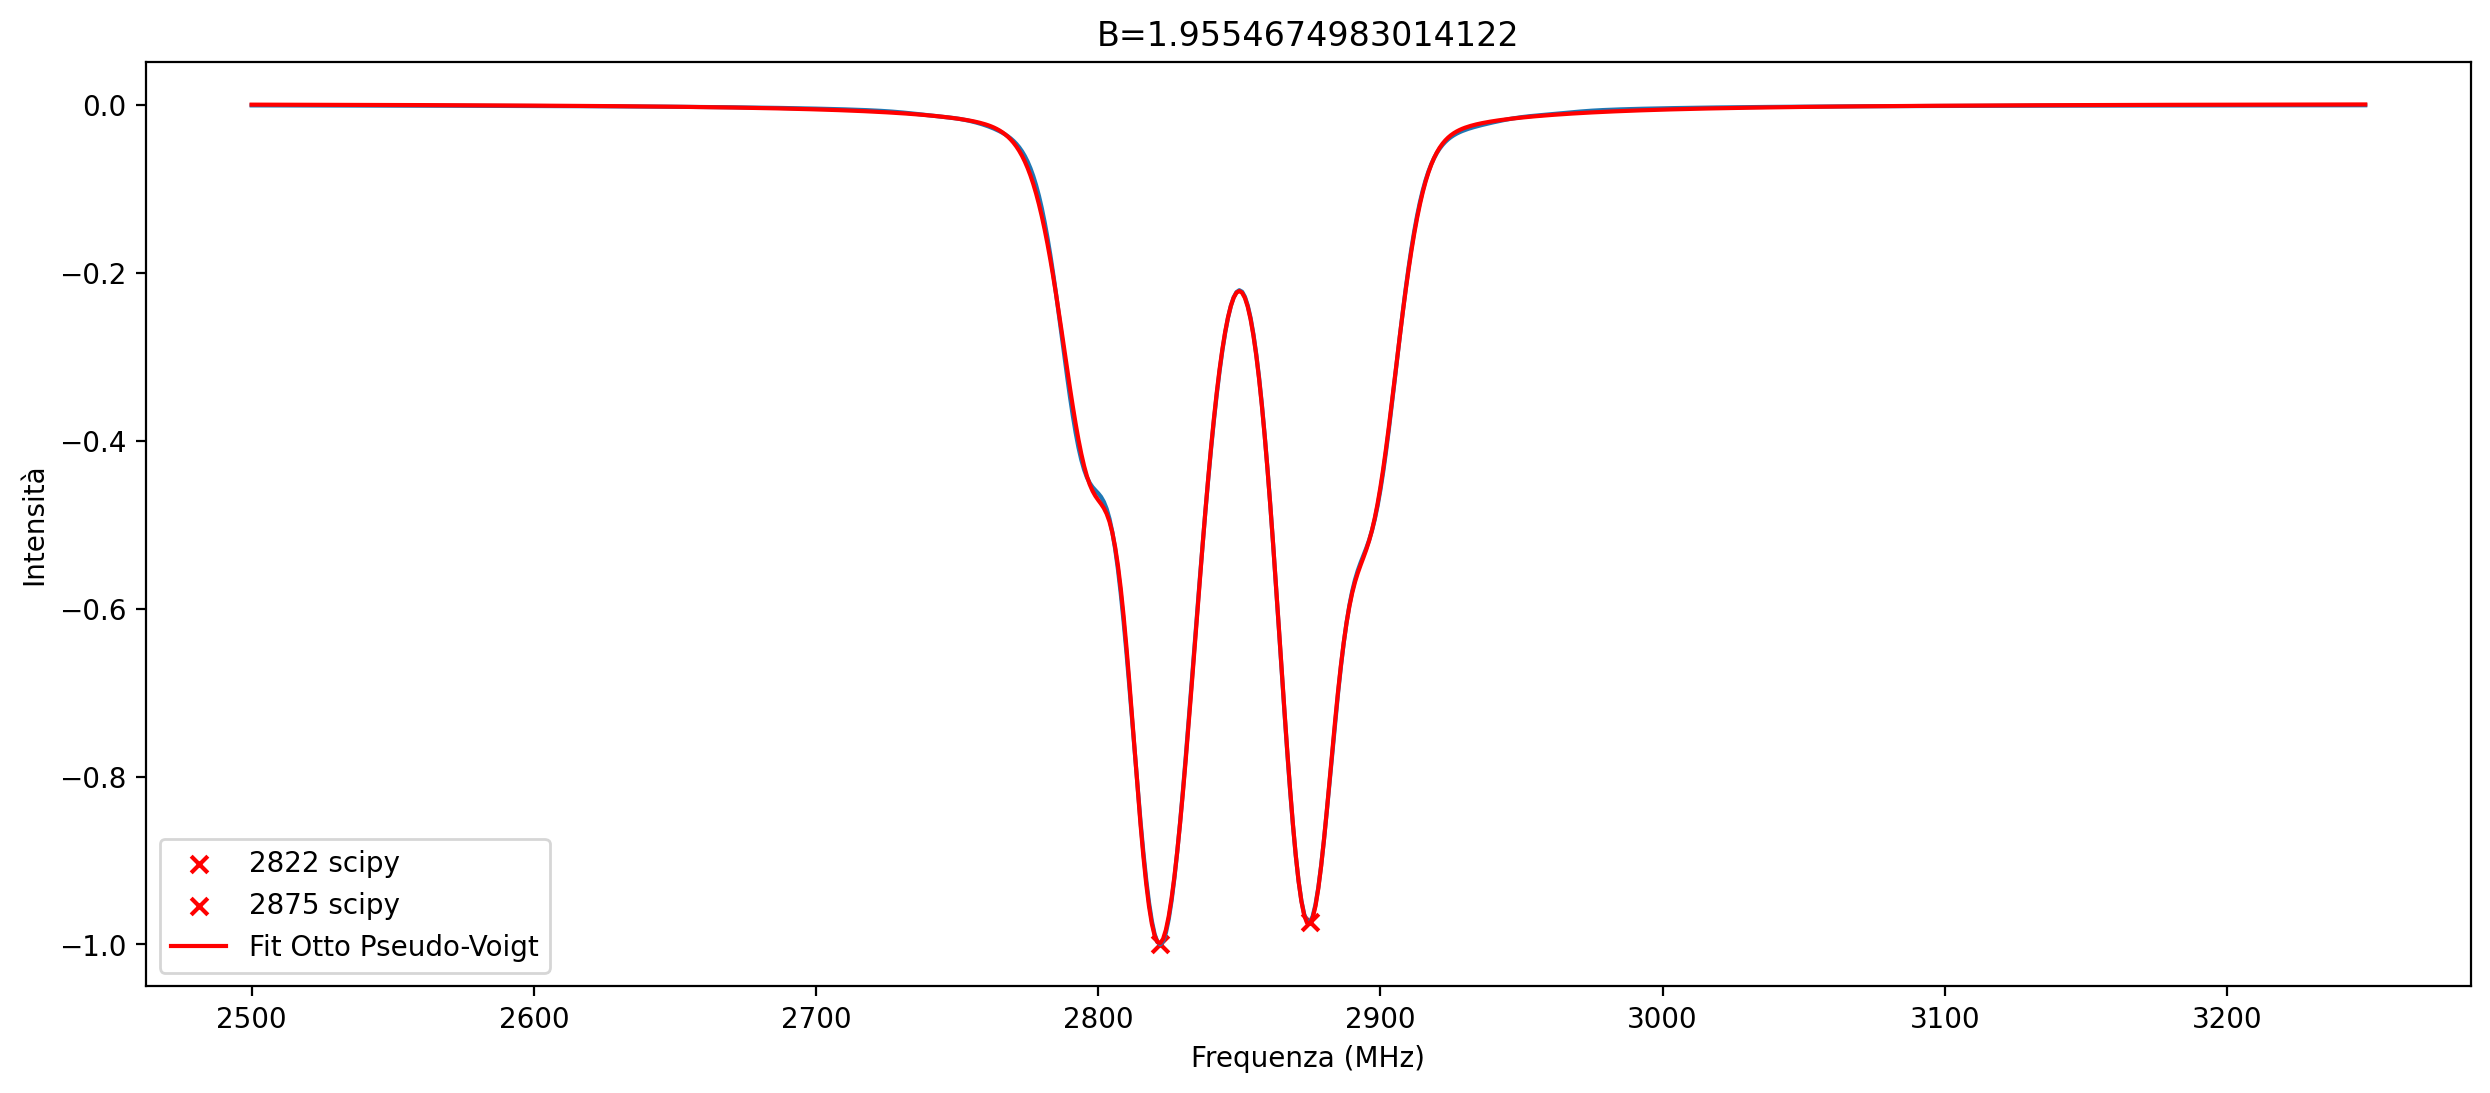

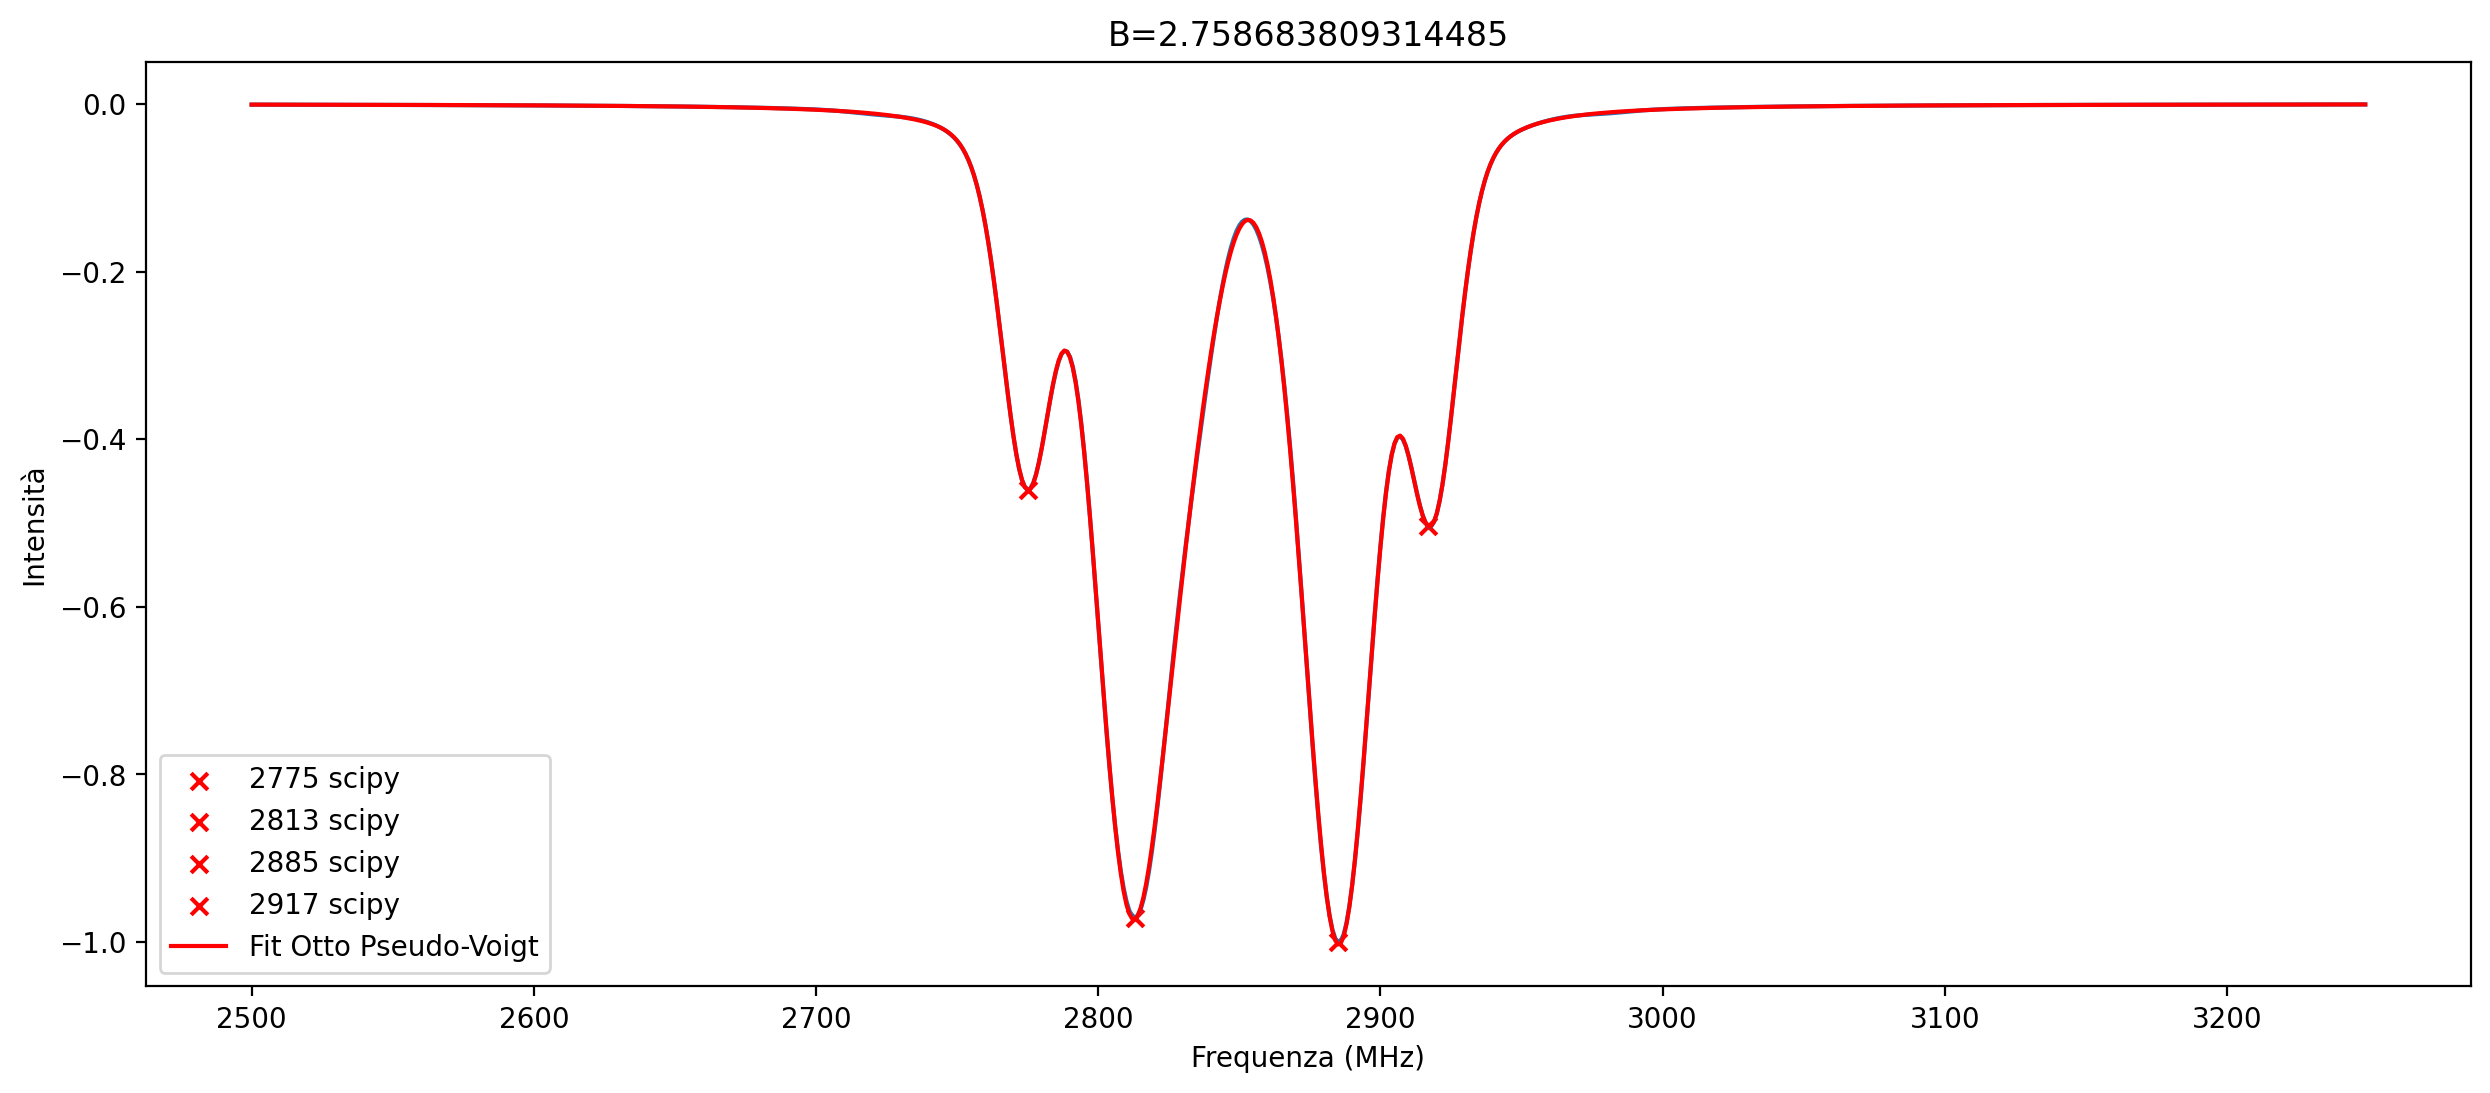

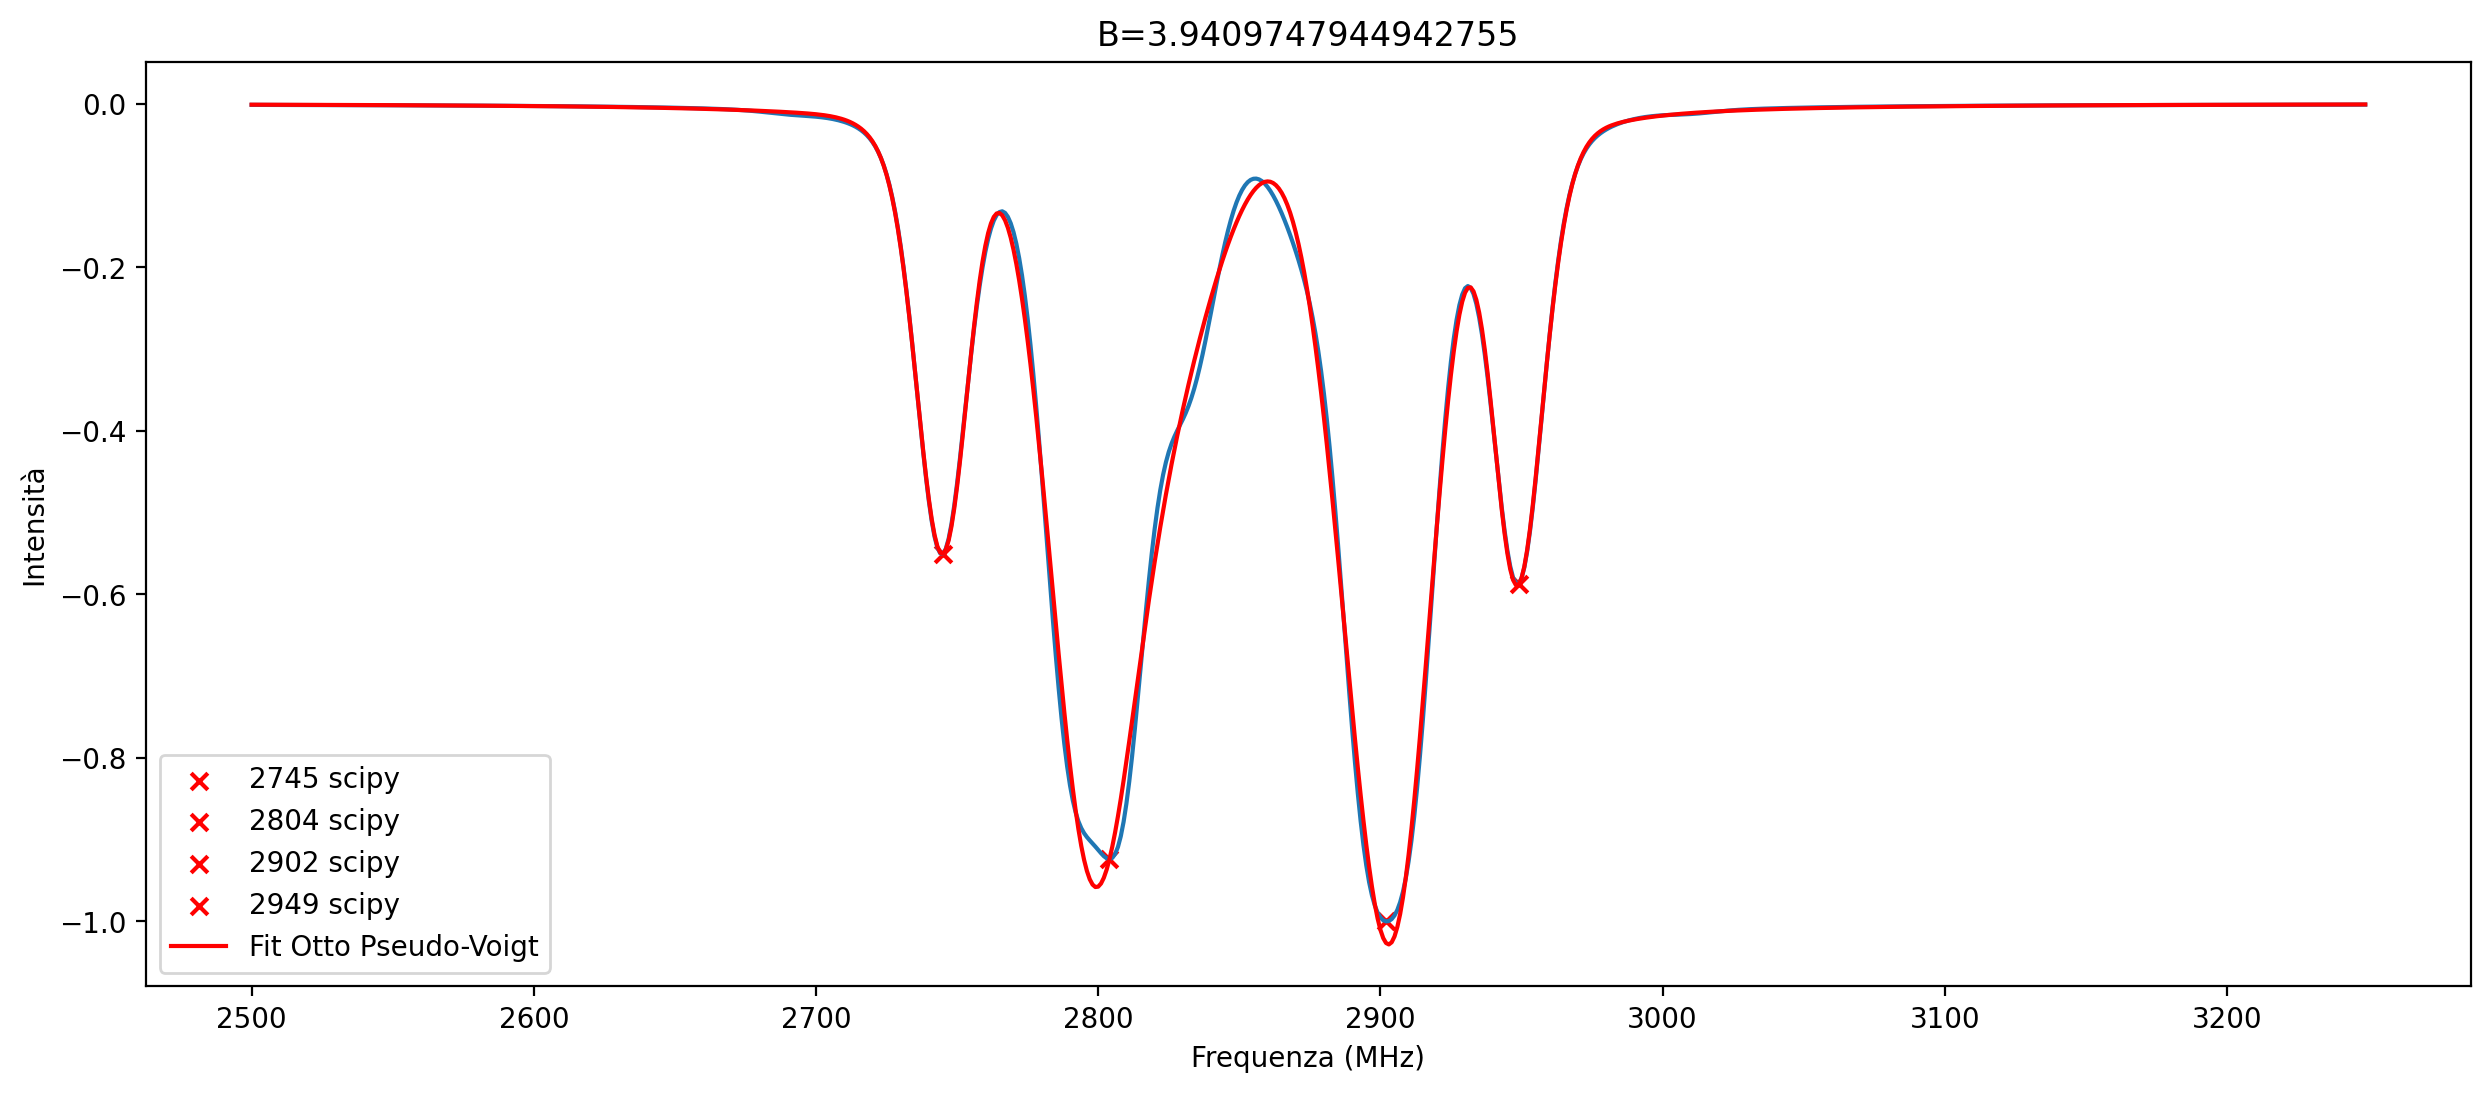

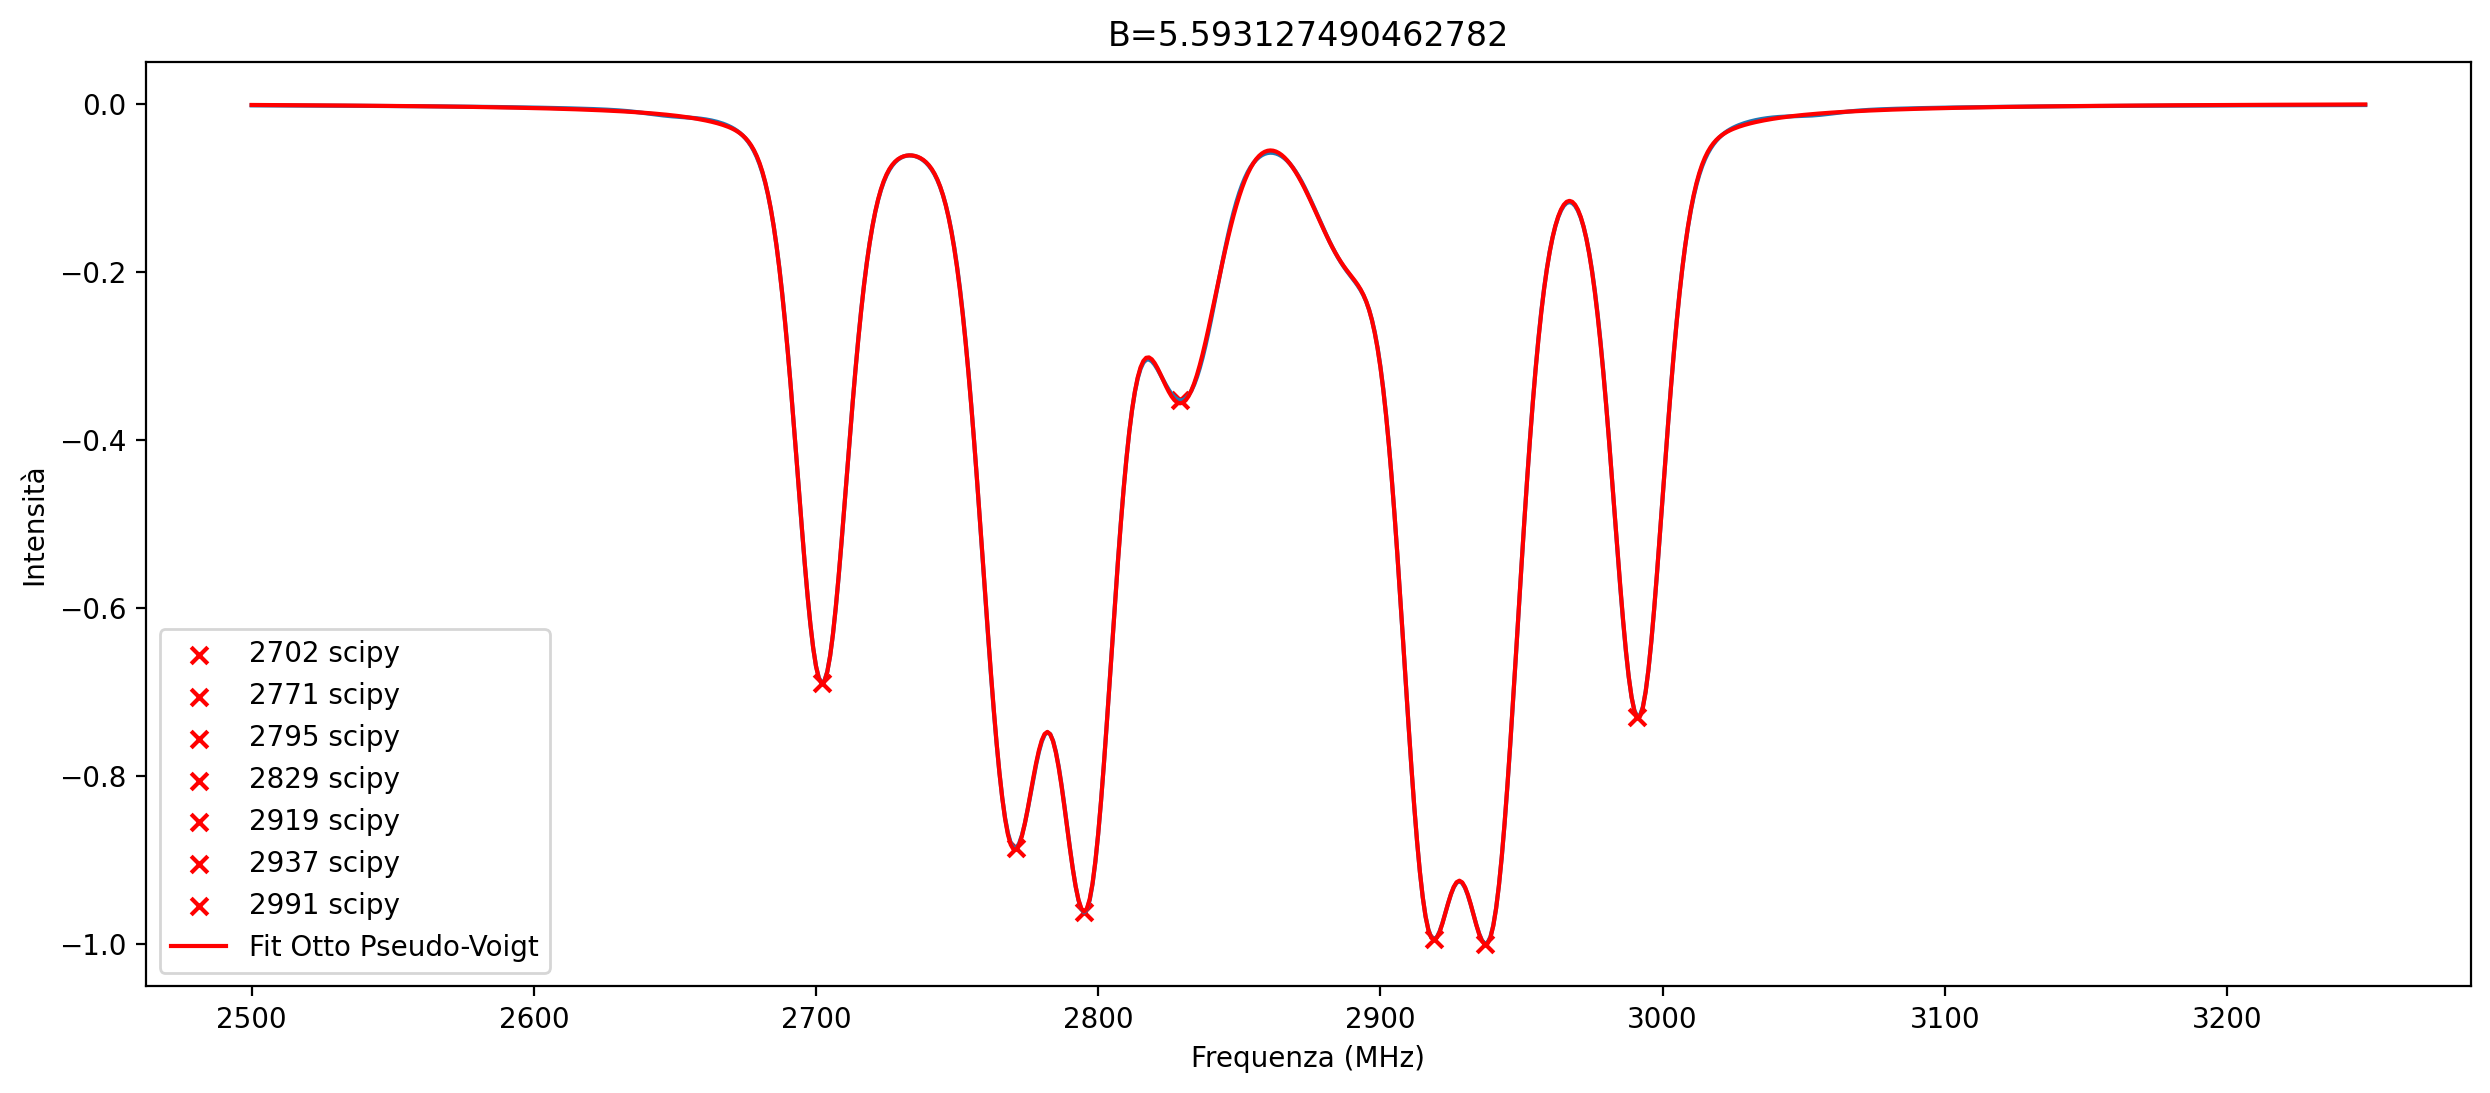

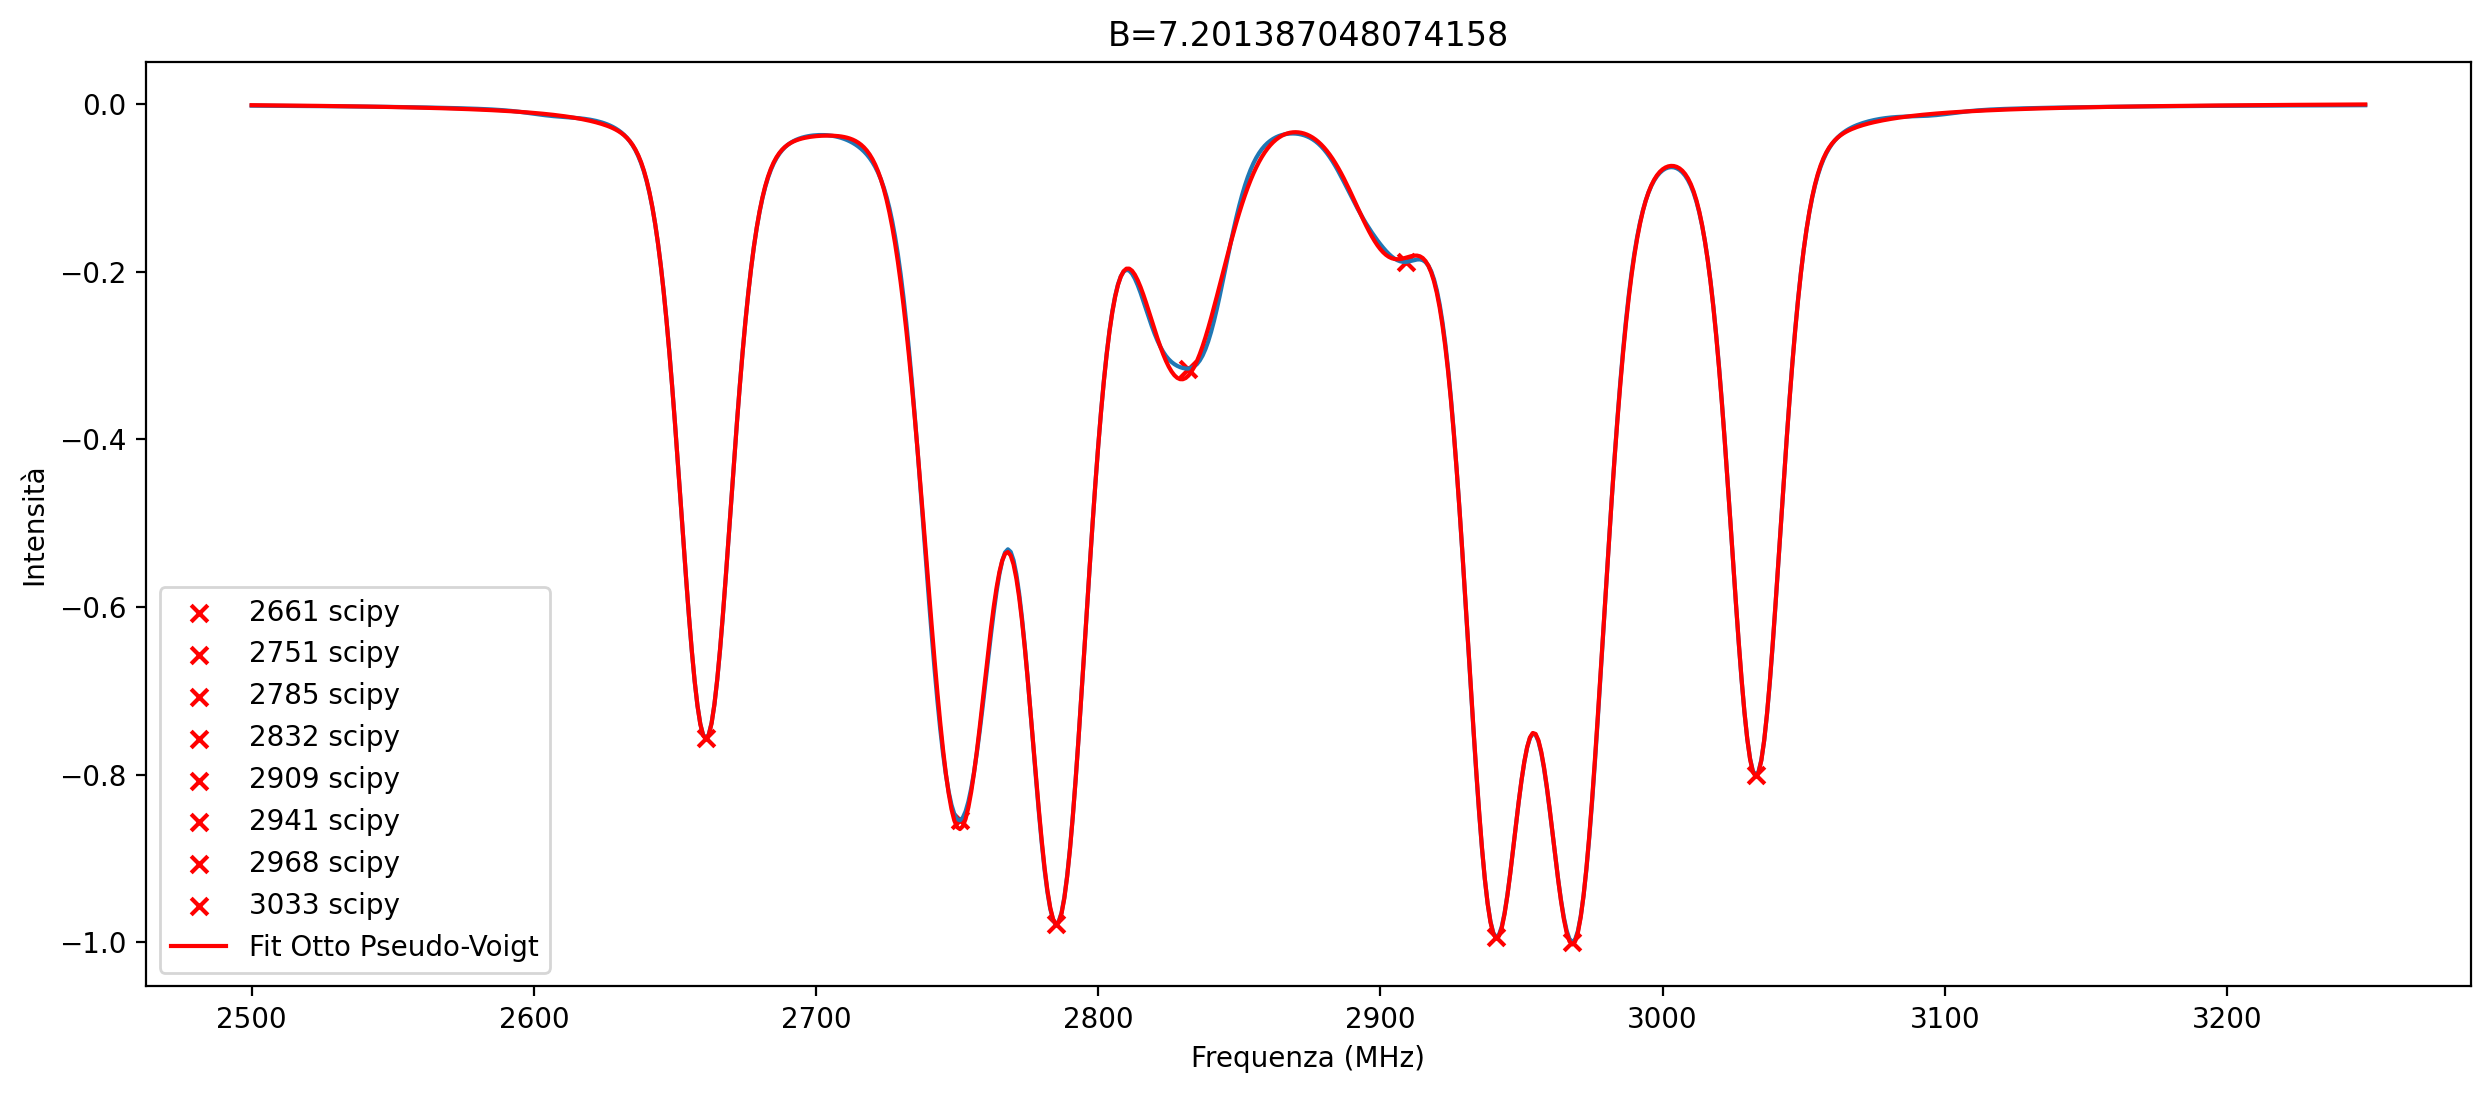

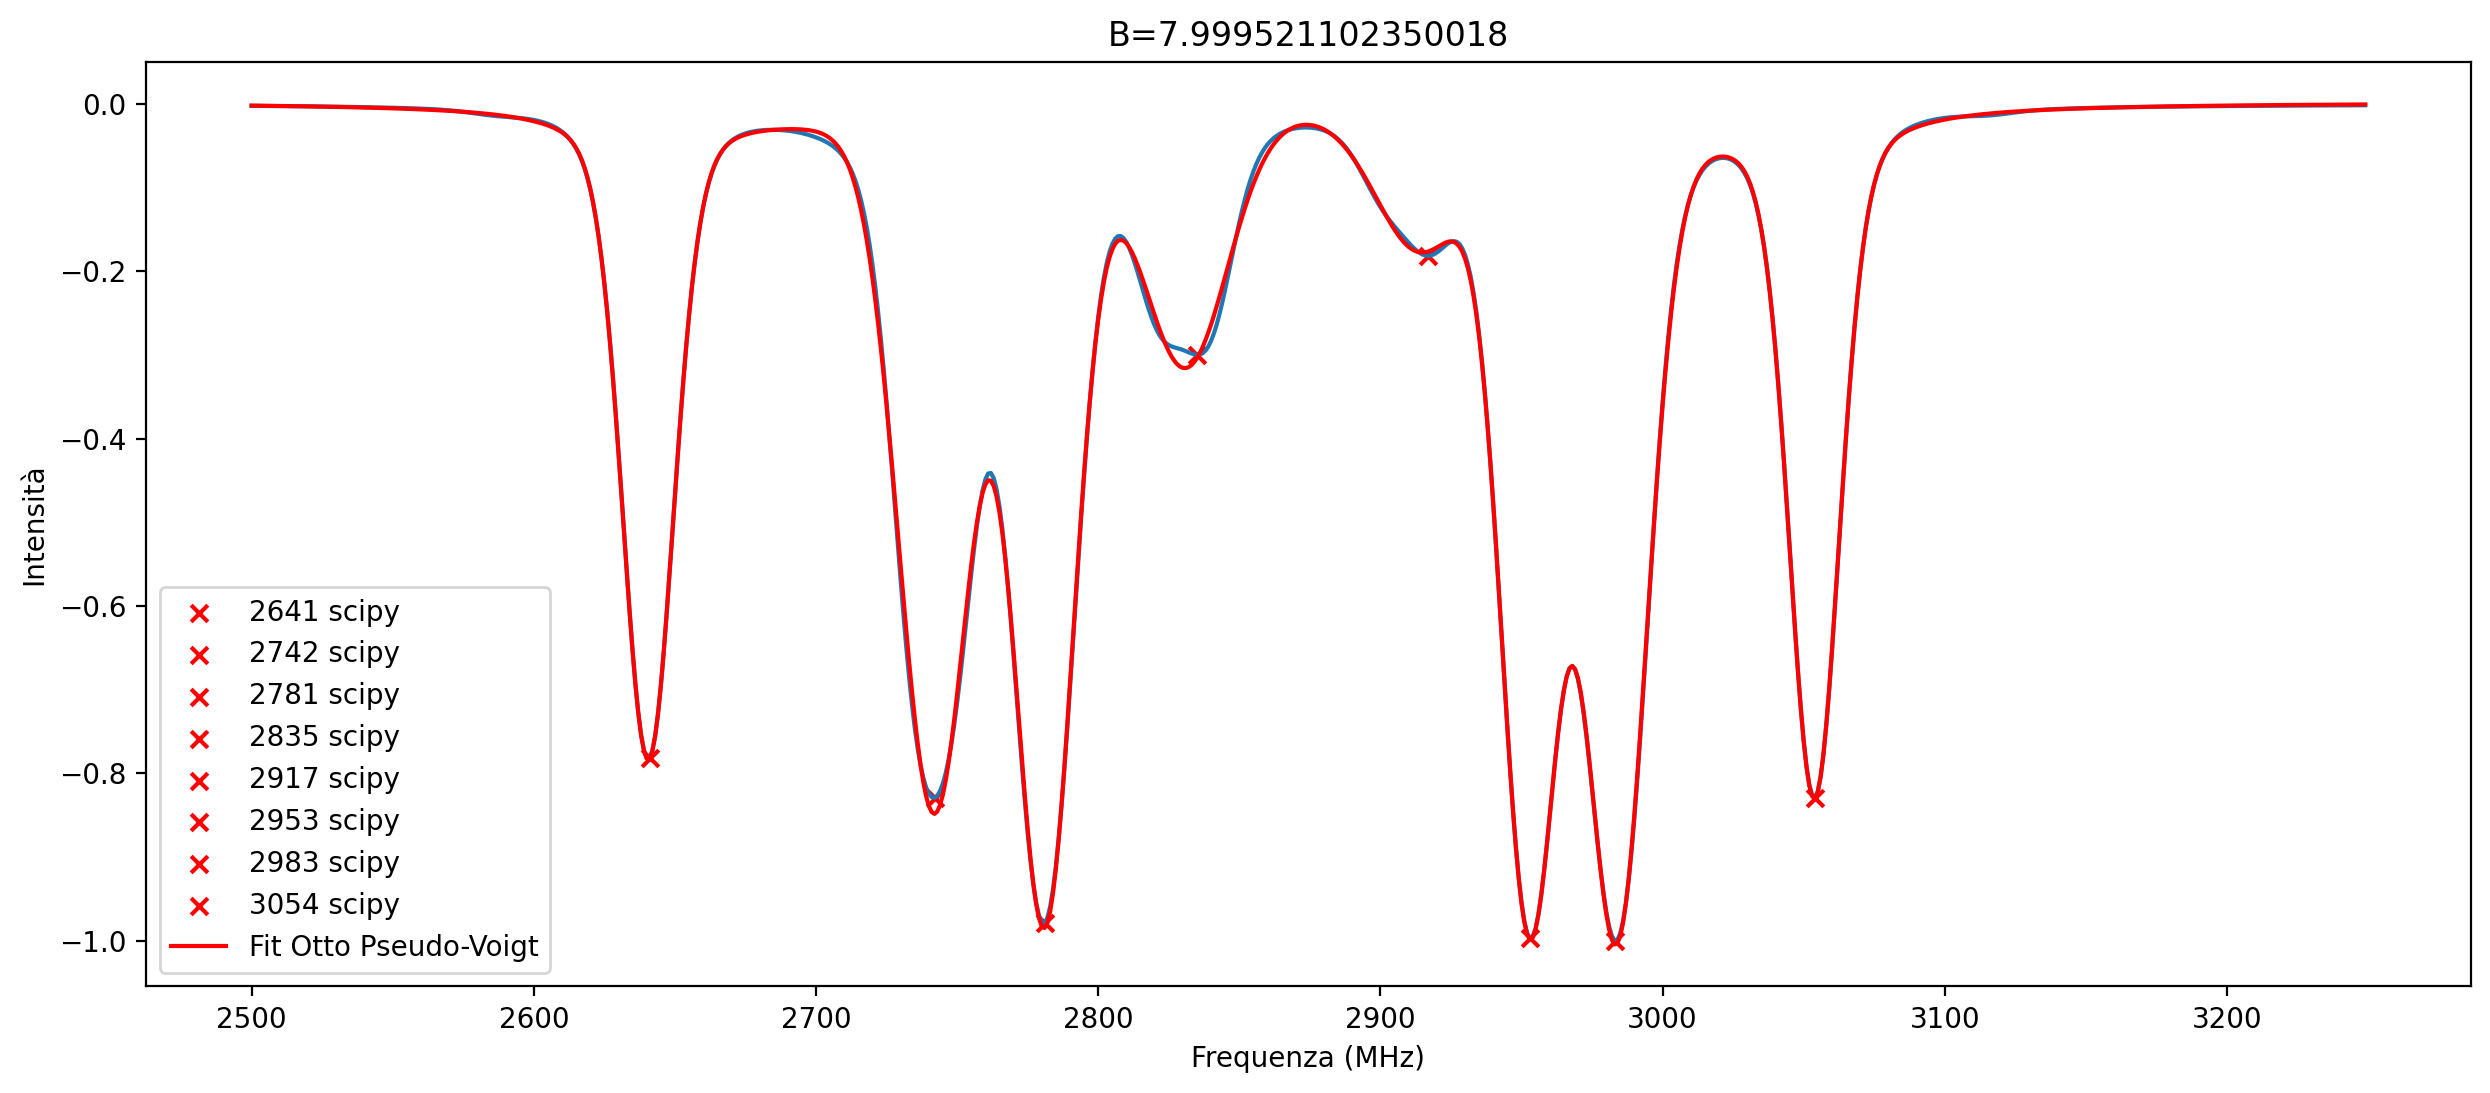

In [11]:
for k in k_list:    
    plt.figure(figsize=(15, 6), dpi=200)
    plt.plot(x_axis, s[k])
    for pos in posizioni_totali[k]:
        h = info_totale[k]['peak_heights'][np.where(posizioni_totali[k] == pos)[0][0]]
        plt.scatter(pos, -h, color='red', marker='x', label=f'{pos} scipy')  # Evidenziamo i picchi
    plt.plot(f, -otto_pseudo_voigt(f, ampiezze_fit[k], posizioni_fit[k], gamma_fit[k], sigma_fit[k], eta_fit[k], y0_fit[k]), color='red', label='Fit Otto Pseudo-Voigt')  # Plot del fit
    plt.title(f"B={B[k]}")
    plt.xlabel('Frequenza (MHz)')
    plt.ylabel('Intensità')
    plt.legend()
plt.show()

In [12]:
for i in range(8): print(f"{posizioni_fit[0][i]:.1f}")

2831.7
2850.6
2836.9
2844.3
2839.7
2857.8
2835.4
2859.3


In [13]:
for i in range(8): print(f"{posizioni_fit[-1][i]:.1f}")

2640.5
2741.7
2780.9
2831.1
2914.0
2952.7
2983.6
3053.8


In [14]:
(np.max(posizioni_totali[k]) + np.min(posizioni_totali[k])) / 2

2847.5

## Produzione delle etichette vere e proprie

bisogna ripetere l'operazione di prima per tutti gli spettri

In [15]:
'''import numpy as np

posizioni_fit_tot = np.zeros((N_spettri, 8))

for i in range(N_spettri):
    
    # 1. Esegui il fit (ho cambiato il nome del file finale in 'file_out' nel blocco sotto)
    a, posizioni_fit_tot[i], g, sigma, e, y0 = fit_otto_pseudo_voigt(
            f,  # La tua variabile 'f' originale rimane intatta
            s[i],
            info_totale[i]['peak_heights'],
            posizioni_totali[i],
            info_totale[i]['widths'],
            info_totale[i]['widths']*0.5,
            np.full_like(info_totale[i]['widths'], 0.5)
        )
    
    # 2. Salva la riga corrente ad ogni iterazione
    # Usiamo 'ab' (append binary) perché np.savetxt scrive in modalità binaria su Python 3
    with open('../data/10k/posizioni_fit_otto_pseudo_voigt.txt', 'ab') as file_out:
        # np.savetxt si aspetta un array 2D per scrivere una riga correttamente, 
        # quindi usiamo [posizioni_fit_tot[i]] (notazione con le parentesi quadre)
        np.savetxt(file_out, [posizioni_fit_tot[i]], delimiter=',', fmt='%.6f')'''

"import numpy as np\n\nposizioni_fit_tot = np.zeros((N_spettri, 8))\n\nfor i in range(N_spettri):\n\n    # 1. Esegui il fit (ho cambiato il nome del file finale in 'file_out' nel blocco sotto)\n    a, posizioni_fit_tot[i], g, sigma, e, y0 = fit_otto_pseudo_voigt(\n            f,  # La tua variabile 'f' originale rimane intatta\n            s[i],\n            info_totale[i]['peak_heights'],\n            posizioni_totali[i],\n            info_totale[i]['widths'],\n            info_totale[i]['widths']*0.5,\n            np.full_like(info_totale[i]['widths'], 0.5)\n        )\n\n    # 2. Salva la riga corrente ad ogni iterazione\n    # Usiamo 'ab' (append binary) perché np.savetxt scrive in modalità binaria su Python 3\n    with open('../data/10k/posizioni_fit_otto_pseudo_voigt.txt', 'ab') as file_out:\n        # np.savetxt si aspetta un array 2D per scrivere una riga correttamente, \n        # quindi usiamo [posizioni_fit_tot[i]] (notazione con le parentesi quadre)\n        np.savetxt(file_

In [16]:
import os
# 1. DISATTIVA LA PARALLELIZZAZIONE AUTOMATICA SOTTO IL COFANO
# Questo dice ad Apple Accelerate e OpenBLAS di usare un solo thread per operazione
os.environ["VECLIB_MAXIMUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"

import numpy as np
from joblib import Parallel, delayed
from tqdm import tqdm

# Definiamo una funzione per processare il singolo spettro
def esegui_singolo_fit(i, f_asse, spettro_i, info_i, posizioni_i):
    # Esegue il fit (usando la versione corretta senza @njit sopra curve_fit)
    res = fit_otto_pseudo_voigt(
        f_asse,
        spettro_i,
        info_i['peak_heights'],
        posizioni_i,
        info_i['widths'],
        info_i['widths'] * 0.5,
        np.full_like(info_i['widths'], 0.5)
    )
    
    # Estraiamo solo le posizioni (il secondo elemento della tupla restituita)
    posizioni_ottimizzate = res[1] 
    return i, posizioni_ottimizzate

# --- INIZIO DEL LOOP PARALLELO VERO ---
if __name__ == "__main__":
    
    # n_jobs=-2 usa tutti i core tranne uno (così il Mac non si blocca e puoi usarlo)
    risultati = Parallel(n_jobs=-2)(
        delayed(esegui_singolo_fit)(i, f, s[i], info_totale[i], posizioni_totali[i])
        for i in tqdm(range(N_spettri), desc="Fitting in parallelo")
    )
    
    # Riordina i risultati nel tuo array finale e salvali tutti insieme
    posizioni_fit_tot = np.zeros((N_spettri, 8))
    for i, pos_ottimizzate in risultati:
        posizioni_fit_tot[i] = pos_ottimizzate
        
    # Salva il file finale completo
    np.savetxt('../data/10k/posizioni_fit_otto_pseudo_voigt.txt', posizioni_fit_tot, delimiter=',', fmt='%.6f')

Fitting in parallelo: 100%|██████████| 10000/10000 [42:01<00:00,  3.97it/s]


proviamo ad assegnare come etichette le posizioni dei picchi

---

controllo che siano stati assegnatti correttamente e in ordine crescente

In [18]:
labels = np.loadtxt('../data/10k/posizioni_fit_otto_pseudo_voigt.txt', delimiter=',')

In [20]:
l_list = [15, 432, 963, 2345, 4531, 6532, 8675, 9543, 9998]

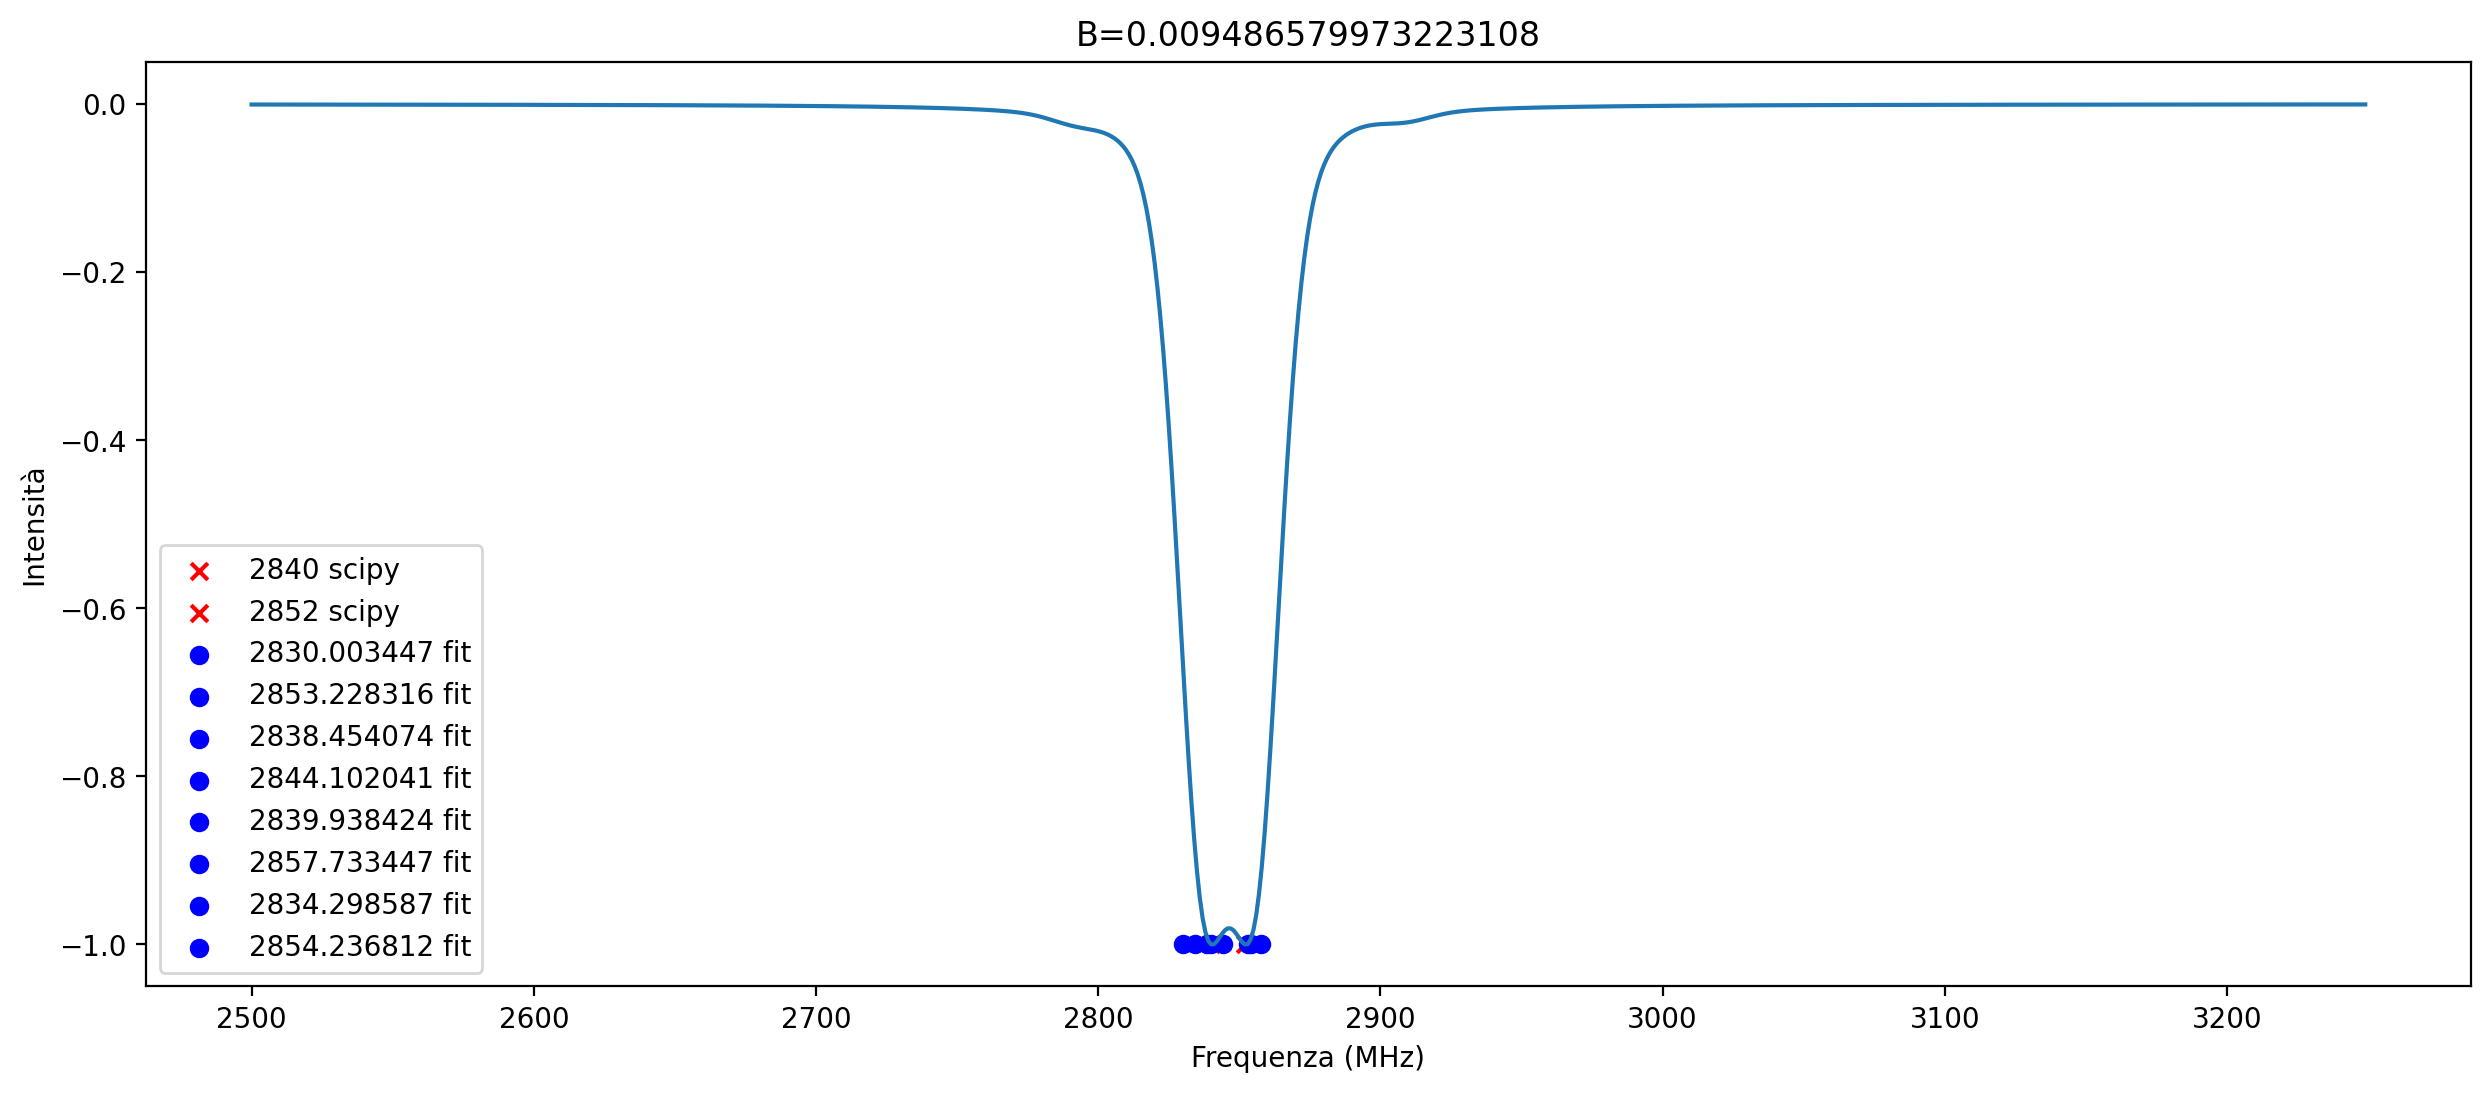

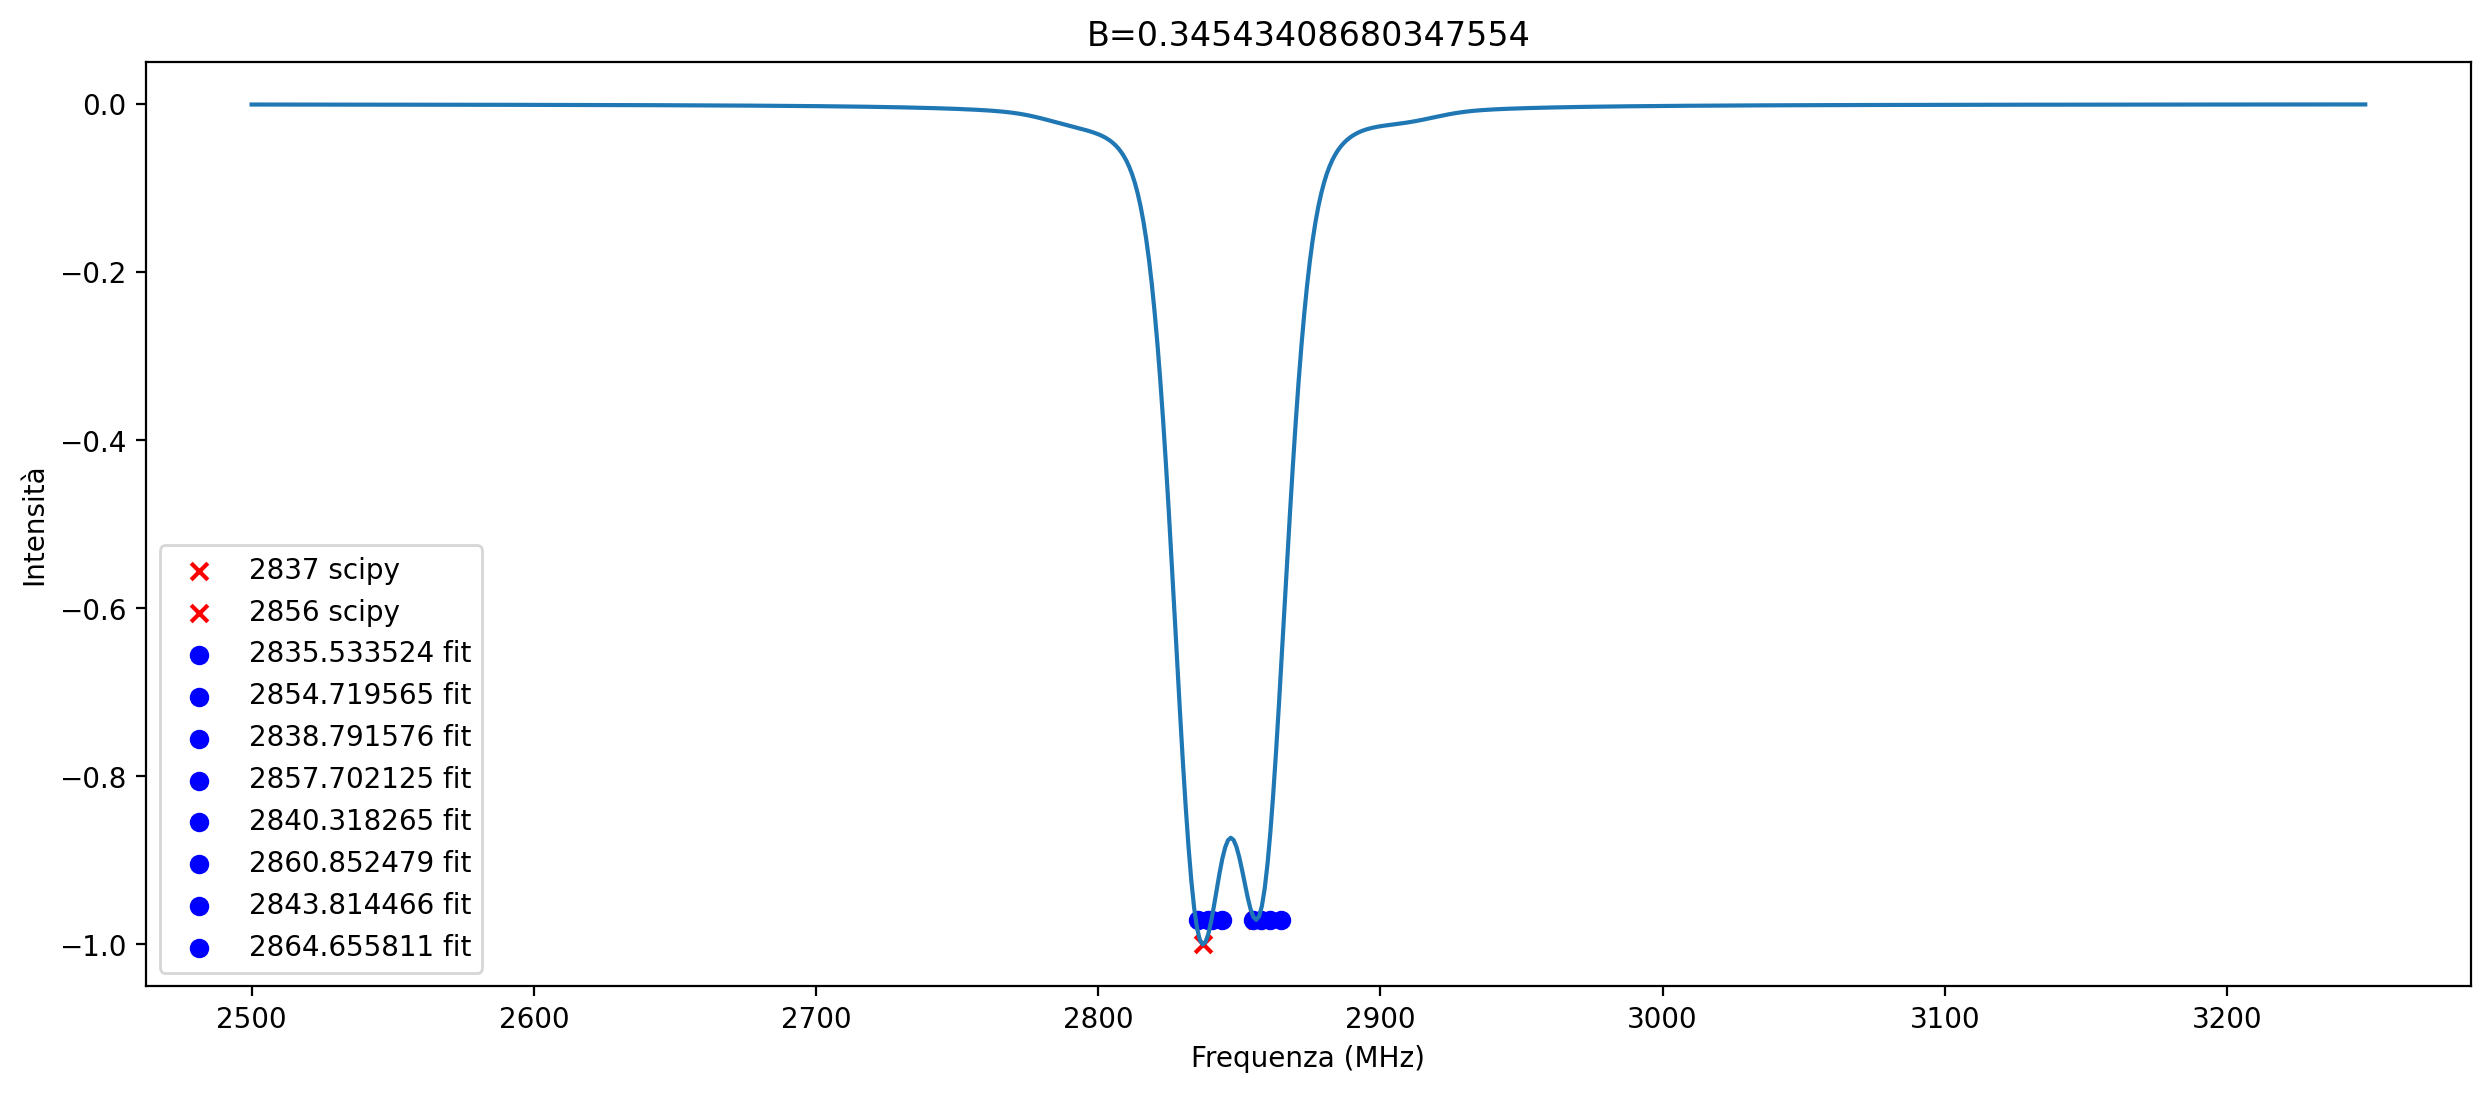

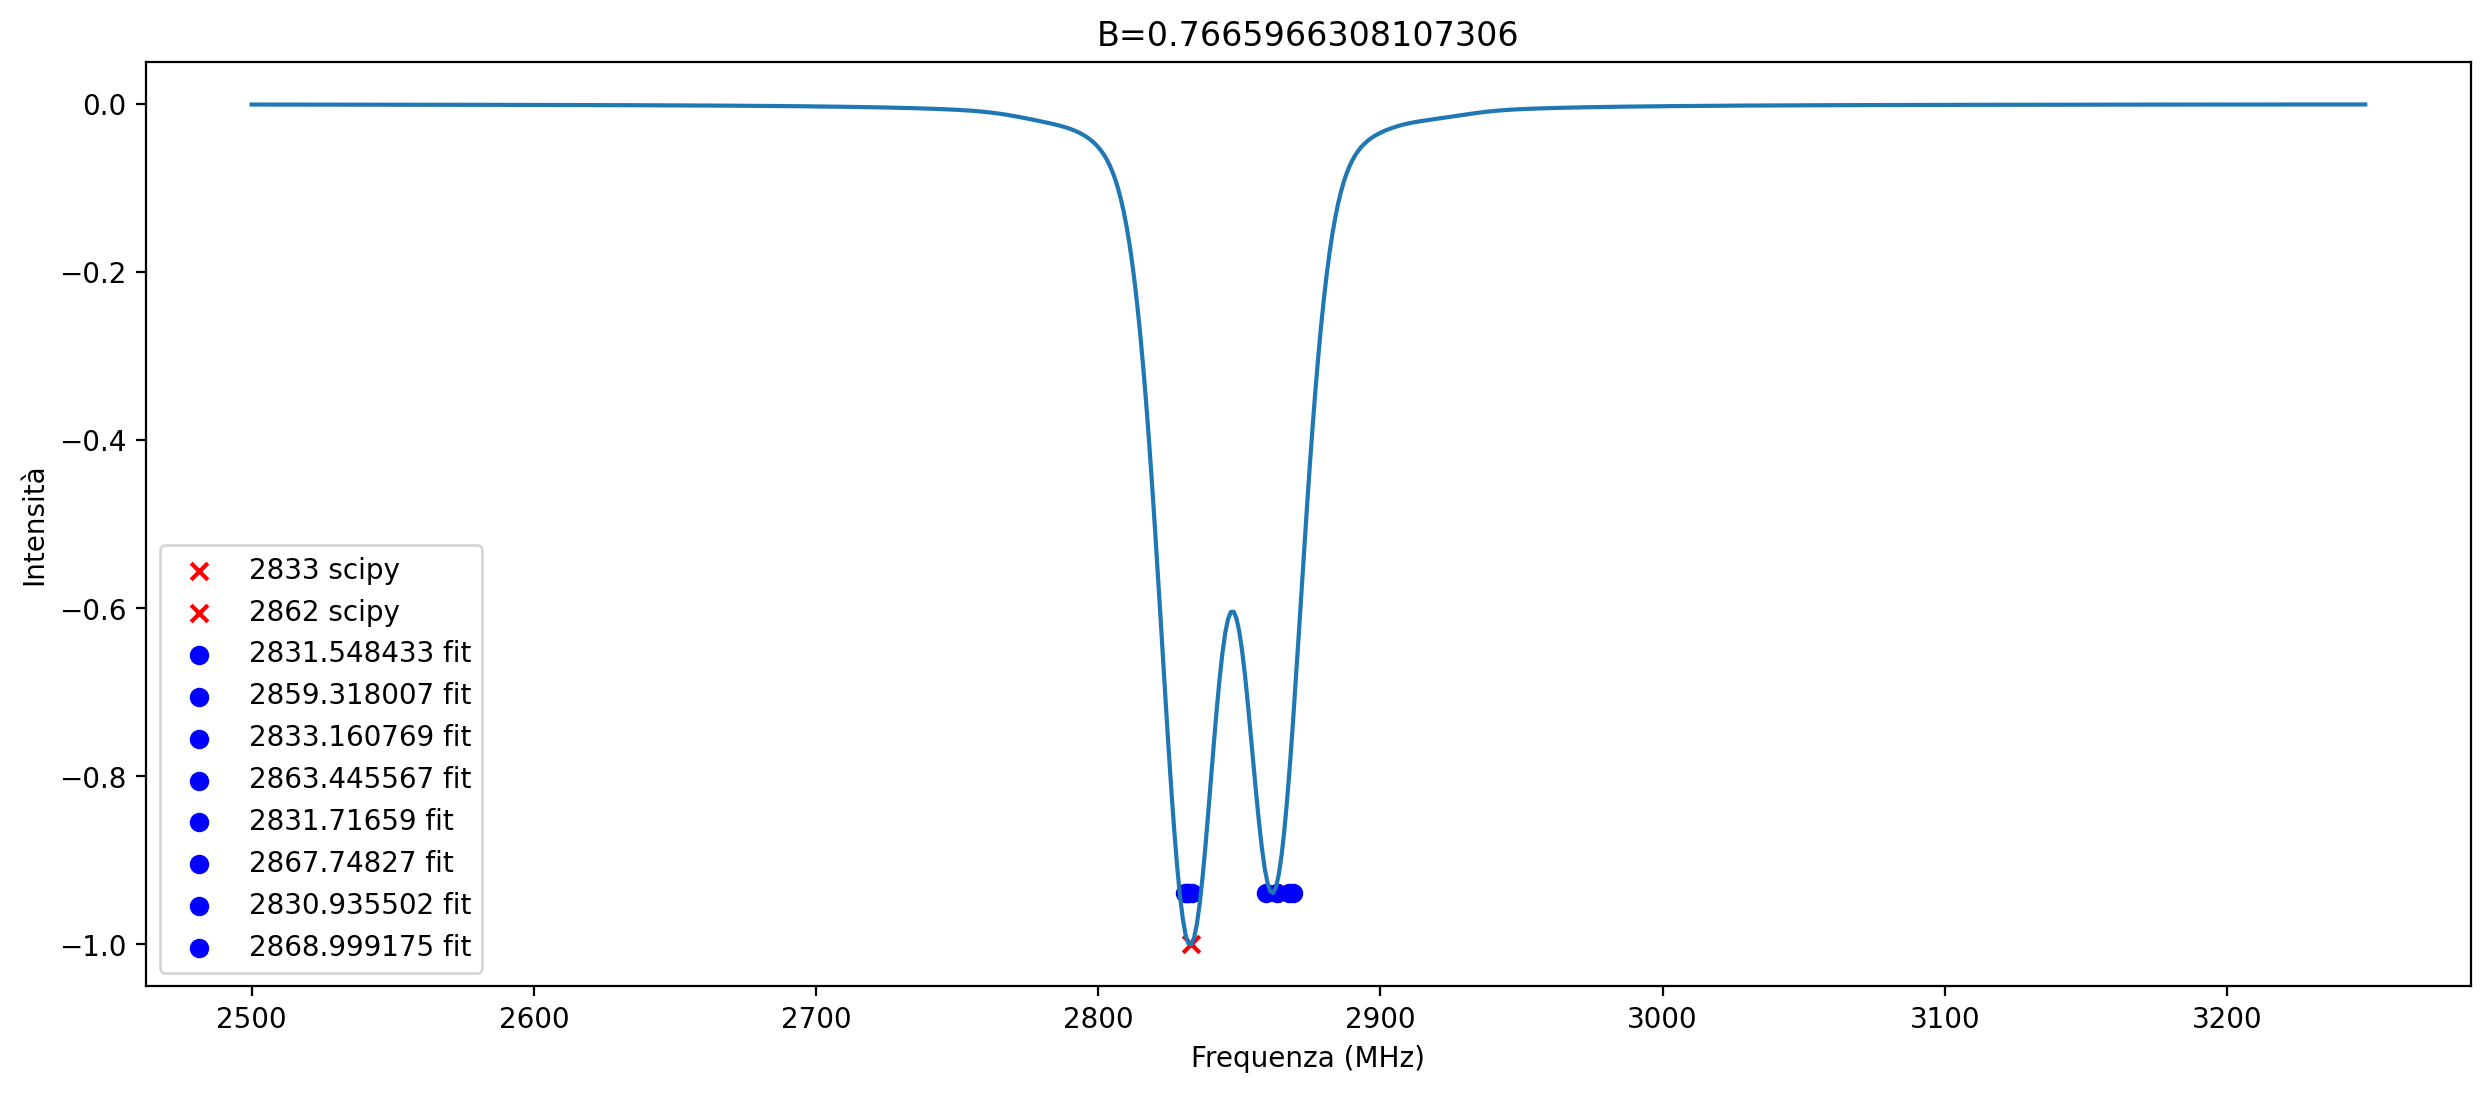

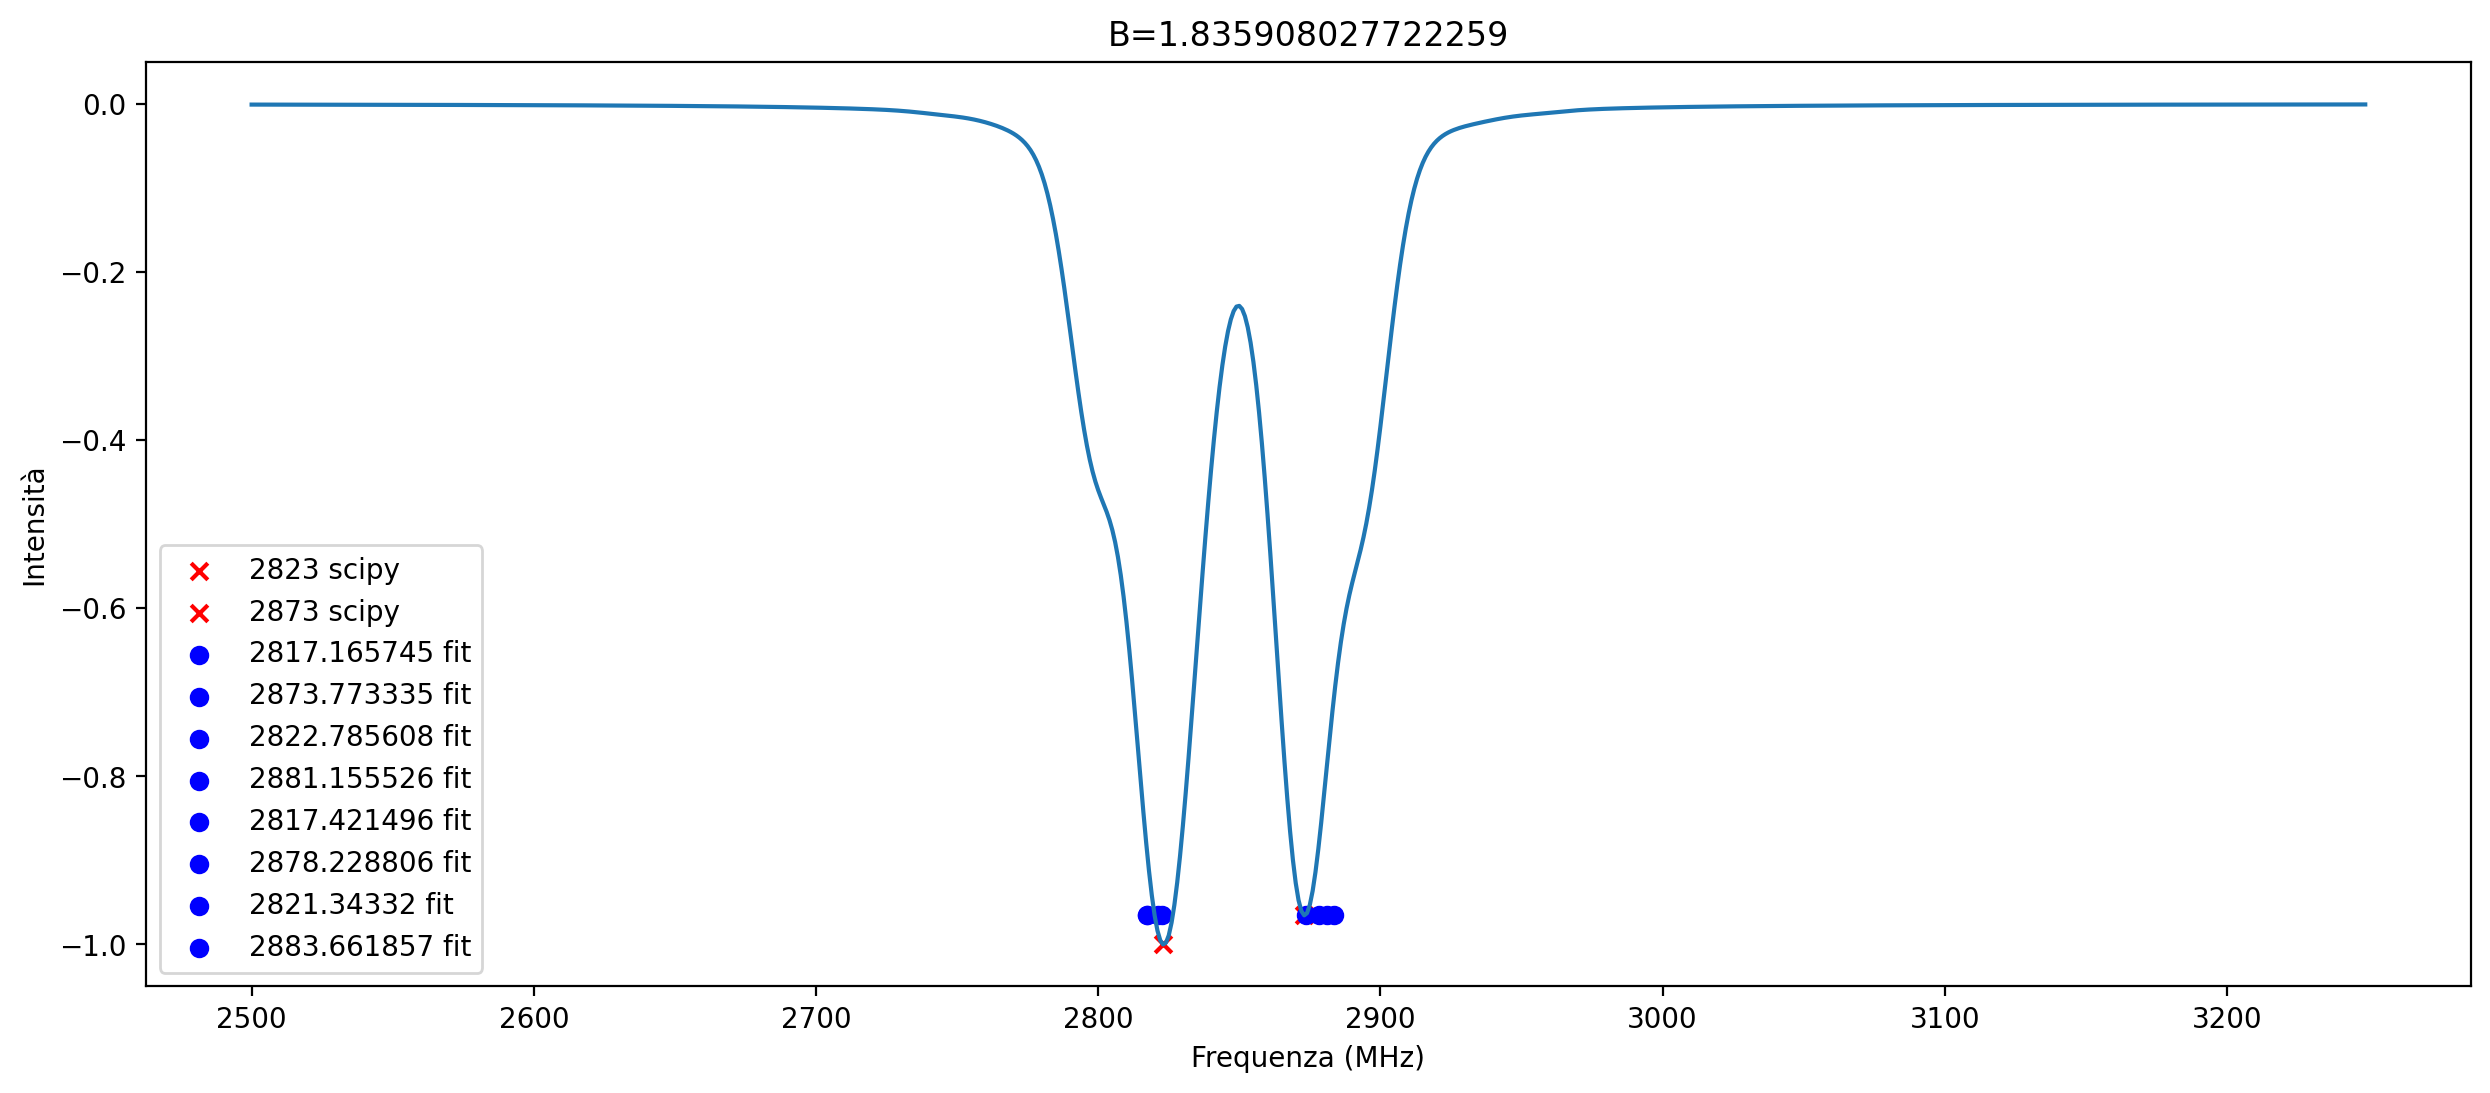

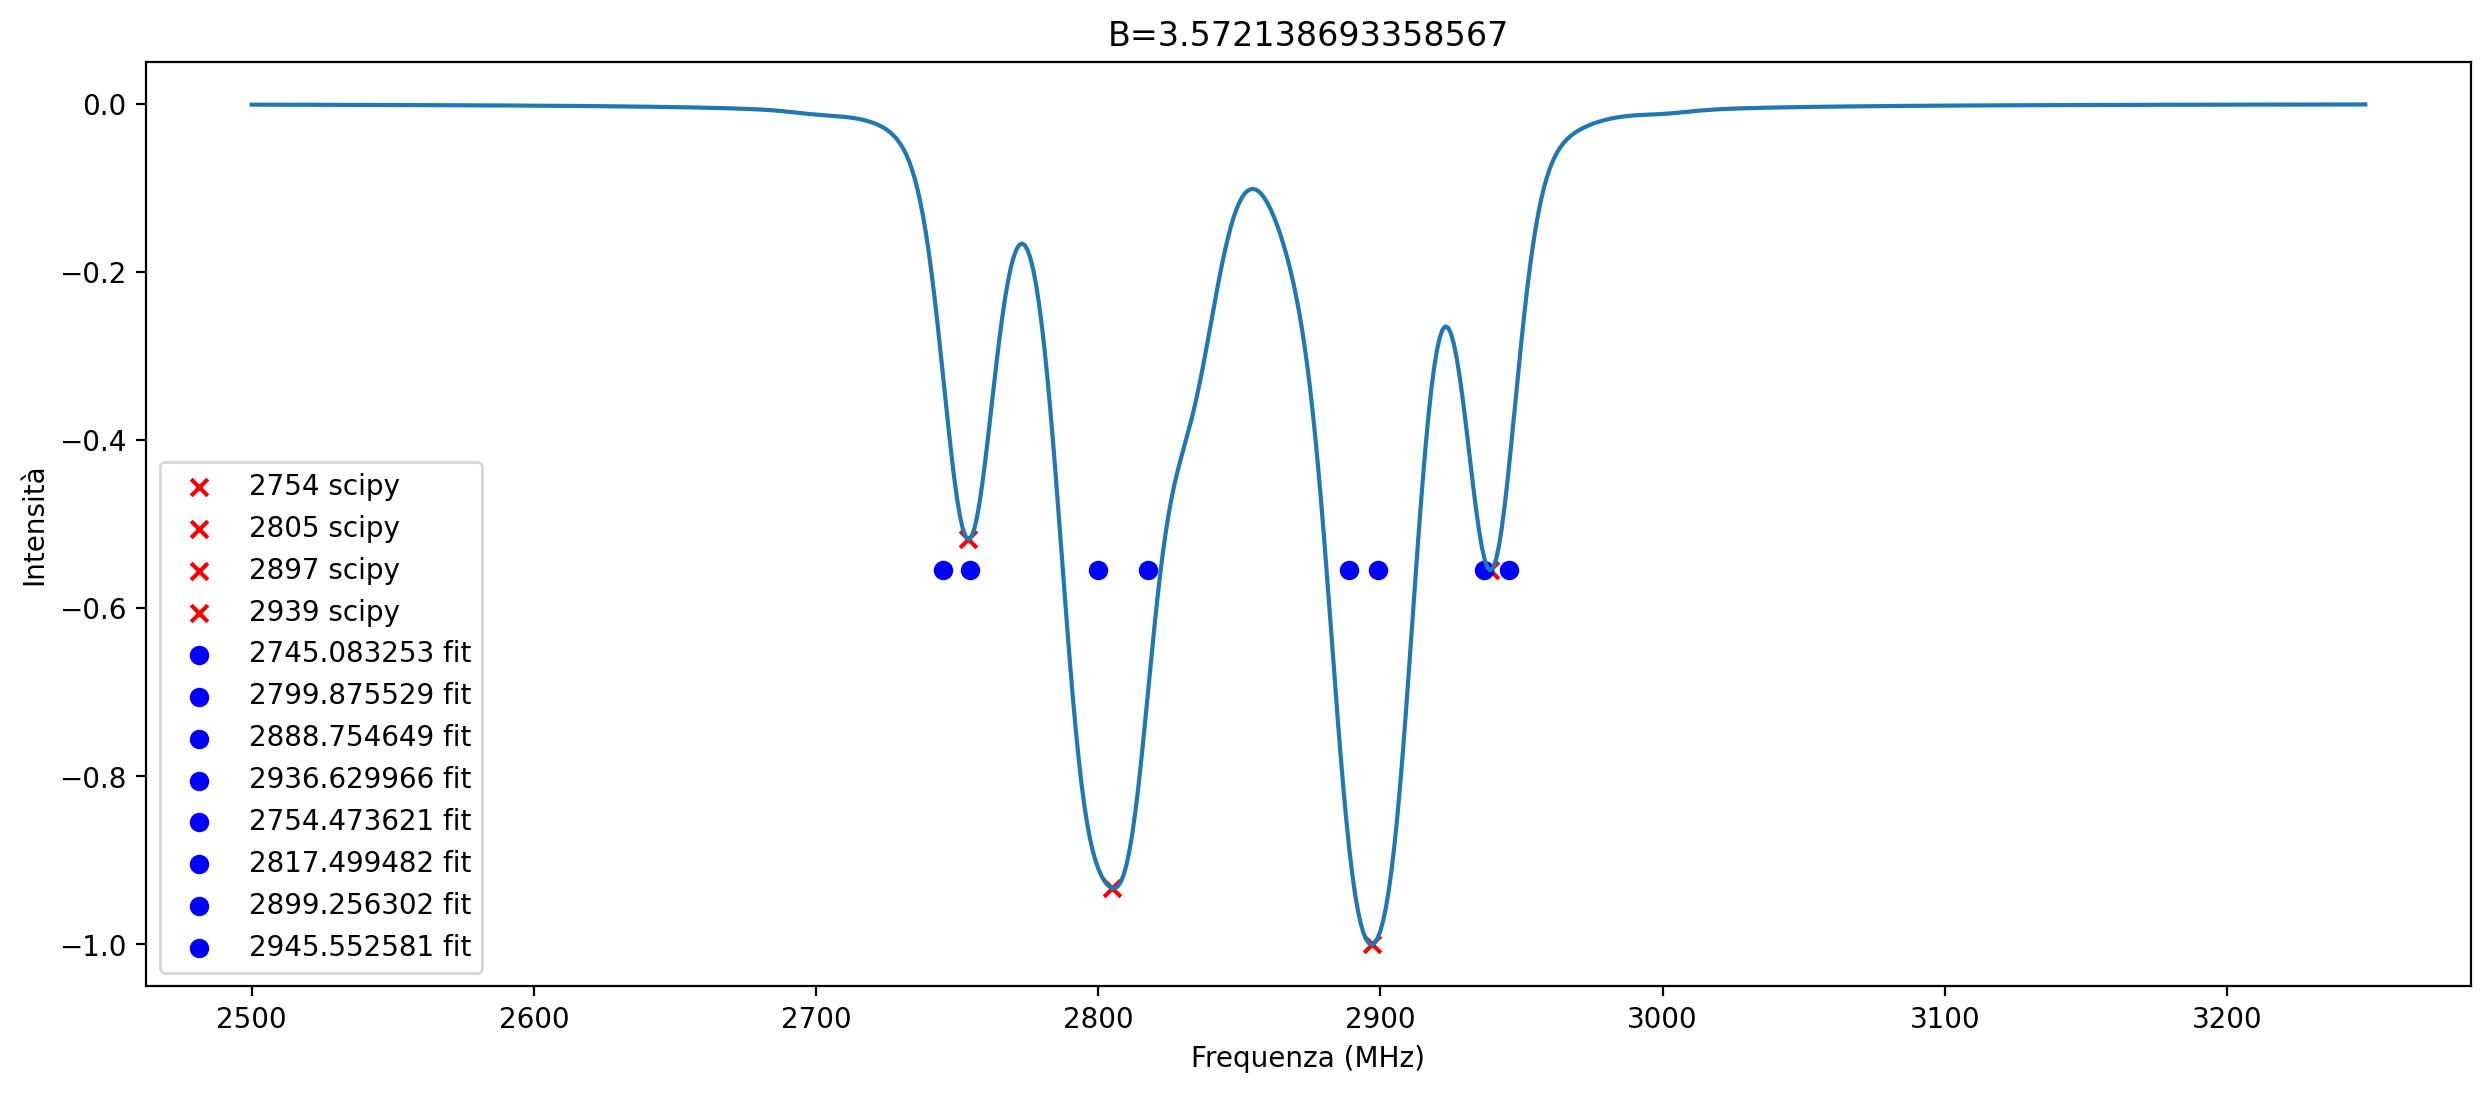

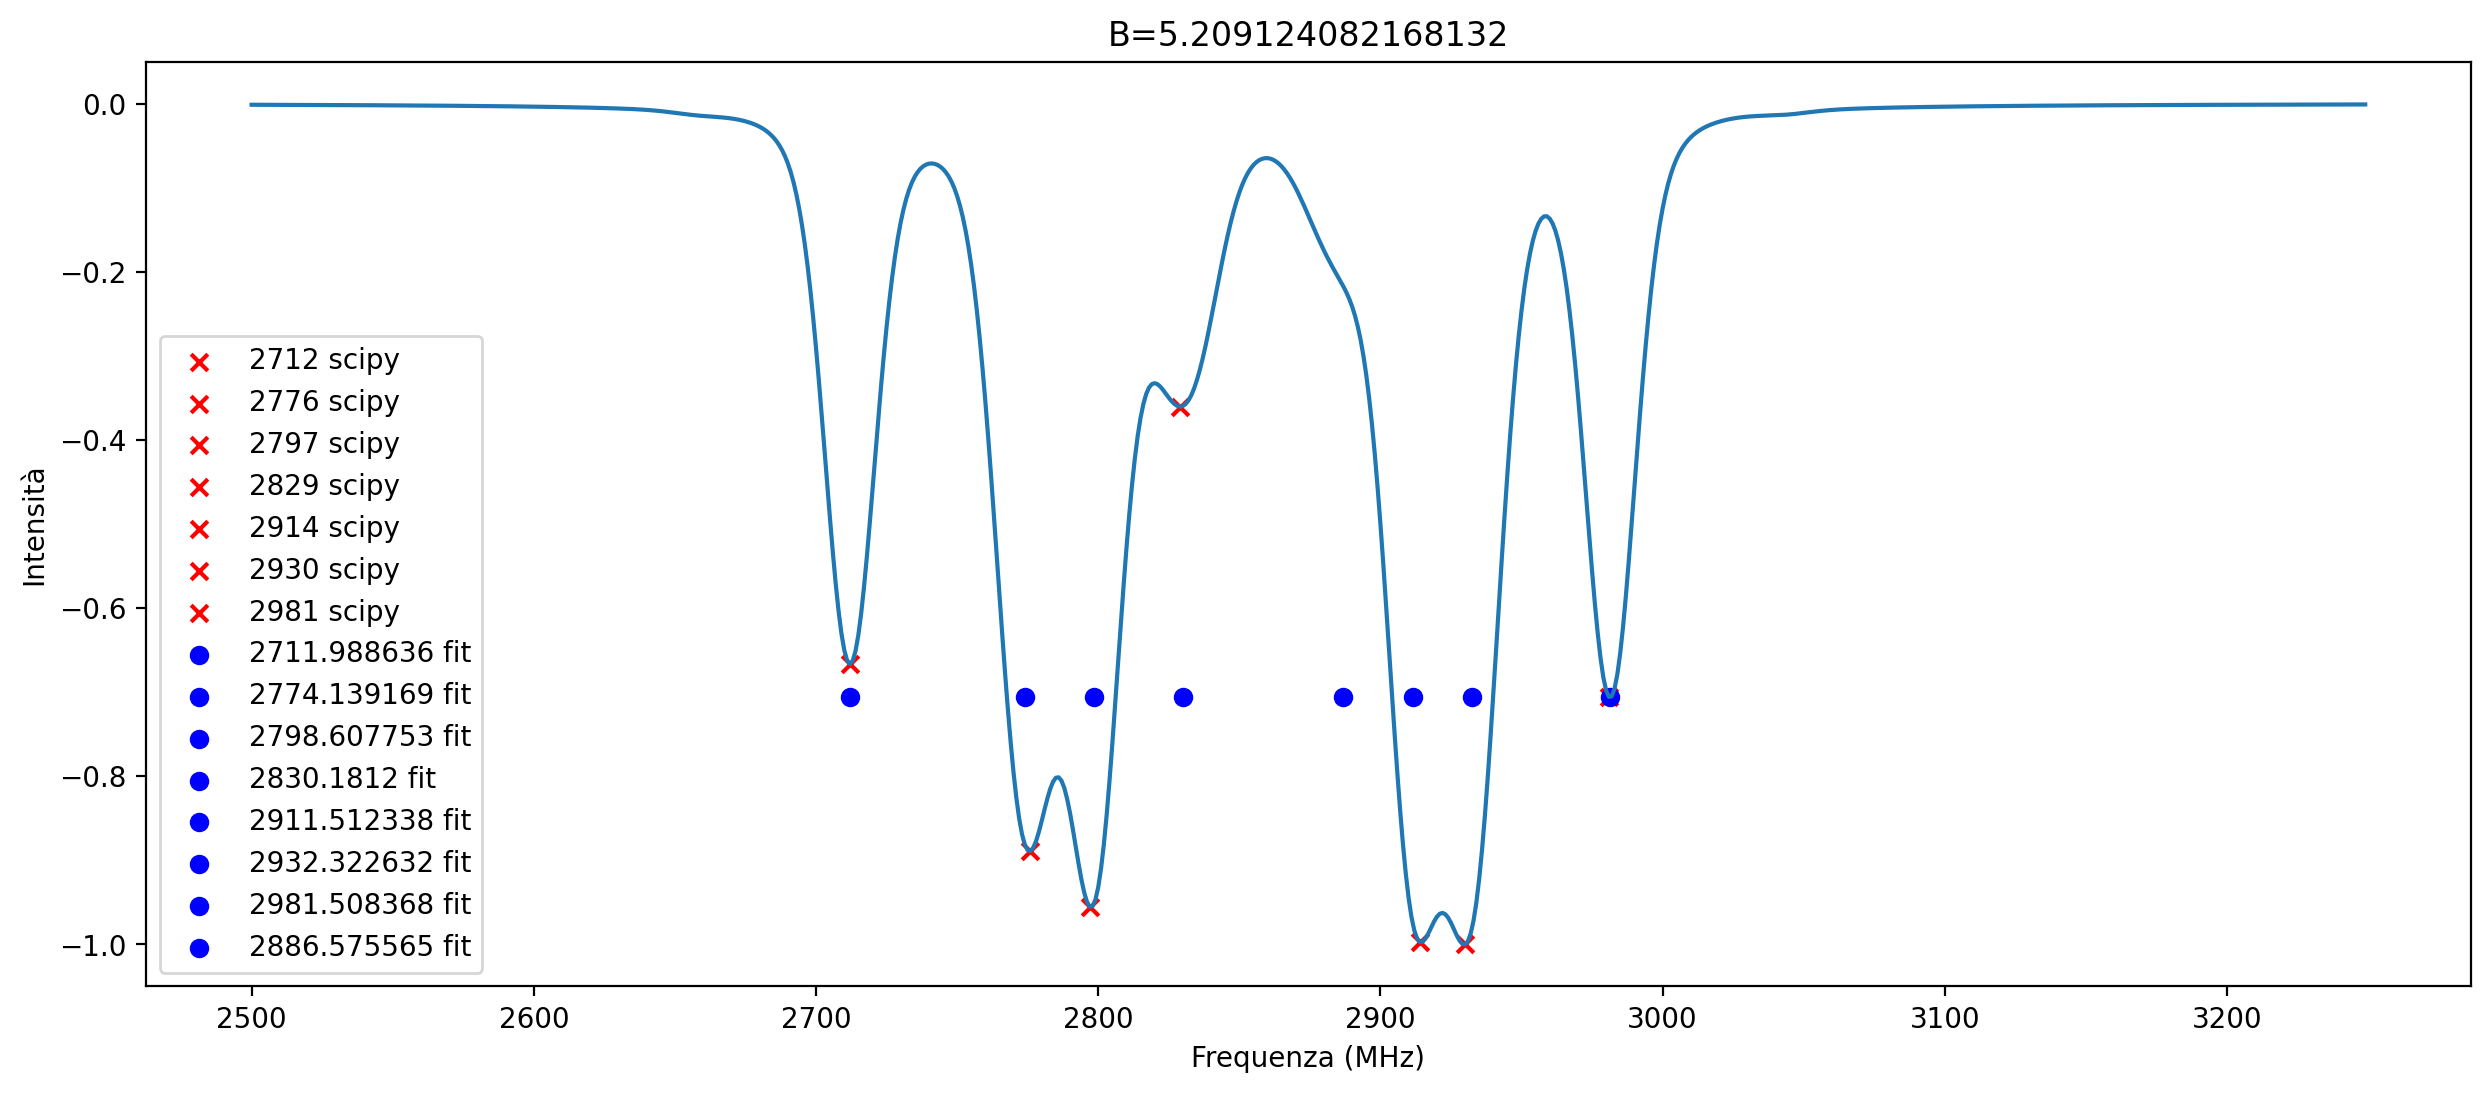

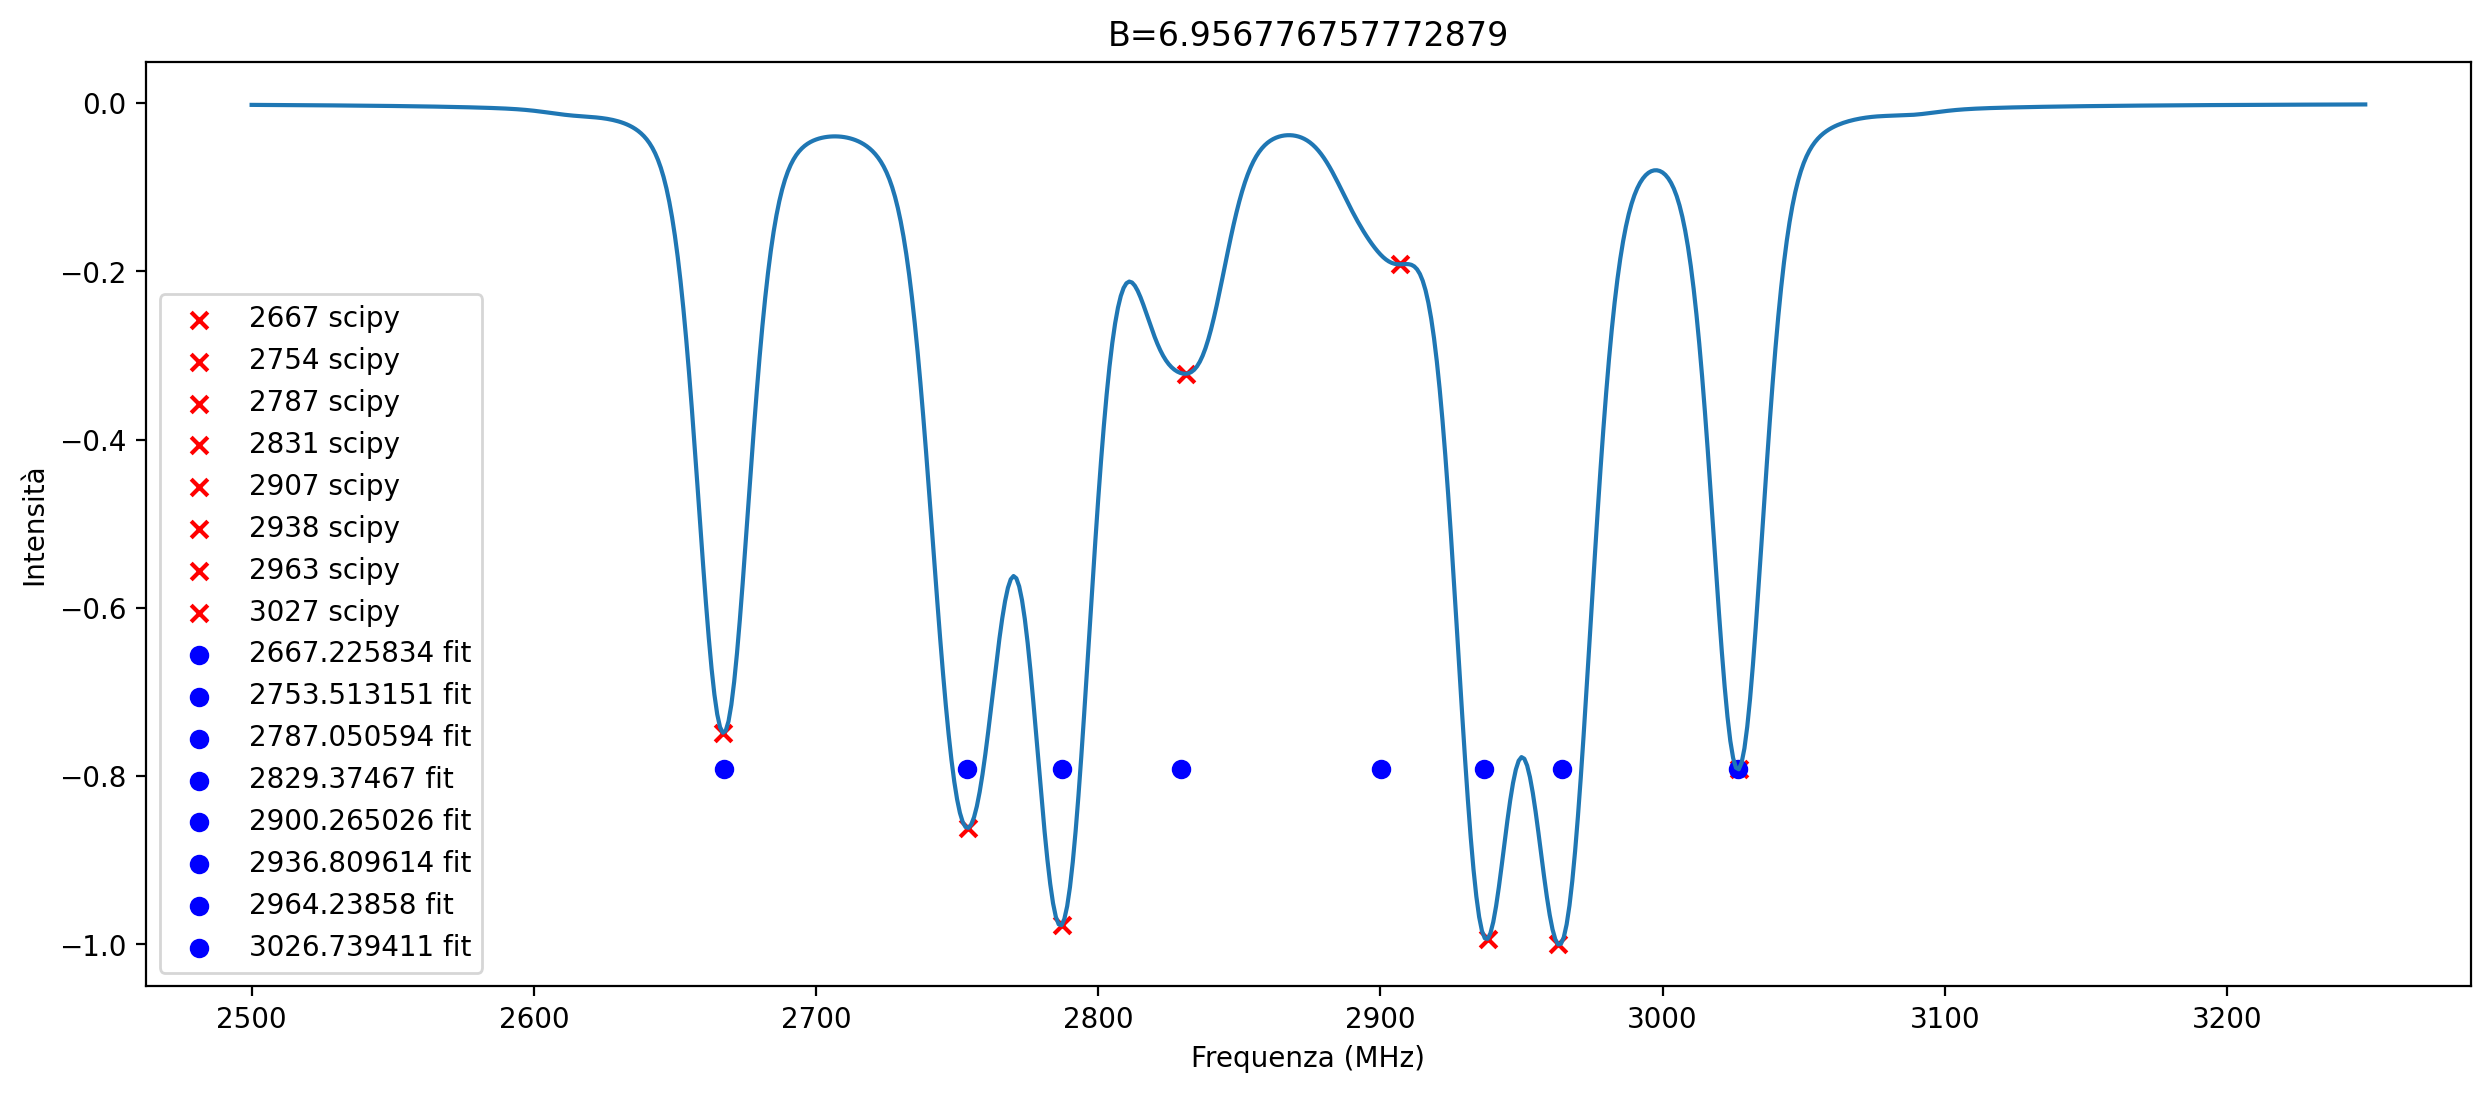

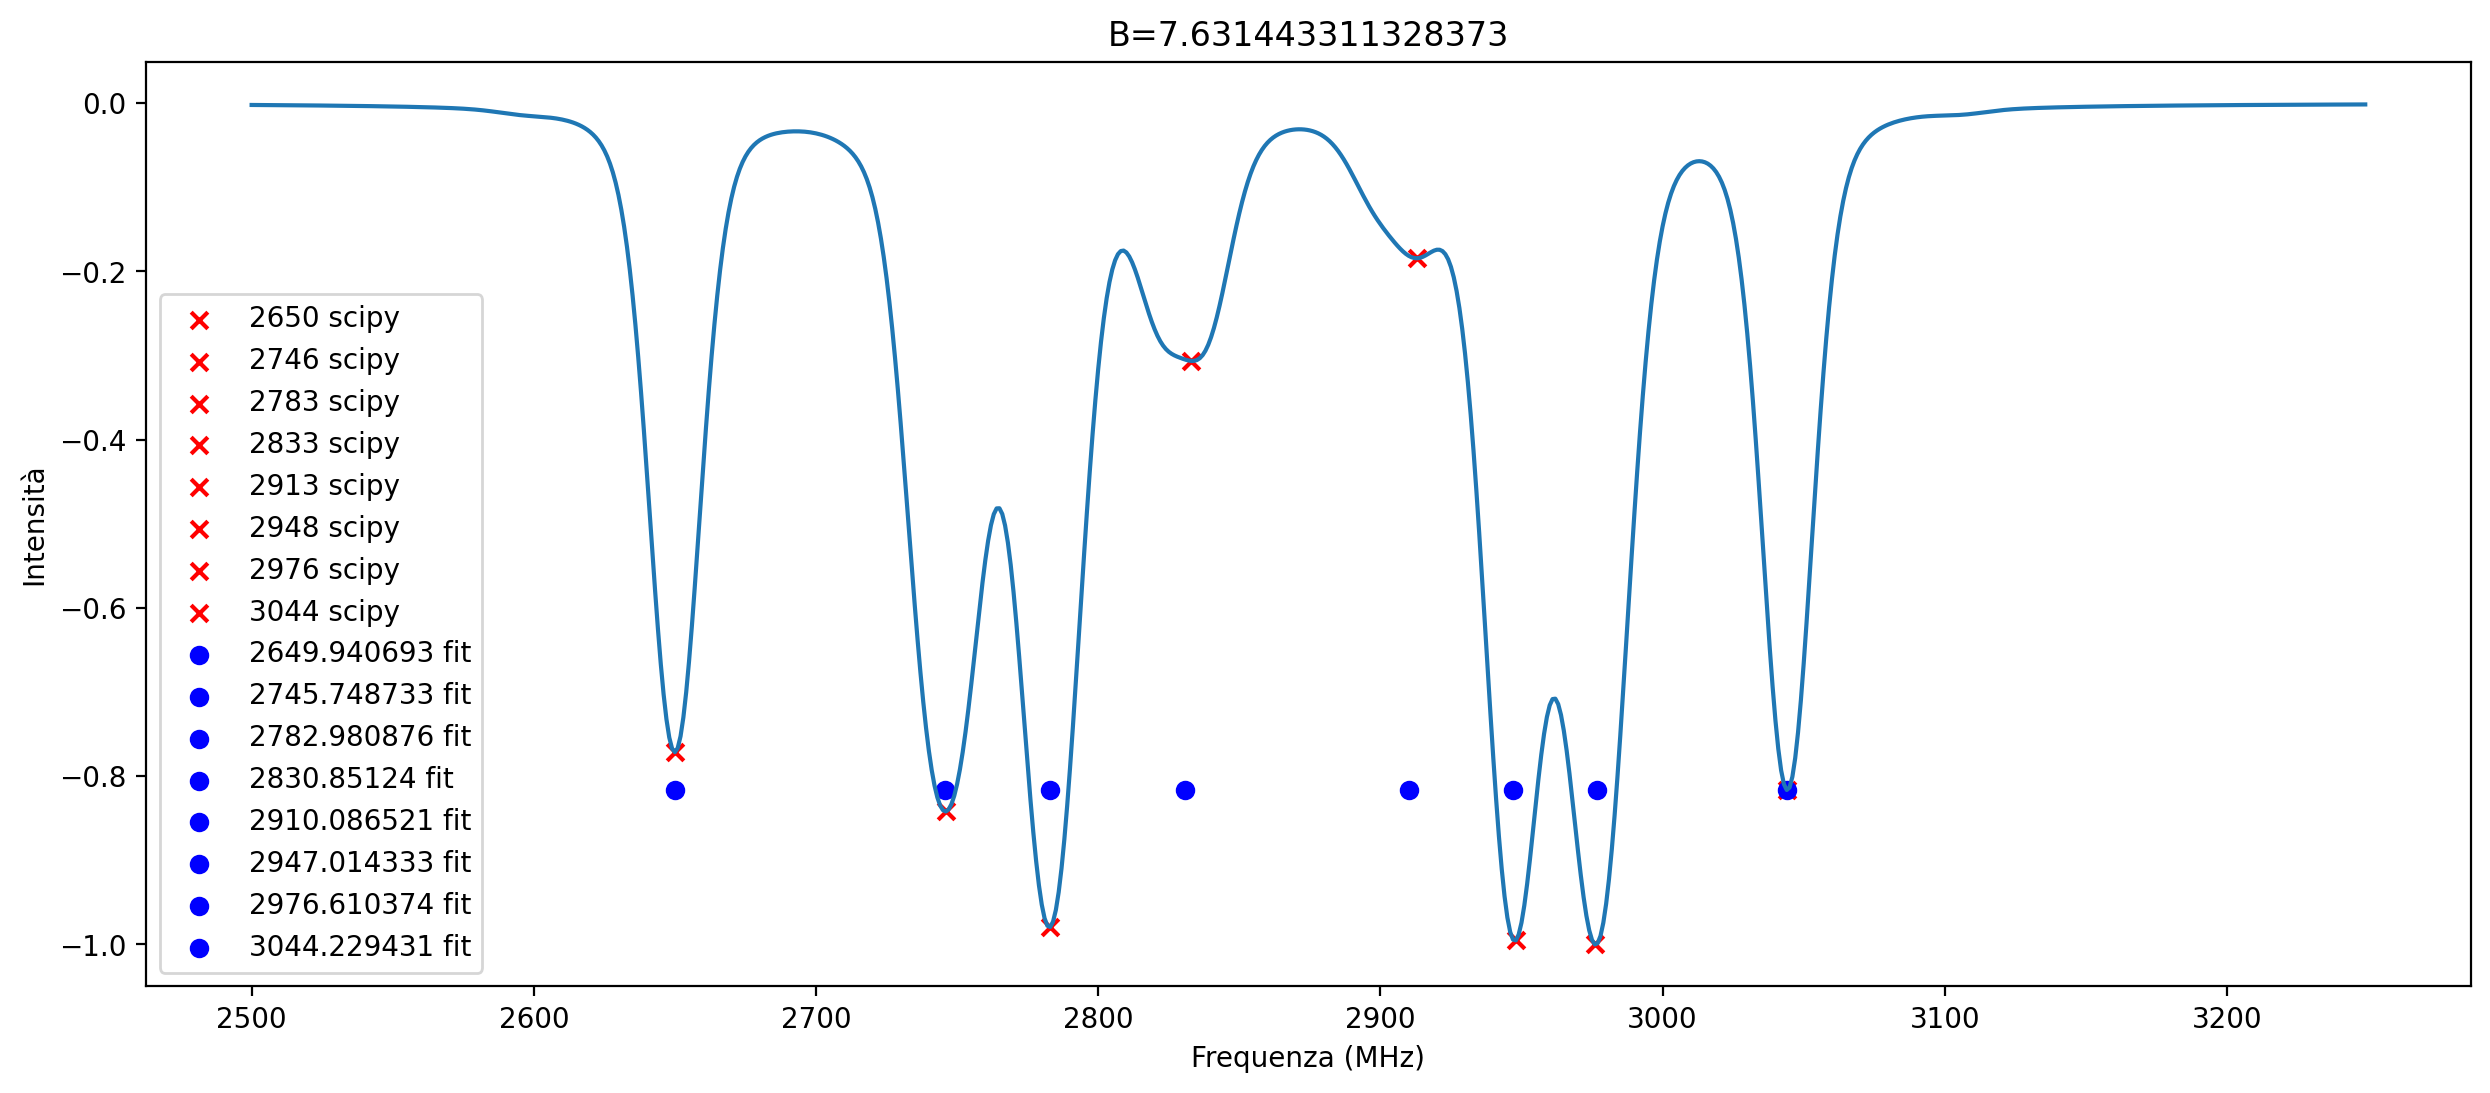

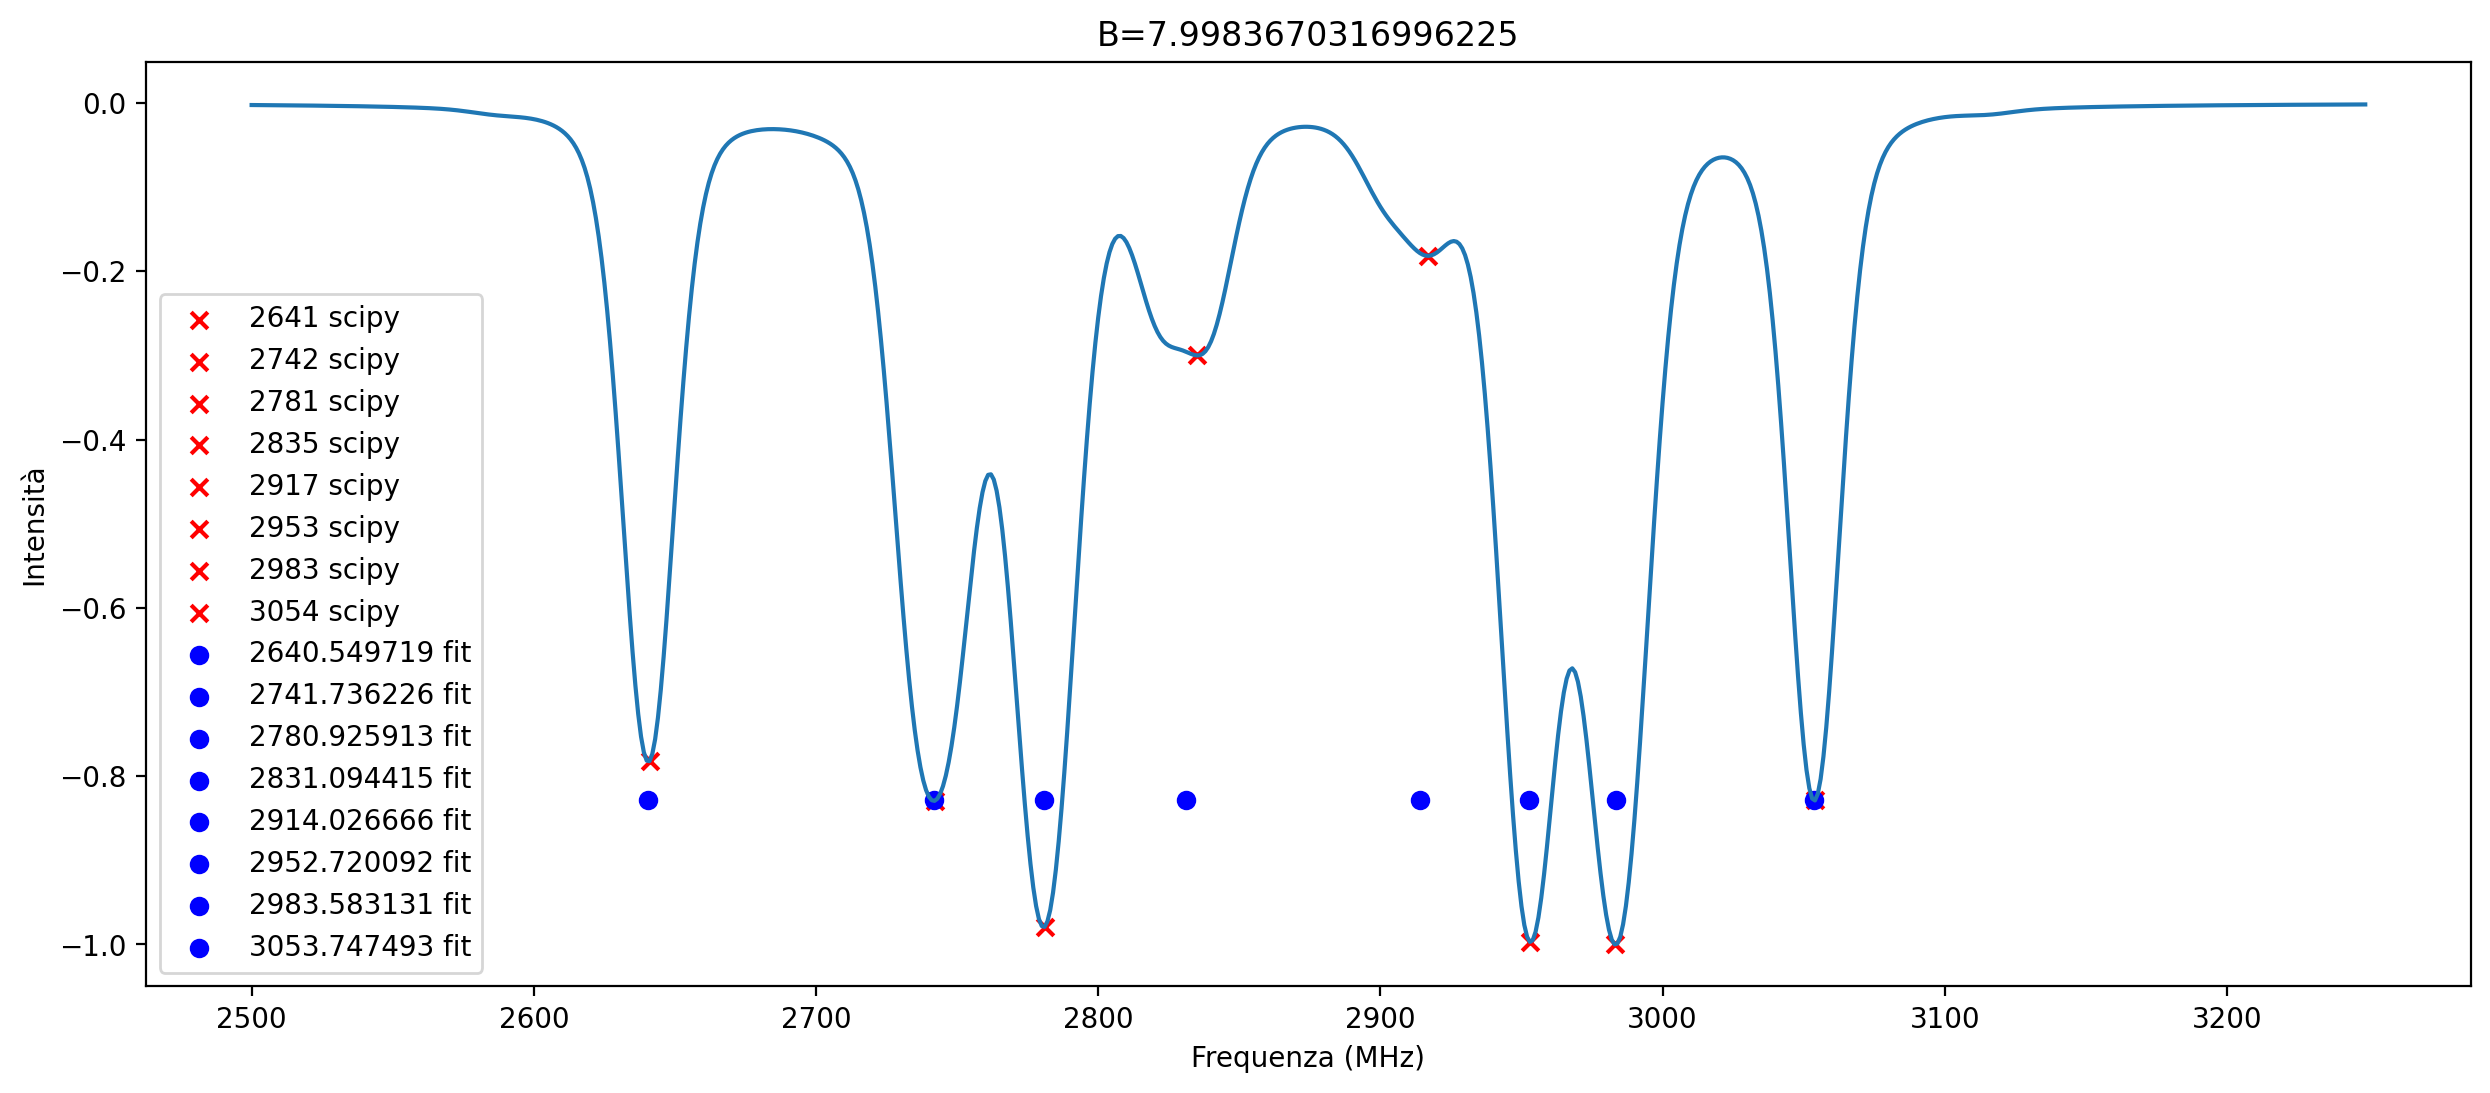

In [25]:
for l in l_list:
    plt.figure(figsize=(15, 6), dpi=200)
    plt.plot(x_axis, s[l])
    for pos in posizioni_totali[l]:
        h = info_totale[l]['peak_heights'][np.where(posizioni_totali[l] == pos)[0][0]]
        plt.scatter(pos, -h, color='red', marker='x', label=f'{pos} scipy')  # Evidenziamo i picchi
    for lab in labels[l]:
        plt.scatter(lab, -h, color='blue', marker='o', label=f'{lab} fit')  # Evidenziamo i picchi del fit
        
    plt.title(f"B={B[l]}")
    plt.xlabel('Frequenza (MHz)')
    plt.ylabel('Intensità')
    plt.legend()
    plt.show()